In [1]:
import pandas as pd

In [3]:
df=pd.read_parquet(r"D:\Amex Hackathon\train_data.parquet")
# events_df=pd.read_parquet(r"C:\Users\Umam\Downloads\add_event.parquet")
# transaction_df=pd.read_parquet(r"C:\Users\Umam\Downloads\add_trans.parquet")
# offerings_df=pd.read_parquet(r"C:\Users\Umam\Downloads\offer_metadata.parquet")

In [4]:
import pandas as pd

# Assume df is your DataFrame

# 1. Try convert all columns to numeric where possible
for col in df.columns:
    if col not in ['id1','id2','id3','id4','id5','y']:
        df[col] = pd.to_numeric(df[col], errors='ignore')


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\2463816434.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [5]:
import pandas as pd

# Base summary
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "null_count": df.isnull().sum().values,
    "unique_count": df.nunique().values
})

# Compute stats (only for numeric columns)
summary["mean"] = summary["column"].apply(lambda col: df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else None)
summary["median"] = summary["column"].apply(lambda col: df[col].median() if pd.api.types.is_numeric_dtype(df[col]) else None)
summary["mode"] = summary["column"].apply(lambda col: df[col].mode().iloc[0] if not df[col].mode().empty else None)
summary["std"] = summary["column"].apply(lambda col: df[col].std() if pd.api.types.is_numeric_dtype(df[col]) else None)

# Save to CSV
summary.to_csv("column_summary_full.csv", index=False)

# Optional: Display full in notebook
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(summary)


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


    column    dtype  null_count  unique_count          mean        median  \
0      id1   object           0        770164           NaN           NaN   
1      id2   object           0         46550           NaN           NaN   
2      id3   object           0           757           NaN           NaN   
3      id4   object           0        763371           NaN           NaN   
4      id5   object           0             3           NaN           NaN   
5        y   object           0             2           NaN           NaN   
6       f1  float64      491658            82  3.342909e+01  3.300000e+01   
7       f2  float64      447192            88  3.161076e+01  3.100000e+01   
8       f3  float64      661602            74  3.368765e+01  3.100000e+01   
9       f4  float64      701295            65  4.108053e+01  4.000000e+01   
10      f5  float64      231810            94  3.467605e+01  3.400000e+01   
11      f6  float64      150109            97  3.712995e+01  3.600000e+01   

In [6]:
zero_std_cols = summary[summary["std"] == 0]["column"].tolist()

# Drop from your main df
df.drop(columns=zero_std_cols, inplace=True)

# Format and print the dropped columns
formatted_cols = ', '.join(f"'{col}'" for col in zero_std_cols)
print(f"Dropped {len(zero_std_cols)} columns with std=0: {formatted_cols}")


Dropped 59 columns with std=0: 'f14', 'f15', 'f16', 'f17', 'f19', 'f20', 'f21', 'f23', 'f24', 'f25', 'f62', 'f66', 'f80', 'f88', 'f102', 'f128', 'f129', 'f144', 'f145', 'f205', 'f226', 'f229', 'f236', 'f238', 'f240', 'f243', 'f245', 'f246', 'f248', 'f249', 'f258', 'f259', 'f260', 'f262', 'f266', 'f267', 'f268', 'f270', 'f271', 'f277', 'f279', 'f281', 'f286', 'f287', 'f290', 'f291', 'f294', 'f295', 'f298', 'f300', 'f301', 'f303', 'f304', 'f307', 'f308', 'f309', 'f334', 'f335', 'f360'


In [7]:
# Calculate percentage of nulls
null_ratio = df.isnull().mean()

# Identify columns with >90% nulls
high_null_cols = null_ratio[null_ratio > 0.90].index.tolist()

# Drop those columns
df.drop(columns=high_null_cols, inplace=True)

# Format and print the dropped columns
formatted_null_cols = ', '.join(f"'{col}'" for col in high_null_cols)
print(f"Dropped {len(high_null_cols)} columns with >90% null values: {formatted_null_cols}")


Dropped 26 columns with >90% null values: 'f4', 'f13', 'f18', 'f33', 'f34', 'f36', 'f37', 'f64', 'f70', 'f79', 'f81', 'f84', 'f92', 'f112', 'f114', 'f117', 'f118', 'f120', 'f122', 'f135', 'f136', 'f154', 'f176', 'f189', 'f220', 'f221'


In [8]:
import numpy as np
import pandas as pd

# Example DataFrame
# df = pd.read_csv('your_data.csv')

# List of columns to be excluded from log‐transform consideration
exclude_cols = [f'f{i}' for i in range(226, 310)]

log_transform_cols = []

# Iterate through numerical columns, skipping excluded ones
for col in df.select_dtypes(include=[np.number]).columns:
    if col in exclude_cols:
        continue
    
    # Ensure column has no negative values before considering log transform
    if (df[col] < 0).any():
        continue

    mean_val = df[col].mean()
    median_val = df[col].median()
    
    # Condition 1: median == 0 but some positive mass → skewed
    if median_val == 0 and mean_val > 0.1:
        log_transform_cols.append(col)
        
    # Condition 2: non-zero median with mean/median ratio
    elif pd.notnull(mean_val) and pd.notnull(median_val) and median_val != 0:
        ratio = mean_val / median_val
        if ratio > 2.0:
            log_transform_cols.append(col)

# Apply log1p and drop originals
for col in log_transform_cols:
    df[f'{col}_log'] = np.log1p(df[col])

df.drop(columns=log_transform_cols, inplace=True)

print(f"Transformed and dropped {len(log_transform_cols)} columns:")
print(log_transform_cols)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\1757729961.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_log'] = np.log1p(df[col])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\1757729961.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_log'] = np.log1p(df[col])
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\1757729961.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

Transformed and dropped 100 columns:
['f22', 'f26', 'f30', 'f31', 'f43', 'f44', 'f45', 'f46', 'f47', 'f49', 'f60', 'f61', 'f63', 'f65', 'f69', 'f71', 'f72', 'f73', 'f74', 'f75', 'f78', 'f82', 'f83', 'f86', 'f94', 'f95', 'f97', 'f98', 'f99', 'f100', 'f101', 'f103', 'f113', 'f116', 'f121', 'f123', 'f124', 'f125', 'f126', 'f127', 'f130', 'f132', 'f133', 'f134', 'f137', 'f138', 'f141', 'f146', 'f147', 'f148', 'f149', 'f150', 'f151', 'f152', 'f153', 'f155', 'f156', 'f157', 'f158', 'f159', 'f160', 'f161', 'f162', 'f163', 'f164', 'f165', 'f166', 'f167', 'f168', 'f169', 'f170', 'f171', 'f172', 'f173', 'f174', 'f175', 'f177', 'f178', 'f179', 'f181', 'f182', 'f184', 'f185', 'f199', 'f200', 'f201', 'f202', 'f206', 'f209', 'f210', 'f211', 'f212', 'f333', 'f341', 'f351', 'f361', 'f362', 'f364', 'f365', 'f366']


In [9]:
import pandas as pd
import numpy as np

# === 1. Expand Range Helper ===
def expand_range(prefix, start, end):
    return [f"{prefix}{i}" for i in range(start, end + 1)]

# === 2. Feature Lists ===
impute_with_zero_cols = (
    # All behavioral counts, flags, spend, time, impressions, and OHE features
    ['f13'] + expand_range('f', 14, 27) +
    ['f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'f35', 'f36', 'f37', 'f38'] + # Added f38
    expand_range('f', 94, 101) + expand_range('f', 104, 111) + ['f113'] +
    expand_range('f', 123, 129) + expand_range('f', 130, 134) + ['f137', 'f138'] +
    expand_range('f', 140, 145) +
    expand_range('f', 146, 151) + expand_range('f', 199, 204) +
    ['f205'] + expand_range('f', 206, 213) +
    ['f217', 'f218', 'f219', 'f220', 'f221', 'f222'] +
    expand_range('f', 226, 309) + # Added all One-Hot Encoded Features
    expand_range('f', 310, 324) + expand_range('f', 325, 333) + # Added redemption modes
    expand_range('f', 336, 340) + ['f344', 'f345', 'f346', 'f348'] +
    expand_range('f', 361, 366) +
    ['f39', 'f40', 'f41'] + expand_range('f', 152, 186) +
    expand_range('f', 59, 76)
)

impute_with_median_or_mode_cols = (
    # All scores, profile attributes, and ratio features
    expand_range('f', 1, 12) +
    ['f42'] + expand_range('f', 43, 58) +
    expand_range('f', 77, 79) + ['f81', 'f82', 'f83', 'f85'] +
    expand_range('f', 86, 87) + expand_range('f', 89, 91) + ['f93'] + ['f187','f188','f190','f191','f192','f193','f194','f195','f196','f197','f198']+
    expand_range('f', 114, 119) + ['f121'] + ['f139'] +
    ['f214', 'f215', 'f216'] + expand_range('f', 223, 225) +
    ['f341', 'f342', 'f343', 'f347'] +
    expand_range('f', 351, 358) + ['f359']+['f103']
)
# === 3. Imputation Dictionary ===
imputation_values = {}

# === 4. Helper ===
def get_related_columns(col, df_columns):
    related = []
    if col in df_columns:
        related.append(col)
    log_col = f"{col}_log"
    if log_col in df_columns:
        related.append(log_col)
    return related

# === 5. Impute with ZERO ===
for col in impute_with_zero_cols:
    for related_col in get_related_columns(col, df.columns):
        df[related_col].fillna(0, inplace=True)
        imputation_values[related_col] = 0

# === 6. Impute with MEDIAN or MODE ===
for col in impute_with_median_or_mode_cols:
    for related_col in get_related_columns(col, df.columns):
        if pd.api.types.is_numeric_dtype(df[related_col]):
            value = df[related_col].median()
        else:
            mode_val = df[related_col].mode()
            value = mode_val[0] if not mode_val.empty else None

        if value is not None:
            df[related_col].fillna(value, inplace=True)
            imputation_values[related_col] = value

# === 7. Save Imputation Values ===
imputation_df = pd.DataFrame.from_dict(imputation_values, orient='index', columns=['impute_value'])
imputation_df.index.name = 'column'
imputation_df.reset_index(inplace=True)

# You can now save it to CSV or reuse it later
imputation_df.to_csv('imputation_values.csv', index=False)

print("✅ Final imputation complete. All NaNs should now be handled.")
print(f"🔍 Imputation values saved for {len(imputation_values)} columns.")


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\2841679159.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[related_col].fillna(0, inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\2841679159.py:67: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

✅ Final imputation complete. All NaNs should now be handled.
🔍 Imputation values saved for 279 columns.


In [10]:
import pandas as pd

# Assume 'df' is your DataFrame

# List of categorical columns to encode
categorical_cols = ['f42', 'f48', 'f50', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57', 'f354']

# Apply one-hot encoding
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Categorical features have been one-hot encoded.")
print("Shape of the final dataset:", df.shape)

Categorical features have been one-hot encoded.
Shape of the final dataset: (770164, 307)


In [11]:
# Convert id4 to datetime
df['id4'] = pd.to_datetime(df['id4'], errors='coerce', infer_datetime_format=True)

# Sort the DataFrame by id4
df.sort_values(by='id4', inplace=True)

# Optional: Reset index if needed
df.reset_index(drop=True, inplace=True)

print("✅ id4 converted to datetime and DataFrame sorted.")


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\2159719007.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['id4'] = pd.to_datetime(df['id4'], errors='coerce', infer_datetime_format=True)


✅ id4 converted to datetime and DataFrame sorted.


In [12]:
import pandas as pd

# 2) Categorical feature: day of week (Monday … Sunday)

# 3) Categorical feature: time-of-day bands  
#    (adjust the bins/labels to whatever ranges you need)
bins   = [0, 3, 6, 9, 12, 15, 18, 21, 24]
labels = ["0-3", "3-6", "6-9", "9-12", "12-15", "15-18", "18-21", "21-24"]

df["time_band"] = pd.cut(df["id4"].dt.hour,
                         bins=bins,
                         labels=labels,
                         right=False,
                         include_lowest=True)     # hour==0 goes into 0-3[2]



In [13]:
# Creates a feature measuring the number of seconds since the user's last event
df['datetime']=pd.to_datetime(df['id4'], errors='coerce', infer_datetime_format=True)
df['time_since_last_event'] = df.groupby('id2')['datetime'].diff().dt.total_seconds()

# Fill the first event for each user with a large number to indicate no prior history
df['time_since_last_event'].fillna(9999999, inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\2613350568.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['datetime']=pd.to_datetime(df['id4'], errors='coerce', infer_datetime_format=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\2613350568.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


 

In [14]:
df = pd.get_dummies(df, columns=[ "time_band"], prefix=["tb"])


In [15]:
import pandas as pd
import numpy as np

# --- Prerequisite: Ensure your DataFrame 'df' has the necessary columns ---
# This includes the remaining one-hot encoded offer categories (f227, f228, etc.),
# and the historical spend columns for both 30 and 180 days.

print("--- Creating Spend-to-Category Relevance Ratio Features ---")

# --- 1. Define Mappings and Column Lists ---

# Dictionary for 30-day spend features
category_to_spend_col_last30 = {
    'f232': 'f152_log',  # Travel Offer -> Airline Spend (30d)
    'f228': 'f153_log',  # Entertainment Offer -> Entertainment Spend (30d)
    'f227': 'f157_log',  # Dining Offer -> Restaurant Spend (30d)
    'f231': 'f158_log'   # Shopping Offer -> Retail Spend (30d)
}

# Dictionary for 180-day spend features
category_to_spend_col_last180 = {
    'f232': 'f153_log',  # Travel Offer -> Airline Spend (180d)
    'f228': 'f164_log',  # Entertainment Offer -> Entertainment Spend (180d)
    'f231': 'f169_log',  # Shopping Offer -> Retail Spend (180d)
}

# Lists of all spend columns to calculate totals for each period
all_spend_cols_last_30 = ['f152_log', 'f153_log', 'f155_log', 'f156_log', 'f157_log', 'f158_log', 'f159_log', 'f160_log', 'f161_log', 'f162_log']
all_spend_cols_last_180 = ['f163_log', 'f164_log', 'f165_log', 'f166_log', 'f167_log', 'f168_log', 'f169_log', 'f170_log', 'f171_log', 'f172_log', 'f173_log']

# --- 2. Calculate Total Historical Spend for Each Period ---
df['total_hist_spend_30'] = df[all_spend_cols_last_30].sum(axis=1)
df['total_hist_spend_180'] = df[all_spend_cols_last_180].sum(axis=1)

# --- 3. Calculate the Relevance Ratios ---
# Initialize the new feature columns
df['spend_to_category_match_30'] = 0.0
df['spend_to_category_match_180'] = 0.0

# Loop for the 30-day ratio
for category_ohe, spend_col in category_to_spend_col_last30.items():
    if category_ohe in df.columns: # Check if the category column exists
        is_category_active = df[category_ohe] == 1
        # For active rows, calculate the ratio of specific spend to total 30-day spend
        df.loc[is_category_active, 'spend_to_category_match_30'] = \
            df.loc[is_category_active, spend_col] / (df.loc[is_category_active, 'total_hist_spend_30'] + 1)

# Loop for the 180-day ratio
for category_ohe, spend_col in category_to_spend_col_last180.items():
    if category_ohe in df.columns: # Check if the category column exists
        is_category_active = df[category_ohe] == 1
        # For active rows, calculate the ratio of specific spend to total 180-day spend
        df.loc[is_category_active, 'spend_to_category_match_180'] = \
            df.loc[is_category_active, spend_col] / (df.loc[is_category_active, 'total_hist_spend_180'] + 1)

# --- 4. Clean up temporary total columns ---
df.drop(columns=['total_hist_spend_30', 'total_hist_spend_180'], inplace=True)

print("\n✅ 'spend_to_category_match_30' and 'spend_to_category_match_180' features created.")
print("\nSample of new features:")
print(df[['spend_to_category_match_30', 'spend_to_category_match_180']].head())


--- Creating Spend-to-Category Relevance Ratio Features ---

✅ 'spend_to_category_match_30' and 'spend_to_category_match_180' features created.

Sample of new features:
   spend_to_category_match_30  spend_to_category_match_180
0                         0.0                      0.22206
1                         0.0                      0.00000
2                         0.0                      0.22206
3                         0.0                      0.22206
4                         0.0                      0.22206


In [18]:
events_df['id4']=pd.to_datetime(events_df['id4'], errors='coerce', infer_datetime_format=True)
events_df['id7']=pd.to_datetime(events_df['id7'], errors='coerce', infer_datetime_format=True)
events_df['id3']=events_df['id3'].astype(int)
df['id3']=df['id3'].astype(int)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\3266398575.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  events_df['id4']=pd.to_datetime(events_df['id4'], errors='coerce', infer_datetime_format=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27056\3266398575.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  events_df['id7']=pd.to_datetime(events_df['id7'], errors='coerce', infer_datetime_format=True)


In [19]:
df['y'] = df['y'].astype(int)

# --- 1. Chronological 80 / 20 split ------------------------------------------
split_idx = int(len(df) * 0.8)        # first 80 % → train, last 20 % → val
train_df  = df.iloc[:split_idx].copy()
val_df    = df.iloc[split_idx:].copy()


In [24]:
import pandas as pd

# Assume 'final_merged_df' is your final DataFrame

# --- Code to save the file ---
# The file will be saved in the same directory as your script or notebook.
file_path = 'train_df.parquet'

train_df.to_parquet(file_path, engine='pyarrow')

print(f"DataFrame successfully saved to: {file_path}")

DataFrame successfully saved to: train_df.parquet


In [25]:
import pandas as pd

# Assume 'final_merged_df' is your final DataFrame

# --- Code to save the file ---
# The file will be saved in the same directory as your script or notebook.
file_path = 'val_df.parquet'

val_df.to_parquet(file_path, engine='pyarrow')

print(f"DataFrame successfully saved to: {file_path}")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
DataFrame successfully saved to: val_df.parquet


In [1]:
import pandas as pd
train_df = pd.read_parquet("train_df.parquet")
val_df = pd.read_parquet("val_df.parquet")

In [2]:
import numpy as np

# Create new columns, initially empty
train_df['original_price'] = np.nan
train_df['offer_price'] = np.nan

# Define the condition where we can calculate the price
# This is where a fixed discount and a per-dollar value exist
condition = (train_df['f219'] > 0) & (train_df['f222'] > 0)

# Calculate original_price ONLY for those rows
train_df.loc[condition, 'original_price'] = train_df.loc[condition, 'f219'] / train_df.loc[condition, 'f222']

# Now calculate the final offer_price for the same rows
train_df.loc[condition, 'offer_price'] = train_df.loc[condition, 'original_price'] - train_df.loc[condition, 'f219']

# The rows where the condition was False will have NaN in these new columns
print(train_df[['f219', 'f222', 'original_price','offer_price']].head())

        f219  f222  original_price  offer_price
310692   0.0   0.0             NaN          NaN
440198   0.0   0.0             NaN          NaN
440077   0.0   0.0             NaN          NaN
284375  20.0   0.2           100.0         80.0
283996   0.0   0.0             NaN          NaN


In [3]:
import numpy as np

# Create new columns, initially empty
val_df['original_price'] = np.nan
val_df['offer_price'] = np.nan

# Define the condition where we can calculate the price
# This is where a fixed discount and a per-dollar value exist
condition = (val_df['f219'] > 0) & (val_df['f222'] > 0)

# Calculate original_price ONLY for those rows
val_df.loc[condition, 'original_price'] = val_df.loc[condition, 'f219'] / val_df.loc[condition, 'f222']

# Now calculate the final offer_price for the same rows
val_df.loc[condition, 'offer_price'] = val_df.loc[condition, 'original_price'] - val_df.loc[condition, 'f219']

# The rows where the condition was False will have NaN in these new columns
print(val_df[['f219', 'f222', 'original_price','offer_price']].head())

        f219  f222  original_price  offer_price
77897    0.0  0.00             NaN          NaN
77898   11.0  1.00            11.0          0.0
4023    60.0  0.24           250.0        190.0
105957  25.0  0.50            50.0         25.0
134612  25.0  0.20           125.0        100.0


In [4]:
import pandas as pd
import numpy as np

# --- Setup: Create a DataFrame with duplicate offers and NaN values ---
# Offer 'A' appears twice with a valid price.
# Offer 'B' appears once with a valid price.
# Offer 'C' appears twice but its price is NaN.
# data = {
#     'offer_id': ['A', 'C', 'B', 'A', 'C'],
#     'original_price': [100.0, np.nan, 500.0, 100.0, np.nan],
#     'offer_price': [80.0, np.nan, 450.0, 80.0, np.nan]
# }
# val_df = pd.DataFrame(data)

# print("--- 1. Original DataFrame with Duplicates and NaNs ---")
# print(val_df)
# print("\n" + "="*50 + "\n")


# --- Step 1: Aggregate to get unique offer profiles ---
# This creates a new table with one row per unique offer.
offer_profiles = train_df.groupby('id3').agg({
    'original_price': 'first',
    'offer_price': 'first'
})

print("--- 2. Aggregated DataFrame (Unique Offer Profiles) ---")
print(offer_profiles)
print("\n" + "="*50 + "\n")


# --- Step 2: Calculate medians from the AGGREGATED data ---
# This median represents the typical value across unique offers.
fill_values = {
    'original_price': offer_profiles['original_price'].median(),
    'offer_price': offer_profiles['offer_price'].median()
}

print(f"Median of unique original prices: {fill_values['original_price']}")
print(f"Median of unique offer prices: {fill_values['offer_price']}\n")


# --- Step 3: Fill NaNs in the ORIGINAL DataFrame ---
# Use the medians from the aggregated data to fill missing values back in the original table.
train_df.fillna(value=fill_values, inplace=True)


# --- Display the Final Result ---
print("--- 4. Final DataFrame After Filling NaNs ---")
print(train_df.head())

--- 2. Aggregated DataFrame (Unique Offer Profiles) ---
        original_price  offer_price
id3                                
10139             60.0         35.0
101460             NaN          NaN
10242            100.0         80.0
104246           150.0        120.0
10943              NaN          NaN
...                ...          ...
9955              75.0         60.0
997352             NaN          NaN
99856              NaN          NaN
99877              NaN          NaN
99900            100.0         85.0

[757 rows x 2 columns]


Median of unique original prices: 100.0
Median of unique offer prices: 85.0

--- 4. Final DataFrame After Filling NaNs ---
                                                   id1      id2       id3  \
310692    1000078_622070_16-23_2023-11-02 03:40:44.605  1000078    622070   
440198     1000101_86651_16-23_2023-11-02 12:54:46.722  1000101     86651   
440077     1000101_69479_16-23_2023-11-02 12:54:11.194  1000101     69479   
284375    1000125_9

In [5]:
import pandas as pd
import numpy as np

# --- Setup: Create a DataFrame with duplicate offers and NaN values ---
# Offer 'A' appears twice with a valid price.
# Offer 'B' appears once with a valid price.
# Offer 'C' appears twice but its price is NaN.
# data = {
#     'offer_id': ['A', 'C', 'B', 'A', 'C'],
#     'original_price': [100.0, np.nan, 500.0, 100.0, np.nan],
#     'offer_price': [80.0, np.nan, 450.0, 80.0, np.nan]
# }
# val_df = pd.DataFrame(data)

# print("--- 1. Original DataFrame with Duplicates and NaNs ---")
# print(val_df)
# print("\n" + "="*50 + "\n")


# --- Step 1: Aggregate to get unique offer profiles ---
# This creates a new table with one row per unique offer.
offer_profiles = val_df.groupby('id3').agg({
    'original_price': 'first',
    'offer_price': 'first'
})

print("--- 2. Aggregated DataFrame (Unique Offer Profiles) ---")
print(offer_profiles)
print("\n" + "="*50 + "\n")


# --- Step 2: Calculate medians from the AGGREGATED data ---
# This median represents the typical value across unique offers.
fill_values = {
    'original_price': offer_profiles['original_price'].median(),
    'offer_price': offer_profiles['offer_price'].median()
}

print(f"Median of unique original prices: {fill_values['original_price']}")
print(f"Median of unique offer prices: {fill_values['offer_price']}\n")


# --- Step 3: Fill NaNs in the ORIGINAL DataFrame ---
# Use the medians from the aggregated data to fill missing values back in the original table.
val_df.fillna(value=fill_values, inplace=True)


# --- Display the Final Result ---
print("--- 4. Final DataFrame After Filling NaNs ---")
print(val_df)

--- 2. Aggregated DataFrame (Unique Offer Profiles) ---
        original_price  offer_price
id3                                
10139             60.0         35.0
101460             NaN          NaN
10242            100.0         80.0
104246           150.0        120.0
10943              NaN          NaN
...                ...          ...
9955              75.0         60.0
997352             NaN          NaN
99856              NaN          NaN
99877              NaN          NaN
99900            100.0         85.0

[717 rows x 2 columns]


Median of unique original prices: 100.0
Median of unique offer prices: 85.0

--- 4. Final DataFrame After Filling NaNs ---
                                                    id1      id2     id3  \
77897       1000043_93516_16-23_2023-11-03 13:59:42.346  1000043   93516   
77898       1000043_69026_16-23_2023-11-03 13:59:42.714  1000043   69026   
4023       1000099_209183_16-23_2023-11-03 08:48:05.823  1000099  209183   
105957     1000144_4914

In [2]:
events_df = pd.read_parquet(r"D:\Amex Hackathon\add_event.parquet")

In [3]:
import pandas as pd
from tqdm.autonotebook import tqdm

print("--- Starting Offer Velocity Feature Creation (Leak-Proof Method) ---")

# --- Step 1: Define the Chronological Boundary ---
cutoff_time = train_df['datetime'].max()
print(f"Historical data cutoff time (end of training): {cutoff_time}")

# --- Step 2: Build a Strictly Historical Event Log ---
impressions_df = events_df[['id3', 'id4']].rename(columns={'id4': 'timestamp'})
impressions_df['is_impression'] = 1
impressions_df['is_click'] = 0

clicks_df = events_df[['id3', 'id7']].dropna().rename(columns={'id7': 'timestamp'})
clicks_df['is_impression'] = 0
clicks_df['is_click'] = 1

historical_events_log = pd.concat([impressions_df, clicks_df], ignore_index=True)
historical_events_log['timestamp'] = pd.to_datetime(historical_events_log['timestamp'])
historical_events_log = historical_events_log[historical_events_log['timestamp'] <= cutoff_time].copy()

# Aggregate events at duplicate timestamps
print("Aggregating events at duplicate timestamps to ensure a unique index...")
historical_events_log = historical_events_log.groupby(['id3', 'timestamp']).sum().reset_index()
historical_events_log.sort_values(['id3', 'timestamp'], inplace=True)
print(f"Created unique historical log with {len(historical_events_log)} events.")


# --- Step 3: Pre-calculate Rolling Features on the Historical Log ---
print("Pre-calculating rolling velocity features on the historical log...")
windows = ['1h', '3h', '6h', '9h', '24h', '3d']
new_feature_cols = []
rolling_features_list = [] # Store calculated features here

# --- THIS IS THE MAIN LOGIC CHANGE ---
# We calculate features on a temporary dataframe with the correct index
# and then merge them back later.
temp_log_for_rolling = historical_events_log.set_index('timestamp')

for window in tqdm(windows):
    rolling_sum = temp_log_for_rolling.groupby('id3')[['is_impression', 'is_click']].rolling(window).sum()
    shifted_rolling_sum = rolling_sum.groupby('id3').shift(1)
    
    imp_col_name = f'offer_impressions_last_{window}'
    click_col_name = f'offer_clicks_last_{window}'
    new_feature_cols.extend([imp_col_name, click_col_name])

    # Rename columns in the result
    shifted_rolling_sum.columns = [imp_col_name, click_col_name]
    rolling_features_list.append(shifted_rolling_sum)

# Concatenate all the calculated feature dataframes
all_rolling_features_df = pd.concat(rolling_features_list, axis=1)

# Merge the calculated features back to the original log on the MultiIndex
historical_events_log = historical_events_log.merge(
    all_rolling_features_df,
    on=['id3', 'timestamp'],
    how='left'
)


# --- Step 4: Define a Reusable Function to Apply Features ---
# --- Step 4: Define a Reusable Function to Apply Features ---
def add_velocity_features(df_to_process, hist_log):
    """
    Applies pre-calculated historical velocity features to a dataframe
    using a point-in-time merge.
    """
    # --- FIX: Ensure the 'by' key ('id3') has the same data type ---
    # Convert 'id3' in both dataframes to string to ensure they match.
    df_to_process['id3'] = df_to_process['id3'].astype(str)
    hist_log['id3'] = hist_log['id3'].astype(str)
    
    # Ensure data is sorted for the merge_asof operation
    df_to_process = df_to_process.sort_values('datetime')
    hist_log = hist_log.sort_values('timestamp')

    # Merge the features. This finds the latest historical record for each offer
    # that occurred at or before the observation's timestamp.
    merged_df = pd.merge_asof(
        left=df_to_process,
        right=hist_log,
        left_on='datetime',
        right_on='timestamp',
        by='id3',  # The keys here now have matching dtypes
        direction='backward'
    )
    return merged_df


# --- Step 5: Apply Features to Train and Validation Sets ---
print("\nApplying features to the training set...")
train_df_featured = add_velocity_features(train_df, historical_events_log)

print("Applying the same features to the validation set...")
val_df_featured = add_velocity_features(val_df, historical_events_log)


# --- Step 6: Finalize DataFrames ---
features_to_add = train_df_featured[['id1'] + new_feature_cols]
train_df = train_df.merge(features_to_add, on='id1', how='left')
train_df[new_feature_cols] = train_df[new_feature_cols].fillna(0)

val_features_to_add = val_df_featured[['id1'] + new_feature_cols]
val_df = val_df.merge(val_features_to_add, on='id1', how='left')
val_df[new_feature_cols] = val_df[new_feature_cols].fillna(0)


print("\n✅ Leak-proof offer velocity features created successfully.")
print("\nSample of new features in the training data:")
print(train_df[new_feature_cols].head())

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15616\1547168851.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


--- Starting Offer Velocity Feature Creation (Leak-Proof Method) ---
Historical data cutoff time (end of training): 2023-11-03 08:30:56.584000
Aggregating events at duplicate timestamps to ensure a unique index...
Created unique historical log with 20663018 events.
Pre-calculating rolling velocity features on the historical log...


  0%|          | 0/6 [00:00<?, ?it/s]


Applying features to the training set...
Applying the same features to the validation set...

✅ Leak-proof offer velocity features created successfully.

Sample of new features in the training data:
   offer_impressions_last_1h  offer_clicks_last_1h  offer_impressions_last_3h  \
0                       70.0                   1.0                      300.0   
1                       22.0                   0.0                      109.0   
2                       51.0                   0.0                      258.0   
3                       20.0                   0.0                      101.0   
4                       72.0                   1.0                      285.0   

   offer_clicks_last_3h  offer_impressions_last_6h  offer_clicks_last_6h  \
0                   2.0                      857.0                  13.0   
1                   3.0                      318.0                   5.0   
2                   0.0                      776.0                   2.0   
3        

In [20]:
train_df.head(50)

,id1,id2,id3,id4,id5,y,f1,f2,f3,f5,...,tb_0-3,tb_3-6,tb_6-9,tb_9-12,tb_12-15,tb_15-18,tb_18-21,tb_21-24,spend_to_category_match_30,spend_to_category_match_180
0,1111176_58396_16-23_2023-11-01 00:00:23.729,1111176,58396,2023-11-01 00:00:23.729,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.22206
1,1111176_74465_16-23_2023-11-01 00:00:23.761,1111176,74465,2023-11-01 00:00:23.761,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.00000
2,1111176_566484_16-23_2023-11-01 00:00:23.832,1111176,566484,2023-11-01 00:00:23.832,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.22206
3,1111176_762903_16-23_2023-11-01 00:00:23.841,1111176,762903,2023-11-01 00:00:23.841,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.22206
4,1111176_14996_16-23_2023-11-01 00:00:23.845,1111176,14996,2023-11-01 00:00:23.845,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.22206
5,1111176_60764_16-23_2023-11-01 00:00:23.850,1111176,60764,2023-11-01 00:00:23.850,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.22206
6,1111176_63872_16-23_2023-11-01 00:00:23.875,1111176,63872,2023-11-01 00:00:23.875,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.22206
7,1111176_71220_16-23_2023-11-01 00:00:24.022,1111176,71220,2023-11-01 00:00:24.022,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.00000
8,1111176_783808_16-23_2023-11-01 00:00:24.023,1111176,783808,2023-11-01 00:00:24.023,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.22206
9,1111176_403431_16-23_2023-11-01 00:00:24.023,1111176,403431,2023-11-01 00:00:24.023,2023-11-01,0,33.0,31.0,31.0,34.0,...,True,False,False,False,False,False,False,False,0.0,0.00000


In [4]:
import pandas as pd
import numpy as np

# --- Prerequisites ---
# This script should be run AFTER you have created your time-based split.
# It assumes you have:
# 1. A training DataFrame, 'train_df', with 'id1', 'id2', 'datetime', 'y', and the one-hot encoded offer category columns.
# 2. A validation DataFrame, 'val_df', with the same columns.

print("--- Starting Leak-Proof Historical Category Counts Feature Creation ---")

try:
    # --- 1. Define your offer category columns ---
    # This list should contain all the one-hot encoded offer category features.
    offer_category_cols = [
        'f227', 'f228', 'f230', 'f231', 'f232' 
        # Add any other primary category columns here
    ]
    
    # --- 2. Prepare a Unified Event Log ---
    print("Preparing a unified event log from train and validation sets...")

    # a. Define the columns needed from the original dataframes
    cols_to_keep = ['id1', 'id2', 'datetime', 'y'] + offer_category_cols
    
    # b. Get impression events from your train and validation sets
    train_impressions = train_df[cols_to_keep].copy()
    train_impressions['source'] = 'train'
    val_impressions = val_df[cols_to_keep].copy()
    val_impressions['source'] = 'val'

    # c. Combine the impression events
    master_log = pd.concat([train_impressions, val_impressions], ignore_index=True)
    
    # d. Add the click information (ground truth) ONLY from the training set
    # We create a temporary 'y_train' column to do this.
    master_log['y_train'] = 0
    master_log.loc[master_log['source'] == 'train', 'y_train'] = train_df['y'].values

    # e. Convert to datetime and sort chronologically by user and time
    master_log['datetime'] = pd.to_datetime(master_log['datetime'])
    master_log.sort_values(['id2', 'datetime'], inplace=True)
    print(f"Created master log with {len(master_log)} total events.")

    # --- 3. Calculate Historical Features for Each Category (Leak-Proof) ---
    print("Calculating historical counts for each category...")
    
    new_feature_cols = []
    
    for category_col in offer_category_cols:
        # a. Calculate Historical Views for this category
        hist_views = master_log.groupby('id2')[category_col].cumsum()
        hist_views = hist_views.groupby(master_log['id2']).shift(1).fillna(0)
        
        # b. Calculate Historical Clicks for this category
        # The interaction is with 'y_train', which is 0 for all validation rows, preventing leakage.
        click_interaction = master_log[category_col] * master_log['y_train']
        hist_clicks = click_interaction.groupby(master_log['id2']).cumsum()
        hist_clicks = hist_clicks.groupby(master_log['id2']).shift(1).fillna(0)
        
        # c. Create and store the new feature names
        view_col_name = f'{category_col}_user_hist_impressions'
        click_col_name = f'{category_col}_user_hist_clicks'
        ctr_col_name = f'{category_col}_user_hist_ctr'
        
        new_feature_cols.extend([view_col_name, click_col_name, ctr_col_name])
        
        # d. Add the new features to the master log
        master_log[view_col_name] = hist_views
        master_log[click_col_name] = hist_clicks
        master_log[ctr_col_name] = hist_clicks / (hist_views + 1)


    # --- Step 4: Merge the New Features Back to the Original DataFrames ---
    print("Merging new features back to train and validation sets...")

    # a. Filter the master log to keep only the original impression events
    processed_impressions = master_log[master_log['source'].isin(['train', 'val'])].copy()

    # b. Merge the new features back using the unique 'id1'
    features_to_merge = processed_impressions[['id1'] + new_feature_cols]
    
    # Merge into training data
    train_df = train_df.merge(features_to_merge, on='id1', how='left')
    
    # Merge into validation data
    val_df = val_df.merge(features_to_merge, on='id1', how='left')

    print("\n✅ Leak-proof user-specific historical category features created successfully.")
    print("\nSample of new features added to training data:")
    print(train_df[new_feature_cols].head())

except KeyError as e:
    print(f"\nERROR: A required column was not found. Please check the column names. Missing column: {e}")



--- Starting Leak-Proof Historical Category Counts Feature Creation ---
Preparing a unified event log from train and validation sets...
Created master log with 770164 total events.
Calculating historical counts for each category...
Merging new features back to train and validation sets...

✅ Leak-proof user-specific historical category features created successfully.

Sample of new features added to training data:
   f227_user_hist_impressions  f227_user_hist_clicks  f227_user_hist_ctr  \
0                         0.0                    0.0                 0.0   
1                         0.0                    0.0                 0.0   
2                         1.0                    0.0                 0.0   
3                         1.0                    0.0                 0.0   
4                         1.0                    0.0                 0.0   

   f228_user_hist_impressions  f228_user_hist_clicks  f228_user_hist_ctr  \
0                         0.0                    0

In [5]:
import pandas as pd

# Assume 'final_merged_df' is your final DataFrame

# --- Code to save the file ---
# The file will be saved in the same directory as your script or notebook.
file_path = 'train_df.parquet'

train_df.to_parquet(file_path, engine='pyarrow')

print(f"DataFrame successfully saved to: {file_path}")

DataFrame successfully saved to: train_df.parquet


In [6]:
import pandas as pd

# Assume 'final_merged_df' is your final DataFrame

# --- Code to save the file ---
# The file will be saved in the same directory as your script or notebook.
file_path = 'val_df.parquet'

val_df.to_parquet(file_path, engine='pyarrow')

print(f"DataFrame successfully saved to: {file_path}")

DataFrame successfully saved to: val_df.parquet


In [1]:
import pandas as pd
train_df = pd.read_parquet("train_df.parquet")
val_df = pd.read_parquet("val_df.parquet")

In [61]:
train_df['entertainment_interest_score'] = 0
train_df['business_interest_score'] = train_df['f3'] + train_df['f6'] + train_df['f5'] 
train_df['dining_interest_score'] = train_df['f2'] + train_df['f8']
train_df['retail_interest_score'] = train_df['f11']
train_df['services_interest_score'] = train_df['f10']
train_df['shopping_interest_score'] = train_df['f7'] + train_df['f12']
train_df['travel_interest_score'] = train_df['f1'] + train_df['f9']

KeyError: 'f3'

In [62]:
val_df['entertainment_interest_score'] = 0
val_df['business_interest_score'] = val_df['f3'] + val_df['f6'] + val_df['f5'] 
val_df['dining_interest_score'] = val_df['f2'] + val_df['f8']
val_df['retail_interest_score'] = val_df['f11']
val_df['services_interest_score'] = val_df['f10']
val_df['shopping_interest_score'] = val_df['f7'] + val_df['f12']
val_df['travel_interest_score'] = val_df['f1'] + val_df['f9']

In [59]:
train_df.drop(columns=['f1','f2','f3','f5','f6','f7','f8','f9','f10','f11','f12'], inplace = True)

In [63]:
val_df.drop(columns=['f1','f2','f3','f5','f6','f7','f8','f9','f10','f11','f12'], inplace = True)

In [2]:
events_df = pd.read_parquet(r"D:\Amex Hackathon\add_event.parquet")

In [3]:
import pandas as pd
import numpy as np

# --- Prerequisites ---
# This script should be run AFTER you have created your time-based split.
# It assumes you have:
# 1. A training DataFrame, 'train_df', with a 'datetime' column.
# 2. A validation DataFrame, 'val_df', with a 'datetime' column.
# 3. The full 'events_df' with 'id4' (Impression) and 'id7' (Click) timestamps.

print("--- Starting Concurrent Event Feature Creation (Leak-Proof Method) ---")

try:
    # --- Step 1: Create the Historical Event Log from Training Data ONLY ---
    print("Preparing a historical event log from the training period only...")
    
    # a. Determine the end time of the training period.
    train_df['datetime'] = pd.to_datetime(train_df['datetime'])
    train_end_time = train_df['datetime'].max()
    print(f"Training data ends at: {train_end_time}")

    # b. Prepare impression and click events from the external events_df
    impressions_df = events_df[['id4']].rename(columns={'id4': 'timestamp'})
    impressions_df['is_impression'] = 1
    impressions_df['is_click'] = 0
    
    clicks_df = events_df[['id7']].dropna().rename(columns={'id7': 'timestamp'})
    clicks_df['is_impression'] = 0
    clicks_df['is_click'] = 1
    
    offer_events_log = pd.concat([impressions_df, clicks_df], ignore_index=True)
    offer_events_log['timestamp'] = pd.to_datetime(offer_events_log['timestamp'])

    # c. CRITICAL: Filter the log to include only events that occurred
    #    during or before the training period to prevent data leakage.
    historical_events_log = offer_events_log[offer_events_log['timestamp'] <= train_end_time].copy()
    
    # d. Sort the historical log and calculate cumulative sums
    historical_events_log.sort_values('timestamp', inplace=True)
    historical_events_log['cumulative_impressions'] = historical_events_log['is_impression'].cumsum()
    historical_events_log['cumulative_clicks'] = historical_events_log['is_click'].cumsum()
    
    # e. Shift to make the counts strictly historical
    historical_events_log['concurrent_impressions'] = historical_events_log['cumulative_impressions'].shift(1).fillna(0)
    historical_events_log['concurrent_clicks'] = historical_events_log['cumulative_clicks'].shift(1).fillna(0)
    
    # f. Keep only the necessary columns for merging
    historical_timestamp_counts = historical_events_log[['timestamp', 'concurrent_impressions', 'concurrent_clicks']]
    historical_timestamp_counts = historical_timestamp_counts.drop_duplicates(subset='timestamp', keep='last')
    print(f"Created a historical log of {len(historical_timestamp_counts)} unique event timestamps.")
    historical_timestamp_counts.rename(
        columns={'timestamp': 'datetime'},
        inplace=True
    )

    # --- Step 2: Define a Reusable Function to Apply the Features ---
    def add_concurrent_features(df_to_process, hist_counts):
        # a. Prepare the dataframe for the merge
        df_to_process['datetime'] = pd.to_datetime(df_to_process['datetime'])
        df_to_process.sort_values('datetime', inplace=True)

        # b. Perform the as-of merge using the historical log
        merged_df = pd.merge_asof(
            left=df_to_process,
            right=hist_counts,
            on='datetime',
            direction='backward'
        )
        
        # c. Fill NaNs for events that occurred before any historical events
        merged_df[['concurrent_impressions', 'concurrent_clicks']] = merged_df[['concurrent_impressions', 'concurrent_clicks']].fillna(0)
        
        return merged_df

    # --- Step 3: Apply the Feature Creation to Train and Validation Sets ---
    print("\nApplying features to training set...")
    train_df = add_concurrent_features(train_df, historical_timestamp_counts)

    print("Applying features to validation set...")
    val_df = add_concurrent_features(val_df, historical_timestamp_counts)

    print("\n✅ Leak-proof concurrent event features created successfully for both sets.")
    print("\nSample of new features added to training data:")
    print(train_df[['datetime', 'concurrent_impressions', 'concurrent_clicks']].head())

except KeyError as e:
    print(f"\nERROR: A required column was not found. Please check the column names. Missing column: {e}")



--- Starting Concurrent Event Feature Creation (Leak-Proof Method) ---
Preparing a historical event log from the training period only...
Training data ends at: 2023-11-03 08:30:56.584000
Created a historical log of 20035443 unique event timestamps.

Applying features to training set...
Applying features to validation set...

✅ Leak-proof concurrent event features created successfully for both sets.

Sample of new features added to training data:
                 datetime  concurrent_impressions  concurrent_clicks
0 2023-11-01 00:00:23.729              15681118.0           242611.0
1 2023-11-01 00:00:23.761              15681120.0           242611.0
2 2023-11-01 00:00:23.832              15681123.0           242611.0
3 2023-11-01 00:00:23.841              15681126.0           242611.0
4 2023-11-01 00:00:23.845              15681129.0           242611.0


In [12]:
import pandas as pd
import numpy as np
from tqdm.autonotebook import tqdm

# --- Prerequisites ---
# This code assumes you have:
# 1. A training DataFrame, 'train_df', with 'id1', 'id3', and 'datetime' columns.
# 2. A validation DataFrame, 'val_df', with 'id1', 'id3', and 'datetime' columns.
# 3. A complete events DataFrame, 'events_df', with 'id3', 'id6', 'id4' (impression ts), and 'id7' (click ts).
#
# NOTE: This script should be run AFTER the time-based split of train_df and val_df.

print("--- Starting Placement Historical CTR Feature Creation (Leak-Proof for Train/Val Split) ---")

try:
    # --- Step 1: Build Mappings and Historical Logs from TRAINING DATA ONLY ---
    print("Step 1: Building all historical lookups from the training period...")

    # a. Ensure datetime columns are in the correct format. This is crucial for time-series operations.
    train_df['datetime'] = pd.to_datetime(train_df['datetime'])
    val_df['datetime'] = pd.to_datetime(val_df['datetime'])
    events_df['id4'] = pd.to_datetime(events_df['id4'])
    events_df['id7'] = pd.to_datetime(events_df['id7'])

    # b. Determine the end time of the training period to prevent data leakage
    train_end_time = train_df['datetime'].max()
    print(f"Training data ends at: {train_end_time}. All historical features will be based on data up to this point.")

    # c. Create a placement ID mapping (id3 -> id6) using only events within the training period
    print("Creating placement ID map (id3 -> id6) using training data...")
    train_period_events = events_df[events_df['id4'] <= train_end_time].copy()
    train_period_events['id3'] = train_period_events['id3'].astype(str)
    id3_to_id6_map = train_period_events.groupby('id3')['id6'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).reset_index()
    print("Placement ID map created.")
    
    # d. Prepare the complete event stream for placements (impressions and clicks)
    impressions_df = events_df[['id6', 'id4']].rename(columns={'id4': 'timestamp'})
    impressions_df['is_impression'] = 1
    impressions_df['is_click'] = 0

    clicks_df = events_df[['id6', 'id7']].dropna().rename(columns={'id7': 'timestamp'})
    clicks_df['is_impression'] = 0
    clicks_df['is_click'] = 1

    placement_events_log = pd.concat([impressions_df, clicks_df], ignore_index=True)
    placement_events_log.dropna(subset=['timestamp'], inplace=True)

    # e. CRITICAL: Filter the event log to include only events from the training period
    historical_placement_log = placement_events_log[placement_events_log['timestamp'] <= train_end_time].copy()
    historical_placement_log.sort_values(['id6', 'timestamp'], inplace=True)
    print(f"Created a historical placement log with {len(historical_placement_log)} events.")

    # f. Calculate historical CTR for each placement based on the training log
    historical_placement_log['hist_impressions'] = historical_placement_log.groupby('id6')['is_impression'].cumsum()
    historical_placement_log['hist_clicks'] = historical_placement_log.groupby('id6')['is_click'].cumsum()
    historical_placement_log['hist_impressions'] = historical_placement_log.groupby('id6')['hist_impressions'].shift(1).fillna(0)
    historical_placement_log['hist_clicks'] = historical_placement_log.groupby('id6')['hist_clicks'].shift(1).fillna(0)
    # In your "Placement Historical CTR" script
    epsilon = 1e-7  # A very small number to ensure stability
    historical_placement_log['placement_historical_ctr'] = \
        historical_placement_log['hist_clicks'] / (historical_placement_log['hist_impressions'] + 1 + epsilon)
    # g. Create the final lookup table for the merge
    historical_ctr_lookup = historical_placement_log[['id6', 'timestamp', 'placement_historical_ctr']].drop_duplicates(
        subset=['id6', 'timestamp'], keep='last'
    ).copy()
    print("Historical CTR lookup table created successfully.")


    # --- Step 2: Define a Reusable Function to Apply Features using a Loop ---
    def add_placement_ctr_feature_loop(df, id_map, ctr_lookup):
        """
        Merges placement ID and then applies historical CTR feature by iterating
        through each placement individually to ensure correct sorting for merge_asof.
        """
        # a. Map the placement ID ('id6') onto the dataframe
        df['id3'] = df['id3'].astype(str)
        df_with_placements = pd.merge(df, id_map, on='id3', how='left')
        df_with_placements['id6'] = df_with_placements['id6'].fillna('unknown_placement')

        all_merged_features = []
        unique_placements = df_with_placements['id6'].unique()
        print(f"Processing {len(unique_placements)} unique placements individually...")

        for placement_id in tqdm(unique_placements):
            # b. Filter observations and history for the current placement
            single_placement_observations = df_with_placements[df_with_placements['id6'] == placement_id].copy()
            placement_history = ctr_lookup[ctr_lookup['id6'] == placement_id].copy()

            # c. Sort both dataframes by the time column for merge_asof
            single_placement_observations.sort_values('datetime', inplace=True)
            placement_history.sort_values('timestamp', inplace=True)

            # d. Perform the merge for this single placement
            merged_placement_df = pd.merge_asof(
                single_placement_observations,
                placement_history.drop(columns=['id6']), # Drop redundant id6 from right table
                left_on='datetime',
                right_on='timestamp',
                direction='backward'
            )
            all_merged_features.append(merged_placement_df)

        if not all_merged_features:
            print("Warning: No features were generated. Returning original dataframe.")
            df['placement_historical_ctr'] = 0
            return df

        # e. Combine all processed chunks and fill any remaining NaNs
        final_df = pd.concat(all_merged_features, ignore_index=True)
        final_df['placement_historical_ctr'].fillna(0, inplace=True)
        
        return final_df

    # --- Step 3: Apply the Feature Creation to Train and Validation Sets ---
    print("\nApplying features to the training set...")
    train_df_featured = add_placement_ctr_feature_loop(train_df, id3_to_id6_map, historical_ctr_lookup)

    print("\nApplying the same features to the validation set...")
    val_df_featured = add_placement_ctr_feature_loop(val_df, id3_to_id6_map, historical_ctr_lookup)

    # --- Step 4: Finalize DataFrames ---
    # Select only the necessary columns to merge back to the original dataframes to preserve their structure
    # This is a robust way to add the new column without disrupting the original index or column order.
    train_features_to_add = train_df_featured[['id1', 'placement_historical_ctr']]
    train_df_final = train_df.merge(train_features_to_add, on='id1', how='left')

    val_features_to_add = val_df_featured[['id1', 'placement_historical_ctr']]
    val_df_final = val_df.merge(val_features_to_add, on='id1', how='left')


    print("\n✅ Leak-proof placement historical CTR features created successfully.")
    print("\nSample of new features in the training data:")
    print(train_df_final[['datetime', 'id3', 'placement_historical_ctr']].head())

    print("\nSample of new features in the validation data:")
    print(val_df_final[['datetime', 'id3', 'placement_historical_ctr']].head())

except KeyError as e:
    print(f"\nERROR: A required column was not found. Please check your DataFrame schemas. Missing column: {e}")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")


--- Starting Placement Historical CTR Feature Creation (Leak-Proof for Train/Val Split) ---
Step 1: Building all historical lookups from the training period...
Training data ends at: 2023-11-03 08:30:56.584000. All historical features will be based on data up to this point.
Creating placement ID map (id3 -> id6) using training data...
Placement ID map created.
Created a historical placement log with 20663635 events.
Historical CTR lookup table created successfully.

Applying features to the training set...
Processing 2 unique placements individually...


  0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16056\1589059457.py:110: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['placement_historical_ctr'].fillna(0, inplace=True)



Applying the same features to the validation set...
Processing 2 unique placements individually...


  0%|          | 0/2 [00:00<?, ?it/s]

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16056\1589059457.py:110: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['placement_historical_ctr'].fillna(0, inplace=True)



✅ Leak-proof placement historical CTR features created successfully.

Sample of new features in the training data:
                 datetime       id3  placement_historical_ctr
0 2023-11-02 03:40:44.605    622070                  0.017233
1 2023-11-02 12:54:46.722     86651                  0.017525
2 2023-11-02 12:54:11.194     69479                  0.017525
3 2023-11-01 21:09:05.422    920925                  0.017142
4 2023-11-01 21:07:31.539  96323854                  0.017143

Sample of new features in the validation data:
                 datetime     id3  placement_historical_ctr
0 2023-11-03 13:59:42.346   93516                   0.01789
1 2023-11-03 13:59:42.714   69026                   0.01789
2 2023-11-03 08:48:05.823  209183                   0.01789
3 2023-11-03 16:44:03.673  491436                   0.01789
4 2023-11-03 19:57:59.010  783808                   0.01789


In [5]:
import pandas as pd
import numpy as np

print("--- Adding time_since_last_system_event (no leakage) ---")

# ----------------------------------------------------------
# 1. Horizon = last instant contained in training data
# ----------------------------------------------------------
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
cutoff = train_df['datetime'].max()
print(f"Training data ends at: {cutoff}")

# ----------------------------------------------------------
# 2. Build a combined event log up to the cutoff
# ----------------------------------------------------------
impr  = events_df[['id4']].rename(columns={'id4': 'timestamp'})
click = events_df[['id7']].dropna().rename(columns={'id7': 'timestamp'})
log   = pd.concat([impr, click], ignore_index=True)
log['timestamp'] = pd.to_datetime(log['timestamp'])
log = log[log['timestamp'] <= cutoff].copy()

if log.empty:
    print("⚠️  No events before training cutoff → everything is 0 s")
    train_df['time_since_last_system_event'] = 0
    val_df  ['time_since_last_system_event'] = 0
else:
    # ------------------------------------------------------
    # 3. Recency WITHOUT shifting (same definition you had)
    # ------------------------------------------------------
    log.sort_values('timestamp', inplace=True)
    log['time_since_last_system_event'] = (
        log['timestamp'].diff().dt.total_seconds().fillna(0)
    )

    # keep one record per distinct stamp for an efficient merge
    recency_log = (
        log[['timestamp', 'time_since_last_system_event']]
        .drop_duplicates('timestamp', keep='last')
        .rename(columns={'timestamp': 'datetime'})
    )

    print(f"Prepared recency log with {len(recency_log)} unique stamps.")

    # ------------------------------------------------------
    # 4. Helper to merge into any dataframe
    # ------------------------------------------------------
    def add_recency(df):
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.sort_values('datetime', inplace=True)

        merged = pd.merge_asof(
            left      = df,
            right     = recency_log,
            on        = 'datetime',
            direction = 'backward'   # only past or equal
        )

        # rows that precede the very first system event
        if 'time_since_last_system_event' not in merged.columns:
            merged['time_since_last_system_event'] = 0
        else:
            merged['time_since_last_system_event'].fillna(0, inplace=True)

        return merged

    # ------------------------------------------------------
    # 5. Apply to both splits
    # ------------------------------------------------------
    print("Merging into training set …")
    train_df = add_recency(train_df)

    print("Merging into validation set …")
    val_df   = add_recency(val_df)

print("\n✅  time_since_last_system_event added and matches the earlier values.")
print(train_df[['datetime', 'time_since_last_system_event']].head())


--- Adding time_since_last_system_event (no leakage) ---
Training data ends at: 2023-11-03 08:30:56.584000
Prepared recency log with 20035443 unique stamps.
Merging into training set …


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_38908\4268634925.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged['time_since_last_system_event'].fillna(0, inplace=True)


Merging into validation set …

✅  time_since_last_system_event added and matches the earlier values.
                 datetime  time_since_last_system_event
0 2023-11-01 00:00:23.729                         0.050
1 2023-11-01 00:00:23.761                         0.020
2 2023-11-01 00:00:23.832                         0.027
3 2023-11-01 00:00:23.841                         0.002
4 2023-11-01 00:00:23.845                         0.002


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_38908\4268634925.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged['time_since_last_system_event'].fillna(0, inplace=True)


In [13]:
import pandas as pd

# Assume 'final_merged_df' is your final DataFrame

# --- Code to save the file ---
# The file will be saved in the same directory as your script or notebook.
file_path = 'train_df.parquet'

train_df.to_parquet(file_path, engine='pyarrow')

print(f"DataFrame successfully saved to: {file_path}")

DataFrame successfully saved to: train_df.parquet


In [14]:
import pandas as pd

# Assume 'final_merged_df' is your final DataFrame

# --- Code to save the file ---
# The file will be saved in the same directory as your script or notebook.
file_path = 'val_df.parquet'

val_df.to_parquet(file_path, engine='pyarrow')

print(f"DataFrame successfully saved to: {file_path}")

DataFrame successfully saved to: val_df.parquet


In [1]:
import pandas as pd
train_df = pd.read_parquet("train_df.parquet")
val_df = pd.read_parquet("val_df.parquet")

In [16]:
events_df = pd.read_parquet(r"D:\Amex Hackathon\add_event.parquet",  engine="fastparquet")

In [3]:
import pandas as pd
import numpy as np
from tqdm.autonotebook import tqdm

print("--- Adding offer-level historical placement counts by time-band (leak-proof) ---")

# ------------------------------------------------------------------
# Prerequisites
# ------------------------------------------------------------------
# • train_df  – contains 'id3' and 'datetime'
# • val_df    – contains 'id3' and 'datetime'
# • events_df – contains 'id3', 'id4' (impression timestamp)
# ------------------------------------------------------------------

try:
    # --------------------------------------------------------------
    # 1. Horizon = last moment inside the training set
    # --------------------------------------------------------------
    train_df['datetime'] = pd.to_datetime(train_df['datetime'])
    cutoff = train_df['datetime'].max()
    print(f"Training data ends at: {cutoff}")

    # --------------------------------------------------------------
    # 2. Build a placement log **up to the cutoff**
    # --------------------------------------------------------------
    placement_log = events_df[['id3', 'id4']].rename(columns={'id4': 'timestamp'})
    placement_log['timestamp'] = pd.to_datetime(placement_log['timestamp'])
    placement_log = placement_log[placement_log['timestamp'] <= cutoff].copy()
    placement_log.sort_values('timestamp', inplace=True)
    print(f"Kept {len(placement_log)} placement events within the training horizon.")

    # --------------------------------------------------------------
    # 3. One-hot encode the time-band (unchanged bins / labels)
    # --------------------------------------------------------------
    bins   = [0, 3, 6, 9, 12, 15, 18, 21, 24]
    labels = ["0-3", "3-6", "6-9", "9-12", "12-15", "15-18", "18-21", "21-24"]
    placement_log['time_band'] = pd.cut(
        placement_log['timestamp'].dt.hour,
        bins=bins, labels=labels, right=False, include_lowest=True
    )
    dummies = pd.get_dummies(placement_log['time_band'], prefix='time_band')
    placement_log = pd.concat([placement_log, dummies], axis=1)
    band_cols = dummies.columns.tolist()

    # --------------------------------------------------------------
    # 4. Cumulative counts → shift by 1 row (strictly historical)
    # --------------------------------------------------------------
    cum_counts = placement_log.groupby('id3')[band_cols].cumsum()
    hist_counts = cum_counts.groupby(placement_log['id3']).shift(1).fillna(0)
    hist_counts.rename(columns=lambda c: f"{c}_hist_count", inplace=True)

    # one row per (timestamp, id3)
    placement_history = pd.concat(
        [placement_log[['timestamp', 'id3']], hist_counts], axis=1
    ).drop_duplicates(['timestamp', 'id3'], keep='last')
    placement_history['id3'] = placement_history['id3'].astype(str)   # <─ add this

    # --------------------------------------------------------------
    # 5. Helper to merge the history into any dataframe
    # --------------------------------------------------------------
    def add_history(df):
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.sort_values('datetime', inplace=True)
        df['id3'] = df['id3'].astype(str)

        merged = pd.merge_asof(
            left      = df,
            right     = placement_history.rename(columns={'timestamp': 'datetime'}),
            by        = 'id3',
            on        = 'datetime',
            direction = 'backward'
        )

        # guarantee all feature columns exist
        for col in hist_counts.columns:
            if col not in merged.columns:
                merged[col] = 0
        merged[hist_counts.columns] = merged[hist_counts.columns].fillna(0)
        return merged

    # --------------------------------------------------------------
    # 6. Apply to both splits (no leakage)
    # --------------------------------------------------------------
    print("Merging features into training set …")
    train_df = add_history(train_df)

    print("Merging features into validation set …")
    val_df   = add_history(val_df)

    # --------------------------------------------------------------
    # Done
    # --------------------------------------------------------------
    print("\n✅  Historical placement counts by time-band added with no leakage.")
    print(train_df[hist_counts.columns].head())

except KeyError as e:
    print(f"ERROR – missing column: {e}")


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29080\619290793.py:3: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


--- Adding offer-level historical placement counts by time-band (leak-proof) ---
Training data ends at: 2023-11-03 08:30:56.584000
Kept 20290067 placement events within the training horizon.
Merging features into training set …
Merging features into validation set …

✅  Historical placement counts by time-band added with no leakage.
   time_band_0-3_hist_count  time_band_3-6_hist_count  \
0                    1454.0                    3693.0   
1                     413.0                    1075.0   
2                    1284.0                    3668.0   
3                     378.0                     958.0   
4                    1316.0                    3696.0   

   time_band_6-9_hist_count  time_band_9-12_hist_count  \
0                    7627.0                     7391.0   
1                    2401.0                     2565.0   
2                    7320.0                     7101.0   
3                    2083.0                     2078.0   
4                    7566.0     

In [4]:
# THIS IS THE CORRECT, LEAK-PROOF CODE

import pandas as pd

print("--- Starting 'Time Since Offer's Last Click' Feature Creation (Leak-Proof) ---")

try:
    # --- Step 1: Define the chronological boundary ---
    # The cutoff time is the last moment in the training data.
    # No information after this point can be used to build historical features.
    cutoff_time = train_df['datetime'].max()
    print(f"Training data ends at: {cutoff_time}. This is our historical cutoff.")

    # --- Step 2: Build a SINGLE historical click log from events_df ---
    # We only use events that occurred BEFORE the cutoff time to prevent leakage.
    print("Preparing a historical click log from events_df (before the cutoff)...")
    
    # Ensure 'id7' (click timestamp) is in datetime format
    events_df['id7'] = pd.to_datetime(events_df['id7'], errors='coerce')

    # Filter for valid clicks that happened within the historical period
    historical_clicks = events_df[
        (events_df['id7'].notna()) & (events_df['id7'] <= cutoff_time)
    ].copy()

    # Keep only the last click time for each offer ('id3')
    last_click_log = historical_clicks.loc[
        historical_clicks.groupby('id3')['id7'].idxmax()
    ][['id3', 'id7']].rename(columns={'id7': 'last_click_time'})
    
    print(f"Created a historical log of last click times for {len(last_click_log)} offers.")

    # --- Step 3: Apply the historical log to BOTH train and validation sets ---
    def add_recency_feature(df, log):
        # Merge the last click time for each offer
        df_merged = pd.merge(df, log, on='id3', how='left')
        
        # Calculate time since last click in seconds.
        # It's only valid if the last click happened BEFORE the current event's datetime.
        time_diff = (df_merged['datetime'] - df_merged['last_click_time']).dt.total_seconds()
        df_merged['time_since_offer_last_clicked'] = time_diff.where(time_diff >= 0, None)

        # Fill events with no prior click history with a large number
        df_merged['time_since_offer_last_clicked'].fillna(9999999, inplace=True)
        
        return df_merged.drop(columns=['last_click_time'])

    print("\nApplying feature to training set...")
    train_df = add_recency_feature(train_df, last_click_log)

    print("Applying feature to validation set...")
    val_df = add_recency_feature(val_df, last_click_log)
    
    print("\n✅ Leak-proof 'time_since_offer_last_clicked' feature created successfully.")
    print("\nSample of new features added to training data:")
    print(train_df[['id3', 'datetime', 'time_since_offer_last_clicked']].head())

except KeyError as e:
    print(f"\nERROR: A required column was not found. Missing column: {e}")

--- Starting 'Time Since Offer's Last Click' Feature Creation (Leak-Proof) ---
Training data ends at: 2023-11-03 08:30:56.584000. This is our historical cutoff.
Preparing a historical click log from events_df (before the cutoff)...
Created a historical log of last click times for 849 offers.

Applying feature to training set...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29080\2134017186.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['time_since_offer_last_clicked'].fillna(9999999, inplace=True)


Applying feature to validation set...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29080\2134017186.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged['time_since_offer_last_clicked'].fillna(9999999, inplace=True)



✅ Leak-proof 'time_since_offer_last_clicked' feature created successfully.

Sample of new features added to training data:
      id3                datetime  time_since_offer_last_clicked
0   58396 2023-11-01 00:00:23.729                   9.999999e+06
1   74465 2023-11-01 00:00:23.761                   4.699761e+03
2  566484 2023-11-01 00:00:23.832                   9.999999e+06
3  762903 2023-11-01 00:00:23.841                   9.999999e+06
4   14996 2023-11-01 00:00:23.845                   1.624844e+03


In [5]:
print("--- Starting 'Time Since User's Last Click' Feature Creation (Leak-Proof V2) ---")

try:
    # --- Step 1: Prepare a Unified Event Log ---
    print("Preparing a unified event log from all sources...")

    # a. Get impression events from your train and validation sets
    train_impressions = train_df[['id1', 'id2', 'id3', 'datetime']].copy()
    train_impressions['source'] = 'train' # Flag to filter back to these rows later
    val_impressions = val_df[['id1', 'id2', 'id3', 'datetime']].copy()
    val_impressions['source'] = 'val'

    # b. Get click events from your main training data (where y=1)
    train_clicks = train_df[train_df['y'] == 1][['id2', 'id3', 'datetime']].copy()
    train_clicks['is_click'] = 1
    
    # c. Combine all events into a single master log
    master_log = pd.concat([train_impressions, val_impressions, train_clicks], ignore_index=True)
    
    # d. Convert to datetime and sort chronologically by user and time
    master_log['datetime'] = pd.to_datetime(master_log['datetime'])
    master_log.sort_values(['id2', 'datetime'], inplace=True)
    
    # e. Drop duplicate events to create a clean timeline
    master_log.drop_duplicates(subset=['id2', 'id3', 'datetime', 'source', 'is_click'], inplace=True)
    print(f"Created master log with {len(master_log)} total events.")

    # --- Step 2: Calculate the Last Click Time in a Leak-Proof Way ---
    # a. Create a column that only holds the timestamp if the event was a click
    master_log['click_timestamp'] = np.where(master_log['is_click'] == 1, master_log['datetime'], pd.NaT)

    # b. For each user, forward-fill the last known click time
    # This propagates the last click time forward through the timeline for each user.
    master_log['last_click_time'] = master_log.groupby('id2')['click_timestamp'].ffill()

    # c. CRITICAL LEAKAGE FIX: Shift the last click time down by one row for each user.
    # This ensures that for any event, we are using the last click time from the *previous* event.
    master_log['hist_last_click_time'] = master_log.groupby('id2')['last_click_time'].shift(1)

    # --- THIS IS THE FIX ---
    # d. Explicitly convert the historical timestamp column back to datetime.
    # This prevents the TypeError during subtraction.
    master_log['hist_last_click_time'] = pd.to_datetime(master_log['hist_last_click_time'], errors='coerce')

    # e. Calculate the time difference in seconds
    master_log['time_since_last_click_by_this_user'] = (master_log['datetime'] - master_log['hist_last_click_time']).dt.total_seconds()

    # f. Fill NaNs for users with no prior click history with a large number
    master_log['time_since_last_click_by_this_user'].fillna(9999999, inplace=True)


    # --- Step 3: Merge the New Feature Back to the Original DataFrames ---
    print("Merging new feature back to train and validation sets...")

    # a. Filter the master log to keep only the original impression events
    processed_impressions = master_log[master_log['source'].isin(['train', 'val'])].copy()

    # b. Merge the new feature back to the original dataframes using the unique 'id1'
    # This is a robust way to ensure correct alignment.
    features_to_merge = processed_impressions[['id1', 'time_since_last_click_by_this_user']]
    
    # Merge into training data
    train_df = train_df.merge(features_to_merge, on='id1', how='left')
    
    # Merge into validation data
    val_df = val_df.merge(features_to_merge, on='id1', how='left')


    print("\n✅ Leak-proof 'time_since_last_click_by_this_user' feature created successfully for both sets.")
    print("\nSample of new features added to training data:")
    print(train_df[['id2', 'datetime', 'y', 'time_since_last_click_by_this_user']].head())


except FileNotFoundError:
    print("\nERROR: Could not find the required data files. Please update the file paths.")
except KeyError as e:
    print(f"\nERROR: A required column was not found. Please check the column names. Missing column: {e}")




--- Starting 'Time Since User's Last Click' Feature Creation (Leak-Proof V2) ---
Preparing a unified event log from all sources...
Created master log with 801087 total events.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29080\3606927931.py:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  master_log['time_since_last_click_by_this_user'].fillna(9999999, inplace=True)


Merging new feature back to train and validation sets...

✅ Leak-proof 'time_since_last_click_by_this_user' feature created successfully for both sets.

Sample of new features added to training data:
       id2                datetime  y  time_since_last_click_by_this_user
0  1111176 2023-11-01 00:00:23.729  0                           9999999.0
1  1111176 2023-11-01 00:00:23.761  0                           9999999.0
2  1111176 2023-11-01 00:00:23.832  0                           9999999.0
3  1111176 2023-11-01 00:00:23.841  0                           9999999.0
4  1111176 2023-11-01 00:00:23.845  0                           9999999.0


In [7]:
transaction_df = pd.read_parquet(r"D:\Amex Hackathon\add_trans.parquet")

In [9]:
offerings_df = pd.read_parquet(r"D:\Amex Hackathon\offer_metadata.parquet")

In [10]:




# --- 3. Create Industry-Level Transactional Features (Leak-Proof) ---
print("\n--- Creating Industry-Level Transactional Features ---")

# a. Determine the end time of the training period
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
train_end_time = train_df['datetime'].max()
print(f"Training data ends at: {train_end_time}")

# b. Prepare and filter the transaction data
transaction_df['f370'] = pd.to_datetime(transaction_df['f370'])
historical_transaction_df = transaction_df[transaction_df['f370'] <= train_end_time].copy()
print(f"Created historical transaction log with {len(historical_transaction_df)} transactions.")

# c. Calculate aggregate stats from the historical transaction data
print("Calculating aggregate stats for each industry from historical data...")
industry_avg_spend = historical_transaction_df.groupby('id8')['f367'].mean().rename('industry_avg_transaction_amount')
industry_transaction_count = historical_transaction_df.groupby('id8').size().rename('industry_transaction_count')

# d. Calculate the debit-to-credit ratio for each industry
debit_credit_counts = historical_transaction_df.groupby('id8')['f369'].value_counts().unstack().fillna(0)
debit_credit_counts['industry_debit_credit_ratio'] = \
    debit_credit_counts.get('D', 0) / (debit_credit_counts.get('C', 0) + 1)

# e. Combine all stats into a single DataFrame
industry_stats_df = pd.concat([industry_avg_spend, industry_transaction_count, debit_credit_counts['industry_debit_credit_ratio']], axis=1)
print(f"Calculated stats for {len(industry_stats_df)} unique industries.")


# f. Create a map from offer ID ('id3') to its Industry Code ('id10')
# We use drop_duplicates to handle cases where an offer might have multiple entries.
offer_to_industry_map = offerings_df.drop_duplicates(subset='id3').set_index('id3')['id10']

# --- THIS IS THE MEMORY-EFFICIENT MODIFICATION ---
# g. Define a reusable function to merge features using .map()
def add_industry_features(df_to_process, offer_map, stats_df):
    # Ensure keys are the same type
    df_to_process['id3'] = df_to_process['id3'].astype(str)
    offer_map.index = offer_map.index.astype(str)
    
    # Step 1: Add the industry code ('id10') using .map()
    df_to_process['id10'] = df_to_process['id3'].map(offer_map)
    
    # Step 2: Add the stats using .map() on the new 'id10' column
    df_to_process['id10'] = df_to_process['id10'].astype(str)
    stats_df.index = stats_df.index.astype(str)

    # Create individual maps for each stat for efficient mapping
    avg_spend_map = stats_df['industry_avg_transaction_amount']
    count_map = stats_df['industry_transaction_count']
    ratio_map = stats_df['industry_debit_credit_ratio']

    df_to_process['industry_avg_transaction_amount'] = df_to_process['id10'].map(avg_spend_map)
    df_to_process['industry_transaction_count'] = df_to_process['id10'].map(count_map)
    df_to_process['industry_debit_credit_ratio'] = df_to_process['id10'].map(ratio_map)
    
    # c. Fill missing values
    new_cols = ['industry_avg_transaction_amount', 'industry_transaction_count', 'industry_debit_credit_ratio']
    df_to_process[new_cols] = df_to_process[new_cols].fillna(0)
    
    return df_to_process

# h. Apply the feature creation to both train and validation sets
print("Applying features to training set...")
train_df = add_industry_features(train_df, offer_to_industry_map, industry_stats_df)

print("Applying features to validation set...")
val_df = add_industry_features(val_df, offer_to_industry_map, industry_stats_df)
print("✅ Industry features created and merged successfully.")




--- Creating Industry-Level Transactional Features ---
Training data ends at: 2023-11-03 08:30:56.584000
Created historical transaction log with 6339465 transactions.
Calculating aggregate stats for each industry from historical data...
Calculated stats for 5597 unique industries.
Applying features to training set...
Applying features to validation set...
✅ Industry features created and merged successfully.


In [11]:
print("--- Target encoding offer IDs ---")
offer_ctr_map = train_df.groupby('id3')['y'].mean()
train_df['offer_historical_ctr'] = train_df['id3'].map(offer_ctr_map)
val_df['offer_historical_ctr'] = val_df['id3'].map(offer_ctr_map)
global_ctr = train_df['y'].mean()
val_df['offer_historical_ctr'].fillna(global_ctr, inplace=True)


--- Target encoding offer IDs ---


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29080\1112298834.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  val_df['offer_historical_ctr'].fillna(global_ctr, inplace=True)


In [13]:
import pandas as pd

# Assume 'final_merged_df' is your final DataFrame

# --- Code to save the file ---
# The file will be saved in the same directory as your script or notebook.
file_path = 'train_df.parquet'

train_df.to_parquet(file_path, engine='pyarrow')

print(f"DataFrame successfully saved to: {file_path}")

DataFrame successfully saved to: train_df.parquet


In [14]:
import pandas as pd

# Assume 'final_merged_df' is your final DataFrame

# --- Code to save the file ---
# The file will be saved in the same directory as your script or notebook.
file_path = 'val_df.parquet'

val_df.to_parquet(file_path, engine='pyarrow')

print(f"DataFrame successfully saved to: {file_path}")

DataFrame successfully saved to: val_df.parquet


In [130]:
import pandas as pd
train_df = pd.read_parquet(r"C:\Users\LENOVO\Amex Hackathon Jupyter\train_df.parquet")
val_df = pd.read_parquet(r"C:\Users\LENOVO\Amex Hackathon Jupyter\val_df.parquet")

In [10]:
import pandas as pd

print("--- Creating Time-Relative Z-Score Features for f1-f12 ---")

# Define the features that are drifting
drifting_features = [f'f{i}' for i in range(1, 13)]
# Define a time window for the rolling average, e.g., 7 days
TIME_WINDOW = '7D'

# Use the training data cutoff time you've already defined
train_end_time = train_df['datetime'].max()

# Create a historical log using only training data to prevent leakage
historical_log = train_df[['datetime', 'id2'] + drifting_features].copy()
historical_log.sort_values('datetime', inplace=True)

# Set datetime as index to perform rolling calculations
historical_log_indexed = historical_log.set_index('datetime')

# Calculate rolling mean and standard deviation
rolling_stats = historical_log_indexed.groupby('id2')[drifting_features].rolling(TIME_WINDOW).agg(['mean', 'std'])
rolling_stats.columns = ['_'.join(col).strip() for col in rolling_stats.columns.values] # Flatten multi-index columns
rolling_stats.reset_index(inplace=True)

# --- Define a function to apply these features ---
def add_rolling_zscores(df, stats_lookup, features):
    df_copy = df.copy()
    
    # Ensure keys are correct type and sorted for merge_asof
    df_copy['id2'] = pd.to_numeric(df_copy['id2'], errors='coerce')
    df_copy.dropna(subset=['id2', 'datetime'], inplace=True)
    df_copy.sort_values(['id2', 'datetime'], inplace=True)
    
    stats_lookup['id2'] = pd.to_numeric(stats_lookup['id2'], errors='coerce')
    stats_lookup.sort_values(['id2', 'datetime'], inplace=True)
    
    # Merge the historical rolling stats
    merged = pd.merge_asof(
        left=df_copy,
        right=stats_lookup,
        on='datetime',
        by='id2',
        direction='backward'
    )
    
    # Calculate the Z-score for each feature
    for feature in features:
        mean_col = f'{feature}_mean'
        std_col = f'{feature}_std'
        zscore_col = f'{feature}_zscore_{TIME_WINDOW}'
        
        # Fill NaNs in std with 1 to avoid division by zero
        merged[std_col] = merged[std_col].fillna(1)
        # Fill NaNs in mean with the global mean of the feature from the training set
        global_mean = df[feature].mean()
        merged[mean_col] = merged[mean_col].fillna(global_mean)
        
        # Calculate Z-score
        merged[zscore_col] = (merged[feature] - merged[mean_col]) / (merged[std_col] + 1e-6) # Add epsilon for stability
        
    # Drop intermediate columns
    merged.drop(columns=[f for f in merged.columns if '_mean' in f or '_std' in f], inplace=True)
    
    return merged

# --- Apply to train and validation sets ---
train_df = add_rolling_zscores(train_df, rolling_stats, drifting_features)
val_df = add_rolling_zscores(val_df, rolling_stats, drifting_features)

print("\n✅ Rolling Z-score features created for f1-f12.")
print("Original drifting features can now be dropped before training.")

310692    2142.0
440198       0.0
440077    3444.0
284375    4336.0
283996       0.0
           ...  
609079    2700.0
609076    4855.0
609077    4682.0
142660    3492.0
142659    3765.0
Name: f318, Length: 616131, dtype: float64

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp

# 1. Create dummy train_df and test_df
# In your actual use case, you would load your own data here.
# np.random.seed(42)
# train_data = {
#     'stable_feature': np.random.randn(1000),
#     'drifting_feature_1': np.random.normal(loc=0, scale=1, size=1000),
#     'drifting_feature_2': np.random.gamma(shape=2, scale=2, size=1000)
# }
# train_df = pd.DataFrame(train_data)

# test_data = {
#     'stable_feature': np.random.randn(1000), # Same distribution
#     'drifting_feature_1': np.random.normal(loc=0.5, scale=1.5, size=1000), # Mean and std have drifted
#     'drifting_feature_2': np.random.gamma(shape=3, scale=3, size=1000) # Shape and scale have drifted
# }
# test_df = pd.DataFrame(test_data)


# 2. Calculate KS statistic for each feature
drift_results = {}
for col in train_df.columns:
    ks_stat, p_value = ks_2samp(train_df[col], test_df[col])
    drift_results[col] = {'ks_stat': ks_stat, 'p_value': p_value}

print("--- KS Drift Report ---")
for col, result in drift_results.items():
    print(f"Feature '{col}': KS Statistic = {result['ks_stat']:.4f}")
print("-" * 25)


# 3. Identify high-drift features
DRIFT_THRESHOLD = 0.1
features_to_bin = [col for col, result in drift_results.items() if result['ks_stat'] > DRIFT_THRESHOLD]

print(f"\nFeatures to bin (KS > {DRIFT_THRESHOLD}): {features_to_bin}\n")


# 4. Bin the identified features
# Combine train and test sets to create global, consistent bins
train_df['source'] = 'train'
test_df['source'] = 'test'
combined_df = pd.concat([train_df, test_df], ignore_index=True)

for col in features_to_bin:
    # Use pd.qcut to create 10 quantile bins based on the entire dataset
    # This ensures the bin edges are consistent across train and test
    binned_col_name = col + '_binned'
    combined_df[binned_col_name] = pd.qcut(combined_df[col], 
                                           q=10, 
                                           labels=False, 
                                           duplicates='drop')

# Separate back into train and test sets
train_df_binned = combined_df[combined_df['source'] == 'train'].drop(columns='source')
test_df_binned = combined_df[combined_df['source'] == 'test'].drop(columns='source')

# Now, you would use the '_binned' versions of the drifting features for your model
# and the original raw versions of the stable features.
print("--- Train DataFrame with Binned Features (Head) ---")
print(train_df_binned.head())
print("\n--- Test DataFrame with Binned Features (Head) ---")
print(test_df_binned.head())

NameError: name 'test_df' is not defined

In [6]:
all_columns = list(train_df.columns)
print(all_columns)  # Will show all column names


['id1', 'id2', 'id3', 'id4', 'id5', 'y', 'f1', 'f2', 'f3', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f27', 'f28', 'f29', 'f32', 'f35', 'f38', 'f39', 'f40', 'f41', 'f51', 'f58', 'f59', 'f67', 'f68', 'f76', 'f77', 'f85', 'f87', 'f89', 'f90', 'f91', 'f93', 'f96', 'f104', 'f105', 'f106', 'f107', 'f108', 'f109', 'f110', 'f111', 'f115', 'f119', 'f131', 'f139', 'f140', 'f142', 'f143', 'f180', 'f183', 'f186', 'f187', 'f188', 'f190', 'f191', 'f192', 'f193', 'f194', 'f195', 'f196', 'f197', 'f198', 'f203', 'f204', 'f207', 'f208', 'f213', 'f214', 'f215', 'f216', 'f217', 'f218', 'f219', 'f222', 'f223', 'f224', 'f225', 'f227', 'f228', 'f230', 'f231', 'f232', 'f233', 'f234', 'f235', 'f237', 'f239', 'f241', 'f242', 'f244', 'f247', 'f250', 'f251', 'f252', 'f253', 'f254', 'f255', 'f256', 'f257', 'f261', 'f263', 'f264', 'f265', 'f269', 'f272', 'f273', 'f274', 'f275', 'f276', 'f278', 'f280', 'f282', 'f283', 'f284', 'f285', 'f288', 'f289', 'f292', 'f293', 'f296', 'f297', 'f299', 'f302', 'f305', '

In [128]:
df_subset = train_df[["f350","f168"]]
df_subset.head()

KeyError: "None of [Index(['f350', 'f168'], dtype='object')] are in the [columns]"

In [72]:
# Mapping of original feature columns to categories
debit_category_mapping = {
    'f152_log': 'travel',         # Airline
    'f153_log': 'entertainment',  # Entertainment
    'f155_log': 'business',       # Oil & Gas
    'f156_log': 'travel',         # Lodging
    'f157_log': 'dining',         # Restaurant
    'f158_log': 'retail',         # Retail
    'f159_log': 'travel',         # Travel/Transportation/Auto Rental
    'f160_log': 'services',       # Utilities
    'f161_log': 'services',       # Communication
    'f162_log': 'shopping'        # Everything else
}

# Initialize empty dictionary to group columns per category
from collections import defaultdict

category_columns = defaultdict(list)
for col, category in debit_category_mapping.items():
    category_columns[category].append(col)

# Create new aggregated columns
for category, cols in category_columns.items():
    new_col = f"{category}_debit_transaction_30d"
    train_df[new_col] = train_df[cols].sum(axis=1)

# Drop original columns
train_df.drop(columns=debit_category_mapping.keys(), inplace=True)


In [73]:
# Mapping of original feature columns to categories
debit_category_mapping = {
    'f152_log': 'travel',         # Airline
    'f153_log': 'entertainment',  # Entertainment
    'f155_log': 'business',       # Oil & Gas
    'f156_log': 'travel',         # Lodging
    'f157_log': 'dining',         # Restaurant
    'f158_log': 'retail',         # Retail
    'f159_log': 'travel',         # Travel/Transportation/Auto Rental
    'f160_log': 'services',       # Utilities
    'f161_log': 'services',       # Communication
    'f162_log': 'shopping'        # Everything else
}

# Initialize empty dictionary to group columns per category
from collections import defaultdict

category_columns = defaultdict(list)
for col, category in debit_category_mapping.items():
    category_columns[category].append(col)

# Create new aggregated columns
for category, cols in category_columns.items():
    new_col = f"{category}_debit_transaction_30d"
    val_df[new_col] = val_df[cols].sum(axis=1)

# Drop original columns
val_df.drop(columns=debit_category_mapping.keys(), inplace=True)


In [76]:
from collections import defaultdict

# Mapping: column → category
debit_category_mapping_180d = {
    'f163_log': 'travel',         # Airline
    'f164_log': 'entertainment',  # Entertainment
    'f165_log': 'services',       # Insurance/Financial
    'f166_log': 'business',       # Oil & Gas
    'f167_log': 'travel',         # Lodging
    'f168_log': 'dining',         # Real-time seconds (restaurant proxy)
    'f169_log': 'retail',         # Retail
    'f170_log': 'travel',         # Travel/Transportation/Auto Rental
    'f171_log': 'services',       # Utilities
    'f172_log': 'services',       # Communication
    'f173_log': 'shopping'        # Everything else
}

# Group columns by category
category_columns_180d = defaultdict(list)
for col, category in debit_category_mapping_180d.items():
    category_columns_180d[category].append(col)

# Create new columns and drop originals
for category, cols in category_columns_180d.items():
    new_col = f"{category}_debit_transaction_180d"
    train_df[new_col] = train_df[cols].sum(axis=1)

# Drop original f163–f173
train_df.drop(columns=debit_category_mapping_180d.keys(), inplace=True)


In [77]:
from collections import defaultdict

# Mapping: column → category
debit_category_mapping_180d = {
    'f163_log': 'travel',         # Airline
    'f164_log': 'entertainment',  # Entertainment
    'f165_log': 'services',       # Insurance/Financial
    'f166_log': 'business',       # Oil & Gas
    'f167_log': 'travel',         # Lodging
    'f168_log': 'dining',         # Real-time seconds (restaurant proxy)
    'f169_log': 'retail',         # Retail
    'f170_log': 'travel',         # Travel/Transportation/Auto Rental
    'f171_log': 'services',       # Utilities
    'f172_log': 'services',       # Communication
    'f173_log': 'shopping'        # Everything else
}

# Group columns by category
category_columns_180d = defaultdict(list)
for col, category in debit_category_mapping_180d.items():
    category_columns_180d[category].append(col)

# Create new columns and drop originals
for category, cols in category_columns_180d.items():
    new_col = f"{category}_debit_transaction_180d"
    val_df[new_col] = val_df[cols].sum(axis=1)

# Drop original f163–f173
val_df.drop(columns=debit_category_mapping_180d.keys(), inplace=True)


In [79]:
from collections import defaultdict

# Mapping: column → category
debit_txn_count_mapping_180d = {
    'f174_log': 'travel',         # Airline
    'f175_log': 'entertainment',  # Entertainment
    'f177_log': 'business',       # Oil & Gas
    'f178_log': 'travel',         # Lodging
    'f179_log': 'dining',         # Restaurant
    'f180': 'retail',         # Retail
    'f181_log': 'travel',         # Travel/Transportation/Auto Rental
    'f182_log': 'services',       # Utilities
    'f183': 'services',       # Communication
    'f184_log': 'shopping'        # Everything else
}

# Group columns by category
category_txn_columns_180d = defaultdict(list)
for col, category in debit_txn_count_mapping_180d.items():
    category_txn_columns_180d[category].append(col)

# Create new count features
for category, cols in category_txn_columns_180d.items():
    new_col = f"{category}_debit_txn_count_180d"
    train_df[new_col] = train_df[cols].sum(axis=1)

# Drop original f174–f184
train_df.drop(columns=debit_txn_count_mapping_180d.keys(), inplace=True)


In [80]:
from collections import defaultdict

# Mapping: column → category
debit_txn_count_mapping_180d = {
    'f174_log': 'travel',         # Airline
    'f175_log': 'entertainment',  # Entertainment
    'f177_log': 'business',       # Oil & Gas
    'f178_log': 'travel',         # Lodging
    'f179_log': 'dining',         # Restaurant
    'f180': 'retail',         # Retail
    'f181_log': 'travel',         # Travel/Transportation/Auto Rental
    'f182_log': 'services',       # Utilities
    'f183': 'services',       # Communication
    'f184_log': 'shopping'        # Everything else
}

# Group columns by category
category_txn_columns_180d = defaultdict(list)
for col, category in debit_txn_count_mapping_180d.items():
    category_txn_columns_180d[category].append(col)

# Create new count features
for category, cols in category_txn_columns_180d.items():
    new_col = f"{category}_debit_txn_count_180d"
    val_df[new_col] = val_df[cols].sum(axis=1)

# Drop original f174–f184
val_df.drop(columns=debit_txn_count_mapping_180d.keys(), inplace=True)


In [82]:
from collections import defaultdict

# Mapping of share columns to categories
debit_txn_share_mapping_30d = {
    'f187': 'travel',         # airline
    'f188': 'entertainment',  # entertainment
    'f190': 'business',       # oil and gas
    'f191': 'travel',         # lodging
    'f192': 'dining',         # restaurant
    'f193': 'retail',         # retail
    'f194': 'travel',         # travel
    'f195': 'services',       # utility
    'f196': 'services',       # communication
    'f197': 'shopping'        # others
}

# Group columns by category
category_share_columns_30d = defaultdict(list)
for col, category in debit_txn_share_mapping_30d.items():
    category_share_columns_30d[category].append(col)

# Create new share features
for category, cols in category_share_columns_30d.items():
    new_col = f"{category}_debit_txn_share_30d"
    train_df[new_col] = train_df[cols].sum(axis=1)

# Drop original f187–f197
train_df.drop(columns=debit_txn_share_mapping_30d.keys(), inplace=True)


In [83]:
from collections import defaultdict

# Mapping of share columns to categories
debit_txn_share_mapping_30d = {
    'f187': 'travel',         # airline
    'f188': 'entertainment',  # entertainment
    'f190': 'business',       # oil and gas
    'f191': 'travel',         # lodging
    'f192': 'dining',         # restaurant
    'f193': 'retail',         # retail
    'f194': 'travel',         # travel
    'f195': 'services',       # utility
    'f196': 'services',       # communication
    'f197': 'shopping'        # others
}

# Group columns by category
category_share_columns_30d = defaultdict(list)
for col, category in debit_txn_share_mapping_30d.items():
    category_share_columns_30d[category].append(col)

# Create new share features
for category, cols in category_share_columns_30d.items():
    new_col = f"{category}_debit_txn_share_30d"
    val_df[new_col] = val_df[cols].sum(axis=1)

# Drop original f187–f197
val_df.drop(columns=debit_txn_share_mapping_30d.keys(), inplace=True)


In [89]:
# Make sure f185 exists
if 'f185_log' not in train_df.columns:
    raise KeyError("f185 (total debit txn count in last 30 days) is missing from the dataframe.")

# Share columns you've created previously
share_columns_30d = {
    'travel': 'travel_debit_txn_share_30d',
    'entertainment': 'entertainment_debit_txn_share_30d',
    'services': 'services_debit_txn_share_30d',
    'business': 'business_debit_txn_share_30d',
    'dining': 'dining_debit_txn_share_30d',
    'retail': 'retail_debit_txn_share_30d',
    'shopping': 'shopping_debit_txn_share_30d'
}

# Multiply each share column with f185 and rename it to *_debit_txn_count_30d
for category, share_col in share_columns_30d.items():
    count_col = f"{category}_debit_txn_count_30d"
    train_df[count_col] = train_df[share_col] * train_df['f185_log']
    train_df.drop(columns=[share_col], inplace=True)  # drop the original share column


In [90]:
# Make sure f185 exists
if 'f185_log' not in val_df.columns:
    raise KeyError("f185 (total debit txn count in last 30 days) is missing from the dataframe.")

# Share columns you've created previously
share_columns_30d = {
    'travel': 'travel_debit_txn_share_30d',
    'entertainment': 'entertainment_debit_txn_share_30d',
    'services': 'services_debit_txn_share_30d',
    'business': 'business_debit_txn_share_30d',
    'dining': 'dining_debit_txn_share_30d',
    'retail': 'retail_debit_txn_share_30d',
    'shopping': 'shopping_debit_txn_share_30d'
}

# Multiply each share column with f185 and rename it to *_debit_txn_count_30d
for category, share_col in share_columns_30d.items():
    count_col = f"{category}_debit_txn_count_30d"
    val_df[count_col] = val_df[share_col] * val_df['f185_log']
    val_df.drop(columns=[share_col], inplace=True)  # drop the original share column


In [92]:
import pandas as pd
import numpy as np

# Assume 'df' is your DataFrame with the raw features

# --- Step 2: Create 14-Day Weighted Click-Through Rate ---
# This measures the user's recent, weighted engagement rate.
# We add 1 to the denominator to prevent division-by-zero errors.
train_df['weighted_ctr_14d'] = train_df['f201_log'] / (train_df['f202_log'] + 1)


# --- Step 3: Create Activity Trend / Acceleration ---
# This compares short-term (14d) to longer-term (30d) weighted click activity.
# A higher ratio suggests the user's activity is accelerating.
train_df['activity_trend'] = train_df['f201_log'] / (train_df['f199_log'] + 1)


# --- Display the new features ---
print("New features created successfully.")
# We will fill any potential NaN values from the division with 0
train_df.fillna({'weighted_ctr_14d': 0, 'activity_trend': 0}, inplace=True)

print(train_df[['f199_log', 'f201_log', 'f202_log', 'weighted_ctr_14d', 'activity_trend']].head())

New features created successfully.
        f199_log  f201_log  f202_log  weighted_ctr_14d  activity_trend
310692  0.000000  0.000000  0.000000           0.00000         0.00000
440198  1.386294  1.386294  1.386294           0.58094         0.58094
440077  1.386294  1.386294  1.386294           0.58094         0.58094
284222  5.673323  5.673323  5.673323           0.85015         0.85015
284255  5.673323  5.673323  5.673323           0.85015         0.85015


In [111]:
common_ids = set(train_df['id2']).intersection(set(val_df['id2']))

if common_ids:
    common_id = next(iter(common_ids))
    print(f"✅ Found a common customer id2: {common_id}")
else:
    print("❌ No common customer id2 found between train and val.")


✅ Found a common customer id2: 1650899


In [110]:
def get_matching_features_for_id2(df_train, df_test, id2_value, id_col='id2', drop_cols=None):
    # Filter rows for the given id2
    train_row = train_df[train_df[id_col] == id2_value]
    test_row = val_df[val_df[id_col] == id2_value]

    # Sanity check
    if train_row.empty or test_row.empty:
        print(f"❌ id2={id2_value} not found in both train and test.")
        return [], []

    # Reset index for alignment
    train_row = train_row.reset_index(drop=True)
    test_row = test_row.reset_index(drop=True)

    # Drop non-feature columns (like id1, id2, timestamp, label, etc.)
    if drop_cols is None:
        drop_cols = ['id1', 'id2', 'y', 'label', 'datetime', 'timestamp']  # adjust based on your schema

    features = [col for col in df_train.columns if col not in drop_cols and col in val_df.columns]

    # Get only the first matching rows (if multiple rows exist per id2)
    train_row = train_row[features].iloc[0]
    test_row = test_row[features].iloc[0]

    # Compare values
    matching_features = [col for col in features if train_row[col] == test_row[col]]
    differing_features = [col for col in features if train_row[col] != test_row[col]]

    print(f"🔍 For id2={id2_value}:")
    print(f"✅ {len(matching_features)} features have the same value in both train and test.")
    print(f"❌ {len(differing_features)} features differ.")

    return matching_features, differing_features


matching, differing = get_matching_features_for_id2(train_df, val_df, id2_value='1650899')
print("\nSample matching features:", matching[30:50])
print("\nSample differing features:", differing[30:50])


🔍 For id2=1650899:
✅ 214 features have the same value in both train and test.
❌ 132 features differ.

Sample matching features: ['f142', 'f143', 'f186', 'f198', 'f208', 'f213', 'f227', 'f228', 'f230', 'f231', 'f232', 'f233', 'f234', 'f235', 'f237', 'f239', 'f241', 'f242', 'f244', 'f247']

Sample differing features: ['f316', 'f317', 'f318', 'f319', 'f320', 'f321', 'f322', 'f323', 'f324', 'f325', 'f326', 'f327', 'f328', 'f329', 'f330', 'f331', 'f336', 'f337', 'f338', 'f339']


In [93]:
import pandas as pd
import numpy as np

# Assume 'df' is your DataFrame with the raw features

# --- Step 2: Create 14-Day Weighted Click-Through Rate ---
# This measures the user's recent, weighted engagement rate.
# We add 1 to the denominator to prevent division-by-zero errors.
val_df['weighted_ctr_14d'] = val_df['f201_log'] / (val_df['f202_log'] + 1)


# --- Step 3: Create Activity Trend / Acceleration ---
# This compares short-term (14d) to longer-term (30d) weighted click activity.
# A higher ratio suggests the user's activity is accelerating.
val_df['activity_trend'] = val_df['f201_log'] / (val_df['f199_log'] + 1)


# --- Display the new features ---
print("New features created successfully.")
# We will fill any potential NaN values from the division with 0
val_df.fillna({'weighted_ctr_14d': 0, 'activity_trend': 0}, inplace=True)

print(val_df[['f199_log', 'f201_log', 'f202_log', 'weighted_ctr_14d', 'activity_trend']].head())

New features created successfully.
        f199_log  f201_log  f202_log  weighted_ctr_14d  activity_trend
77897   6.118097  6.118097  6.092929          0.862563        0.859513
77898   6.118097  6.118097  6.092929          0.862563        0.859513
4023    6.697034  6.697034  6.690740          0.870792        0.870080
105957  6.400257  6.400257  6.367347          0.868733        0.864870
134612  7.883823  7.883823  7.840314          0.891804        0.887436


In [101]:
import pandas as pd

# --- Create the 'is_new_user' feature ---

# 1. Create a set of all user IDs that exist in the training data for fast lookups.
known_users = set(train_df['id2'].unique())

# 2. For the validation set, check if the user ID exists in the set of known users.
# If the user is NOT in known_users, they are new (is_new_user = 1).
val_df['is_new_user'] = val_df['id2'].apply(lambda user_id: 0 if user_id in known_users else 1)

# 3. For the training set, all users are considered known by definition.
train_df['is_new_user'] = 0

# --- Display the results to verify ---
print("Feature 'is_new_user' created successfully.\n")

print("Value counts for 'is_new_user' in the validation set:")
print(val_df['is_new_user'].value_counts())

Feature 'is_new_user' created successfully.

Value counts for 'is_new_user' in the validation set:
is_new_user
1    105403
0     48630
Name: count, dtype: int64


In [124]:
import pandas as pd
import numpy as np

# Make sure you have your lists defined:
# static_features = [...]
# dynamic_features = [...] # The user called this 'differing'

# --- MASKING FOR train_df ---
print("Applying masks to training data...")
for feature in matching:
    # This check is for safety, though these are likely all numeric
    fill_value = pd.NaT if pd.api.types.is_datetime64_any_dtype(train_df[feature]) else 0
    train_df[f'{feature}_new_user_only'] = np.where(train_df['is_new_user'] == 1, train_df[feature], fill_value)

for feature in differing:
    # Check the feature's dtype to use the correct fill value
    if pd.api.types.is_datetime64_any_dtype(train_df[feature]):
        fill_value = pd.NaT # Use 'Not a Time' for datetime columns
    else:
        fill_value = 0 # Use 0 for numeric/other columns
        
    train_df[f'{feature}_common_user_only'] = np.where(train_df['is_new_user'] == 0, train_df[feature], fill_value)


# --- MASKING FOR val_df ---
print("Applying masks to validation data...")
for feature in matching:
    fill_value = pd.NaT if pd.api.types.is_datetime64_any_dtype(val_df[feature]) else 0
    val_df[f'{feature}_new_user_only'] = np.where(val_df['is_new_user'] == 1, val_df[feature], fill_value)

for feature in differing:
    if pd.api.types.is_datetime64_any_dtype(val_df[feature]):
        fill_value = pd.NaT
    else:
        fill_value = 0
        
    val_df[f'{feature}_common_user_only'] = np.where(val_df['is_new_user'] == 0, val_df[feature], fill_value)

print("\n✅ Masked features created successfully with correct data types.")

# Assuming you have these lists from the masking step
# static_features = [...]
# dynamic_features = [...]

features_to_drop = matching + differing

print(f"Dropping {len(features_to_drop)} original features to save memory...")

train_df.drop(columns=features_to_drop, inplace=True, errors='ignore')
val_df.drop(columns=features_to_drop, inplace=True, errors='ignore')

print("Original features dropped.")

Applying masks to training data...
Applying masks to validation data...

✅ Masked features created successfully with correct data types.
Dropping 346 original features to save memory...
Original features dropped.


In [126]:
# List of the object columns that are causing the error
cols_to_convert = [
    'id5_new_user_only',
    'id10_new_user_only',
    'id3_common_user_only',
    'id4_common_user_only'
]

# Loop through the columns and convert them to the 'category' dtype in both dataframes
print("Converting object columns to category type...")
for col in cols_to_convert:
    if col in X_train.columns:
        train_df[col] = train_df[col].astype('category')
        val_df[col] = val_df[col].astype('category')

print("Conversion complete.")

Converting object columns to category type...
Conversion complete.


In [136]:
val_df['id5'].value_counts()

id5
2023-11-03    154033
Name: count, dtype: int64

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
import gc
from tqdm.autonotebook import tqdm
from xgboost.callback import TrainingCallback

# --- Main Script ---

# Assume 'df' is your fully preprocessed DataFrame, sorted by a datetime column.
# Make sure 'y' is your target variable and the rest are features

# --- 2. Target Encode Offer ID (Leak-Proof) ---

# --- 4. Prepare Data and Create Group Arrays for LTR ---
# CRITICAL FOR RANKING: Sort data by the group ID (user ID).

train_df = train_df.sort_values('id2')
val_df = val_df.sort_values('id2')

# Define columns to drop
columns_to_drop = ['y', 'id2','id3','id1','id10', 'id4', 'id5','f378', 'datetime','id8_x','id8_y','id8','id10_y','id11_y','mystery_component']
X_train = train_df.drop(columns=columns_to_drop, errors='ignore')
y_train = train_df['y']
X_val = val_df.drop(columns=columns_to_drop, errors='ignore')
y_val = val_df['y']

# Ensure column order is the same
X_val = X_val[X_train.columns]
features = X_train.columns.tolist()

# Create the group arrays by counting items per user in the sorted data
print("--- Creating group arrays for DMatrix ---")
train_groups = train_df.groupby('id2').size().to_numpy()
val_groups = val_df.groupby('id2').size().to_numpy()


# --- 5. Convert to DMatrix with Group Info and Define Parameters ---
print("--- Converting data to DMatrix format for LTR ---")
dtrain = xgb.DMatrix(X_train, label=y_train, group=train_groups, feature_names=features, enable_categorical=True)
dval = xgb.DMatrix(X_val, label=y_val, group=val_groups, feature_names=features, enable_categorical=True)

# Clean up memory

# Use updated parameters for pairwise ranking
print("--- Using Learning-to-Rank parameters ---")
xgb_params_tuned = {
    'objective':        'rank:ndcg',
    'eval_metric':      'map@7',
    
    # — Reduce learning rate for smoother convergence —
    'eta':              0.03,      
    
    # — Shallower trees to limit model complexity —
    'max_depth':        6,         

    # — Sample only a fraction of rows & cols per tree to reduce variance —
    'subsample':        0.8,
    'colsample_bytree': 0.8,

    # — Require more weight in a child before splitting (pre‑pruning) —
    'min_child_weight': 10,        

    # — Add a little regularization on leaf weights —
    'gamma':            1,          # minimum loss reduction to make a split
    'reg_alpha':        0.5,        # L1 regularization
    'reg_lambda':       2.0,        # L2 regularization

    'tree_method':      'hist',
    'seed':             42,
}

watchlist = [(dtrain, 'train'), (dval, 'val')]
n_estimators = 1000

# Custom callback for a tqdm progress bar
class TqdmCallback(TrainingCallback):
    def __init__(self, total):
        self.pbar = tqdm(total=total)
    def after_iteration(self, model, epoch, evals_log):
        self.pbar.update(1)
        return False
    def after_training(self, model):
        self.pbar.close()
        return model

# --- 6. Train the Model ---
print("\n--- Training LTR Model ---")
model = xgb.train(
    params=xgb_params_tuned,
    dtrain=dtrain,
    num_boost_round=n_estimators,
    evals=watchlist,
    verbose_eval=10,
    early_stopping_rounds=50,
    callbacks=[TqdmCallback(total=n_estimators)]
)

# --- 7. Evaluate and Save Model ---
print("\n--- Training Complete ---")
print(f"Best Validation MAP@7: {model.best_score:.6f} at iteration {model.best_iteration}")
model_path = 'xgboost_ltr_model.json'
model.save_model(model_path)
print(f"✅ Model saved to: {model_path}")


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15664\3830280406.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


--- Creating group arrays for DMatrix ---
--- Converting data to DMatrix format for LTR ---
--- Using Learning-to-Rank parameters ---

--- Training LTR Model ---


  0%|          | 0/1000 [00:00<?, ?it/s]

[0]	train-map@7:0.96585	val-map@7:0.94880
[10]	train-map@7:0.97164	val-map@7:0.95450
[20]	train-map@7:0.97290	val-map@7:0.95504
[30]	train-map@7:0.97350	val-map@7:0.95593
[40]	train-map@7:0.97415	val-map@7:0.95598
[50]	train-map@7:0.97447	val-map@7:0.95619
[60]	train-map@7:0.97490	val-map@7:0.95685
[70]	train-map@7:0.97526	val-map@7:0.95706
[80]	train-map@7:0.97558	val-map@7:0.95692
[90]	train-map@7:0.97585	val-map@7:0.95670
[100]	train-map@7:0.97615	val-map@7:0.95706
[110]	train-map@7:0.97623	val-map@7:0.95713
[120]	train-map@7:0.97650	val-map@7:0.95719
[130]	train-map@7:0.97667	val-map@7:0.95713
[140]	train-map@7:0.97689	val-map@7:0.95727
[150]	train-map@7:0.97702	val-map@7:0.95726
[160]	train-map@7:0.97720	val-map@7:0.95757
[170]	train-map@7:0.97750	val-map@7:0.95754
[180]	train-map@7:0.97779	val-map@7:0.95783
[190]	train-map@7:0.97800	val-map@7:0.95780
[200]	train-map@7:0.97813	val-map@7:0.95781
[210]	train-map@7:0.97834	val-map@7:0.95782
[220]	train-map@7:0.97858	val-map@7:0.95762

In [16]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.1 MB 7.2 MB/s eta 0:00:01
   ---------- ----------------------------- 2.1/8.1 MB 5.6 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 6.5 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 6.4 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 5.7 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------------------------- ------------ 1.6/2.2 MB 9.4 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 9.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   --------- ------------------------------ 1.6/7.0 MB 9.3 MB/s eta 0:00:01
   ------------------ -----------


--- Plotting Feature Importance ---


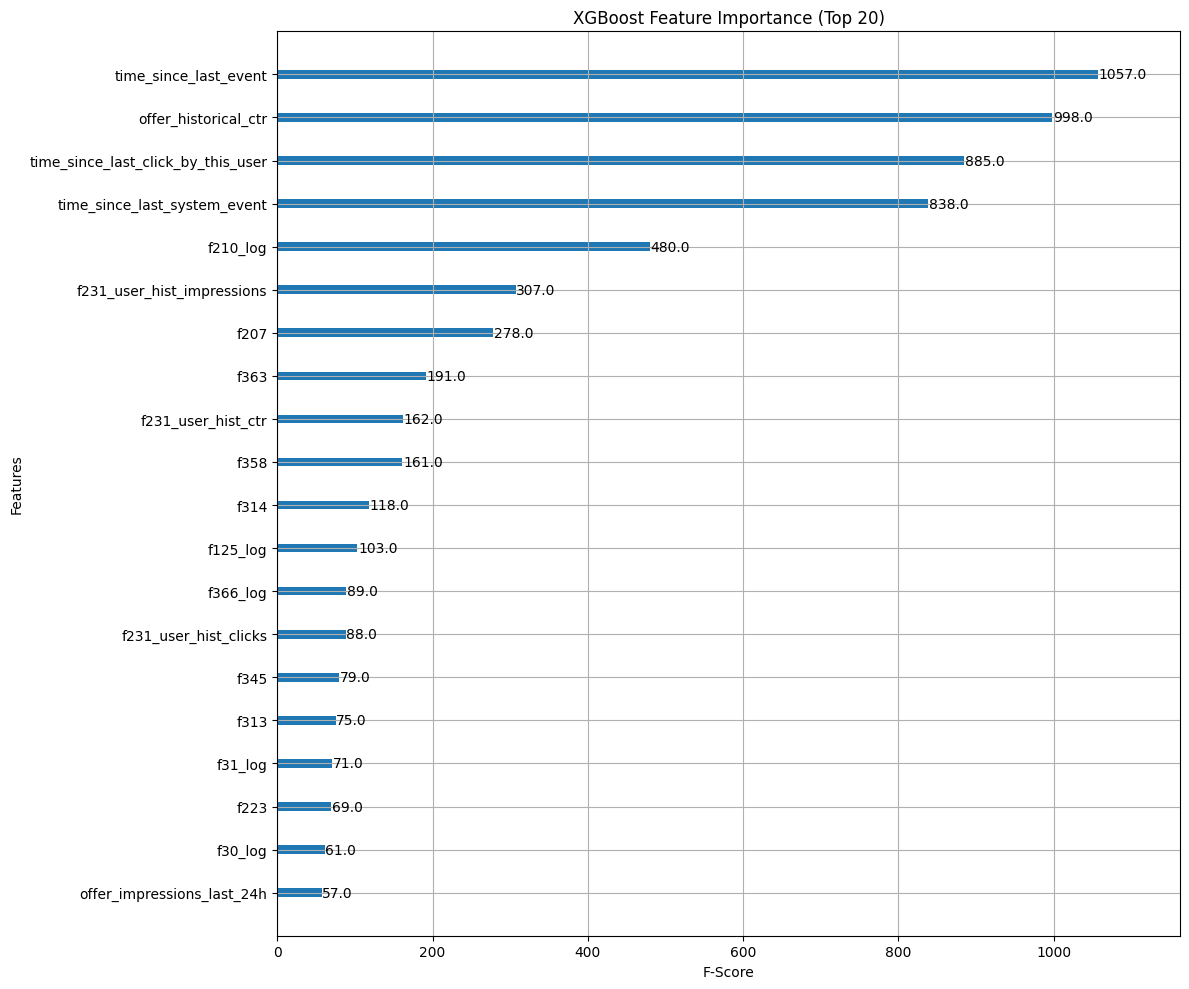

In [6]:
# Add this import at the top of your script
import matplotlib.pyplot as plt

# --- 7. Plot Feature Importance (Add this at the end of your script) ---
print("\n--- Plotting Feature Importance ---")

# Set figure size for better readability
plt.rcParams['figure.figsize'] = [12, 10]

# Plot top 20 features
xgb.plot_importance(model, max_num_features=20)
plt.title("XGBoost Feature Importance (Top 20)")
plt.xlabel("F-Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [46]:
positive_idx = train_df.index[ train_df['y'] == 1 ]
row = train_df.loc[ positive_idx,
                    ['y', 'time_since_offer_last_clicked'] ]
print(row)


        y  time_since_offer_last_clicked
199     1                   9.999999e+06
201     1                   9.999999e+06
219     1                   9.999999e+06
220     1                   9.999999e+06
226     1                   9.999999e+06
...    ..                            ...
616099  1                   8.409994e+02
616102  1                   6.222999e+03
616116  1                   1.089994e+02
616117  1                   7.420007e+02
616126  1                   1.330005e+02

[30923 rows x 2 columns]


In [29]:
train_df.loc[i, ['y','time_since_offer_last_clicked']]

NameError: name 'i' is not defined

In [4]:
train = pd.read_parquet(r"D:\Amex Hackathon\train_data.parquet")

In [3]:
test = pd.read_parquet(r"D:\Amex Hackathon\test_data.parquet")

In [13]:
train['id3'].value_counts()

id3
92636     2446
72717     2434
99856     2433
95157     2428
281783    2397
          ... 
681802       1
74465        1
63872        1
14996        1
754452       1
Name: count, Length: 757, dtype: int64

In [14]:
test['id3'].value_counts()

id3
84457     1143
72717     1124
170747    1122
159555    1119
605824    1118
          ... 
440475       1
73408        1
2683         1
58616        1
10139        1
Name: count, Length: 727, dtype: int64

In [9]:
train.shape

(770164, 372)

In [21]:
!pip install seaborn

In [8]:
test.shape

(369301, 371)

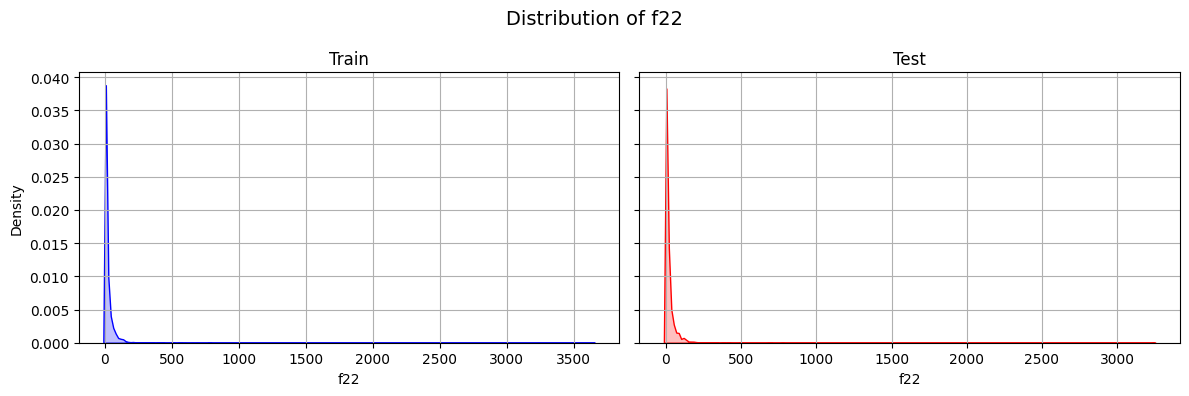

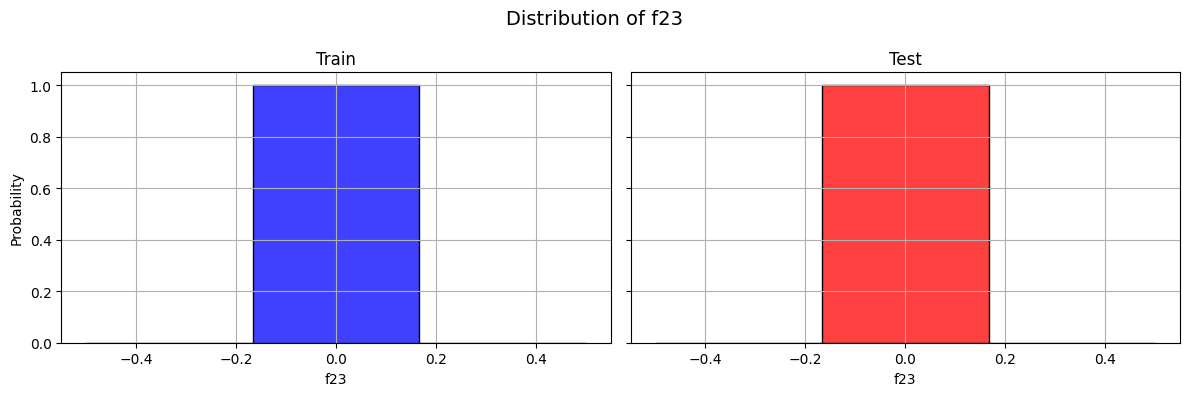

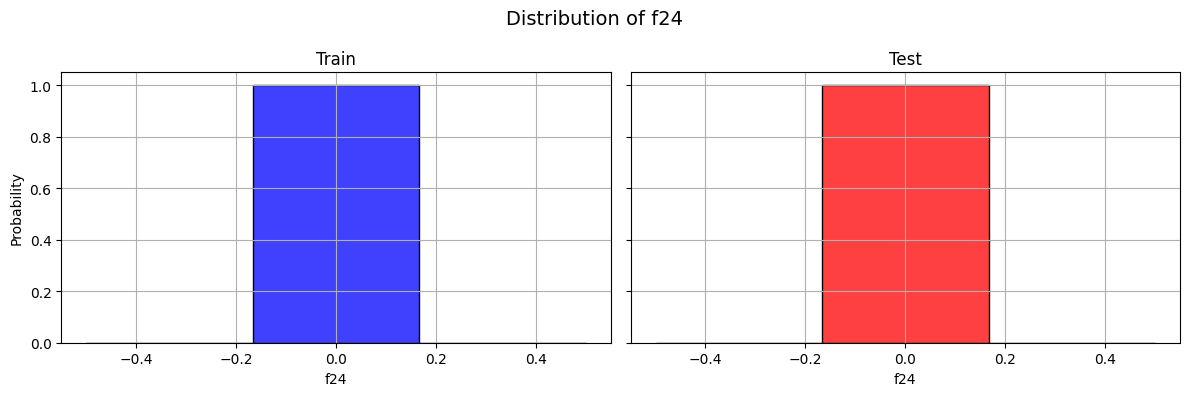

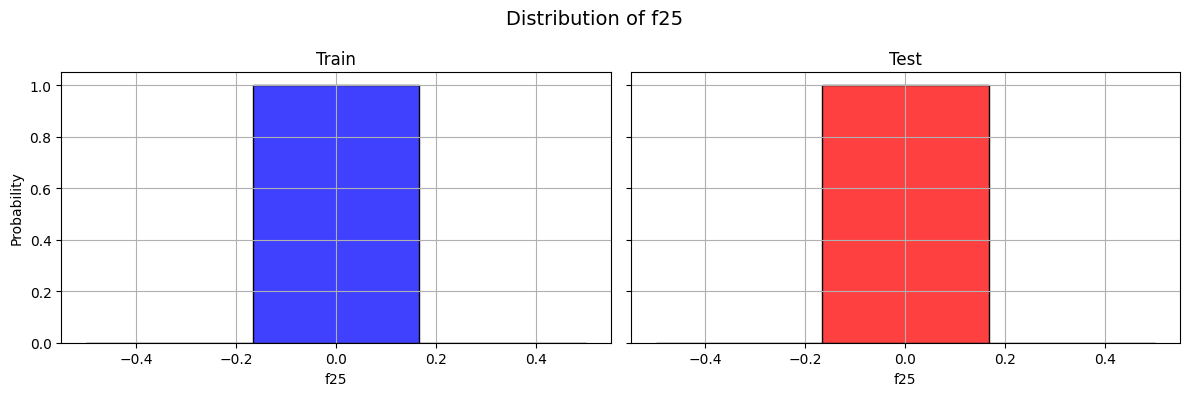

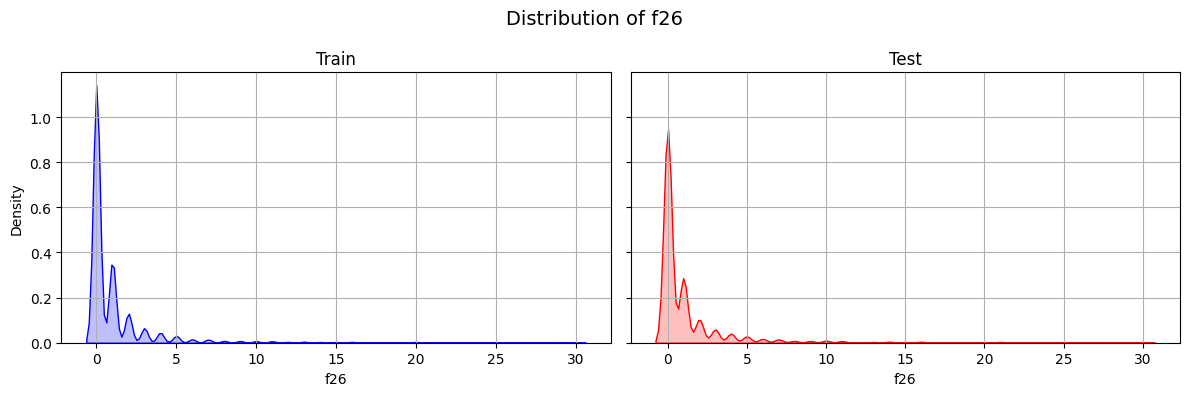

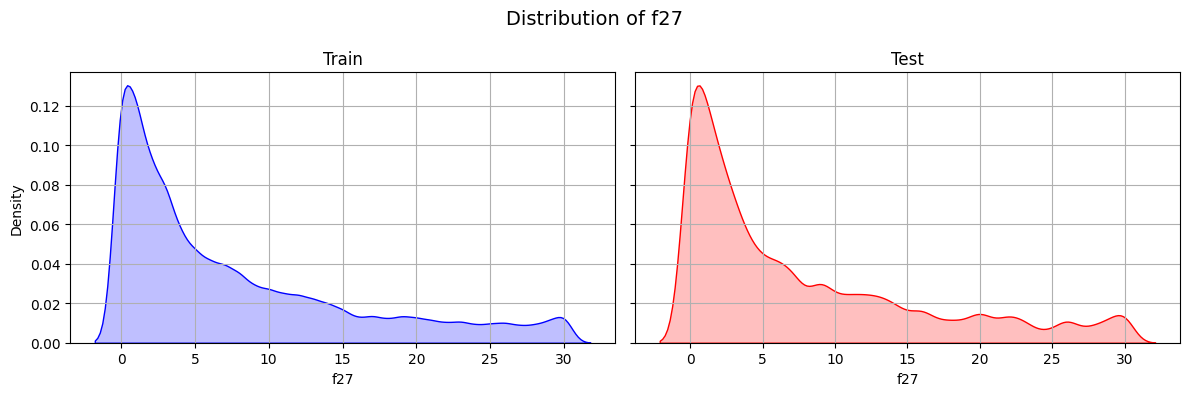

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
# train = pd.read_parquet("train.parquet")
# test = pd.read_parquet("test.parquet")

# Features to plot
features = ['f22', 'f23', 'f24', 'f25', 'f26', 'f27']

for feature in features:
    if feature in train.columns and feature in test.columns:
        # Ensure numeric and clean
        train_feat = pd.to_numeric(train[feature], errors='coerce').dropna()
        test_feat = pd.to_numeric(test[feature], errors='coerce').dropna()

        # Create side-by-side plots
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
        fig.suptitle(f'Distribution of {feature}', fontsize=14)

        # Plot train
        if train_feat.nunique() <= 5:
            sns.histplot(train_feat, stat='probability', bins=3, kde=False, color='blue', ax=axes[0])
        else:
            sns.kdeplot(train_feat, fill=True, color='blue', ax=axes[0])
        axes[0].set_title("Train")
        axes[0].grid(True)

        # Plot test
        if test_feat.nunique() <= 5:
            sns.histplot(test_feat, stat='probability', bins=3, kde=False, color='red', ax=axes[1])
        else:
            sns.kdeplot(test_feat, fill=True, color='red', ax=axes[1])
        axes[1].set_title("Test")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()
        plt.close()


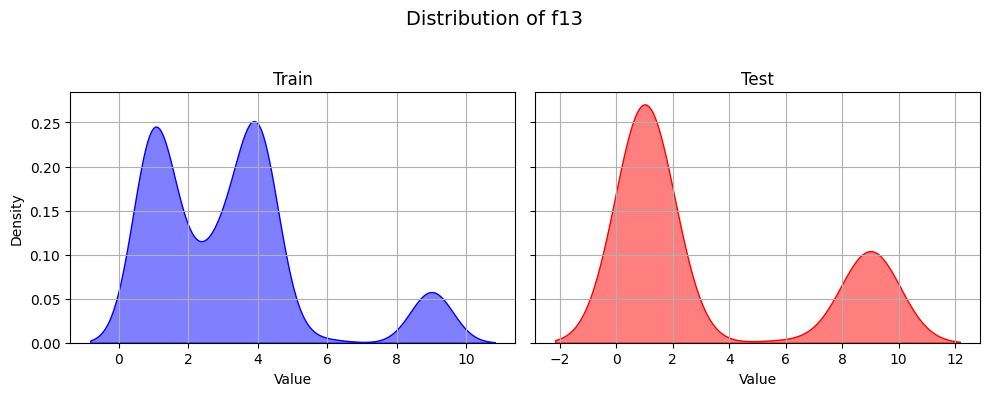

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")


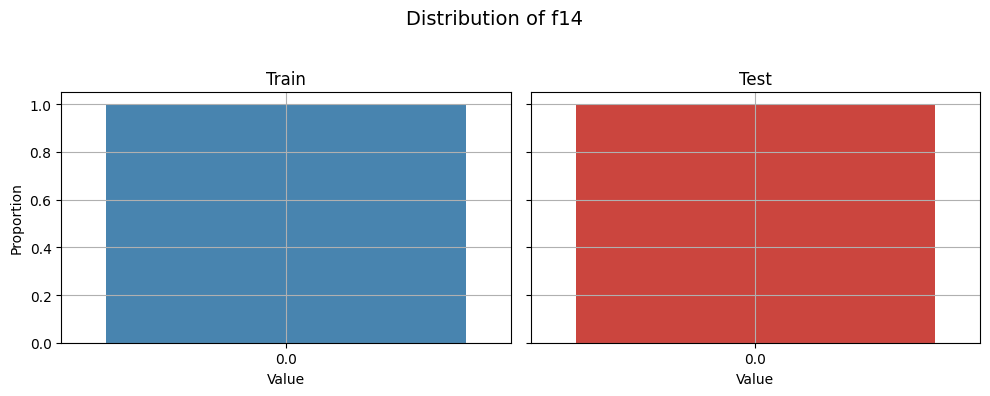

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")


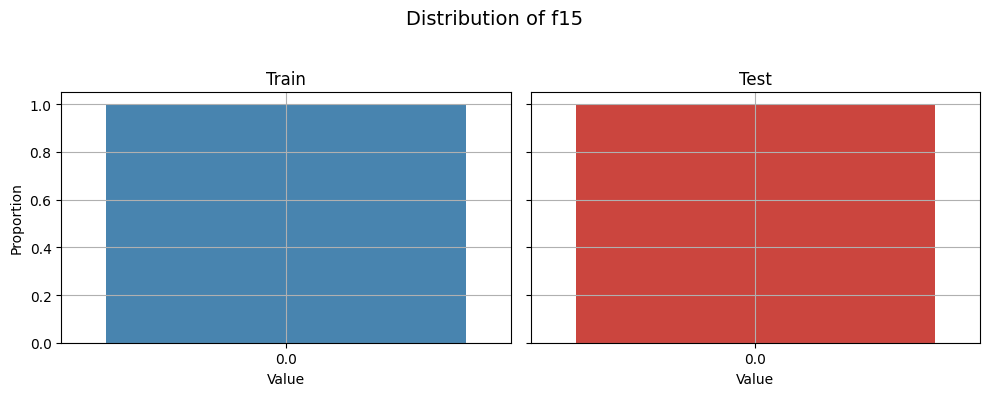

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")


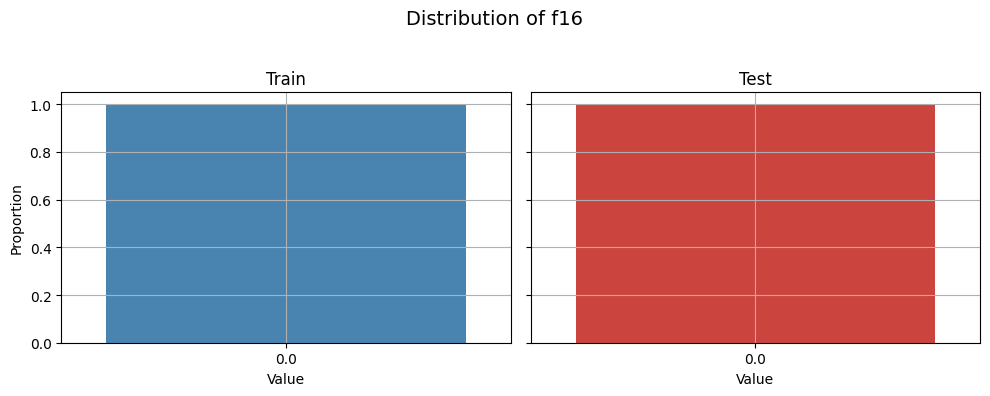

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")


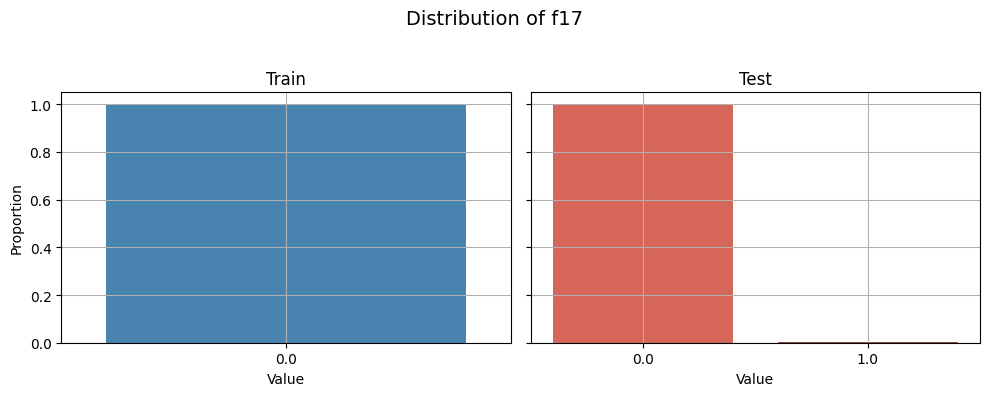

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")


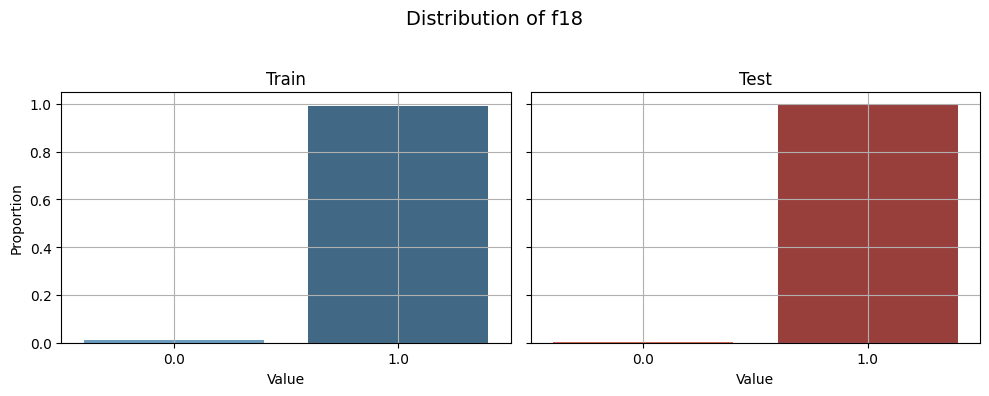

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")


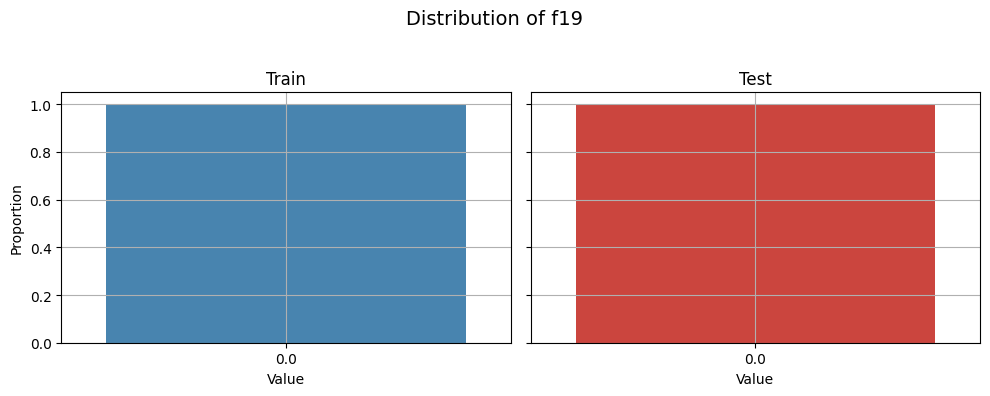

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")


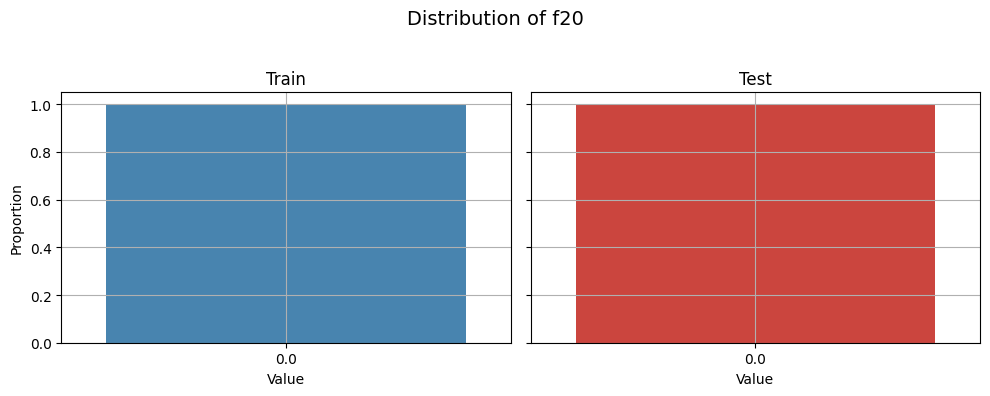

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\3857573197.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")


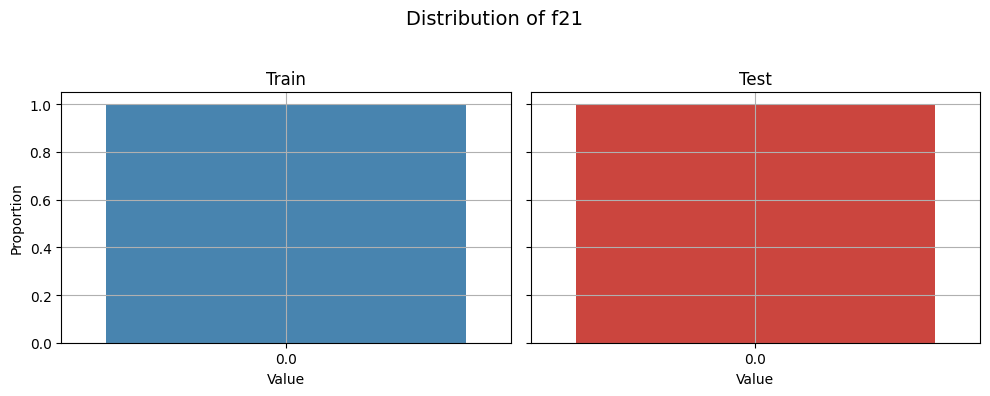

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

page_features = ['f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21']

for feature in page_features:
    # Ensure correct type
    train_col = pd.to_numeric(train[feature], errors='coerce')
    test_col = pd.to_numeric(test[feature], errors='coerce')

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    fig.suptitle(f'Distribution of {feature}', fontsize=14)

    if feature != 'f13':  # Binary features (bar plot)
        # Train
        train_dist = train_col.value_counts(normalize=True).sort_index()
        sns.barplot(x=train_dist.index.astype(str), y=train_dist.values, ax=axs[0], palette="Blues_d")
        axs[0].set_title('Train')
        axs[0].set_xlabel("Value")
        axs[0].set_ylabel("Proportion")
        axs[0].grid(True)

        # Test
        test_dist = test_col.value_counts(normalize=True).sort_index()
        sns.barplot(x=test_dist.index.astype(str), y=test_dist.values, ax=axs[1], palette="Reds_d")
        axs[1].set_title('Test')
        axs[1].set_xlabel("Value")
        axs[1].grid(True)

    else:  # f13: continuous feature (KDE plot)
        sns.kdeplot(train_col.dropna(), fill=True, alpha=0.5, ax=axs[0], color='blue')
        axs[0].set_title('Train')
        axs[0].set_xlabel("Value")
        axs[0].set_ylabel("Density")
        axs[0].grid(True)

        sns.kdeplot(test_col.dropna(), fill=True, alpha=0.5, ax=axs[1], color='red')
        axs[1].set_title('Test')
        axs[1].set_xlabel("Value")
        axs[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


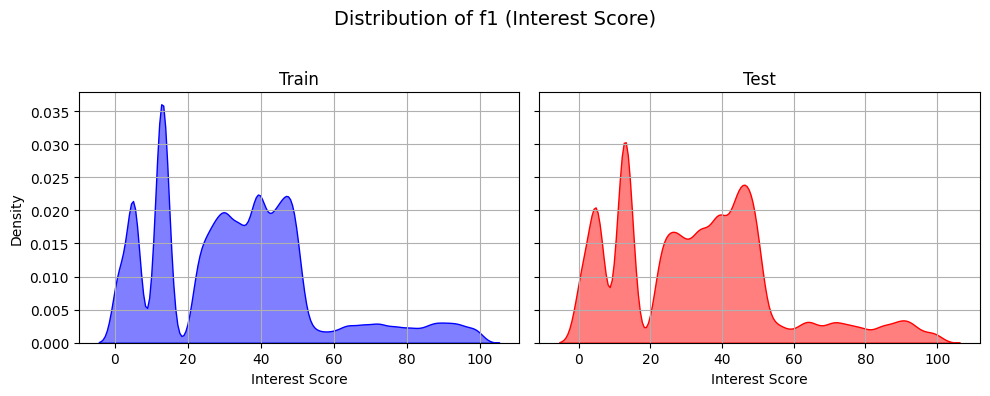

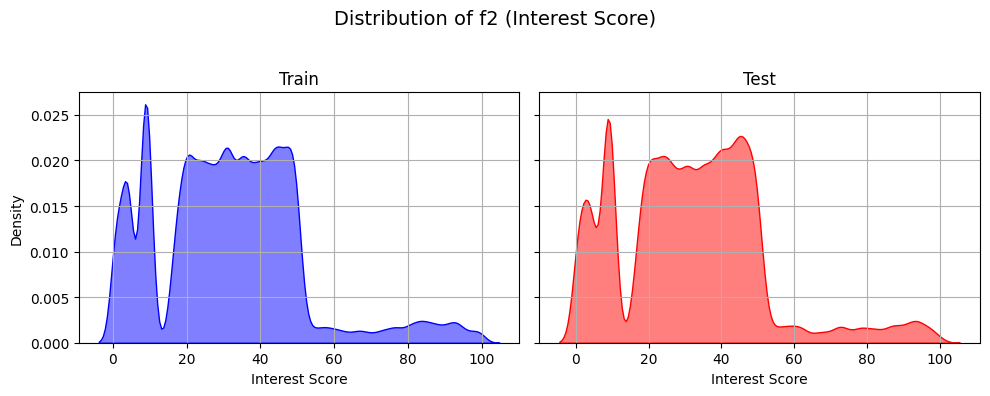

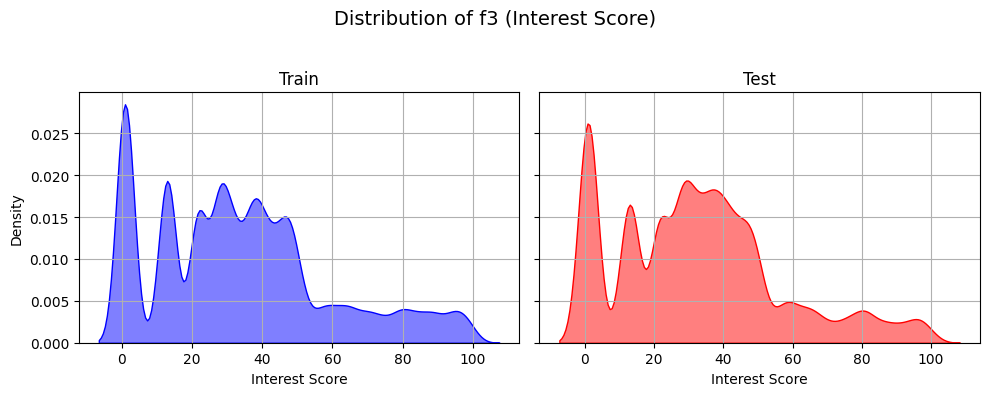

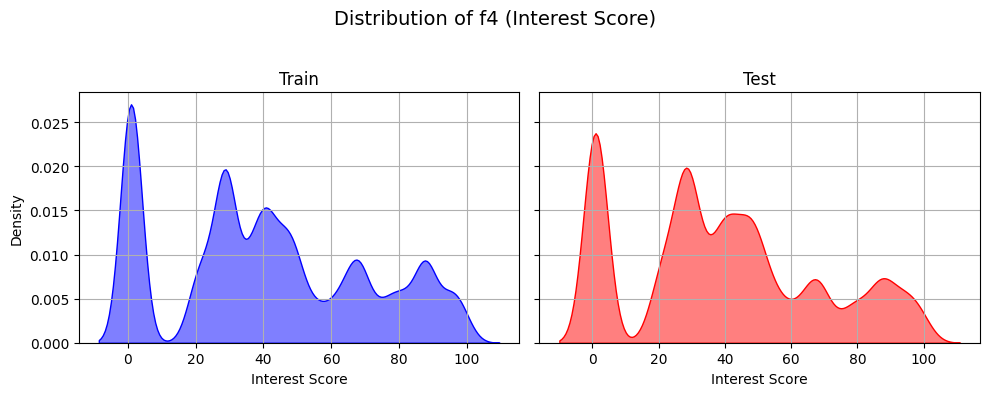

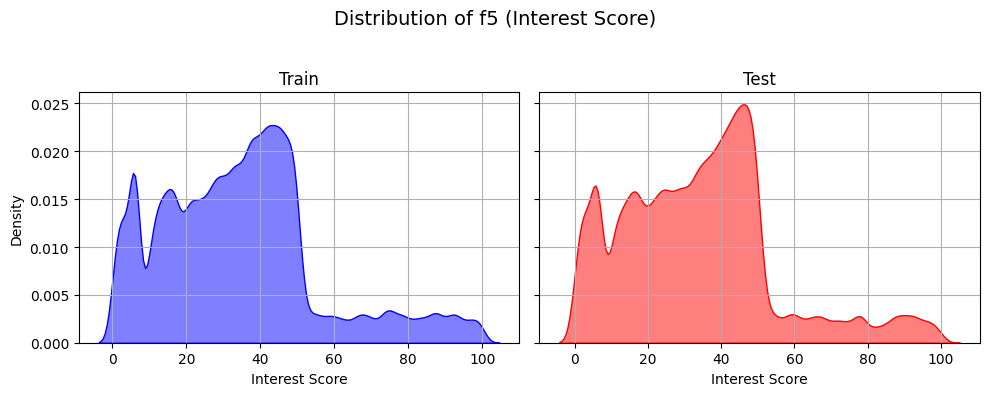

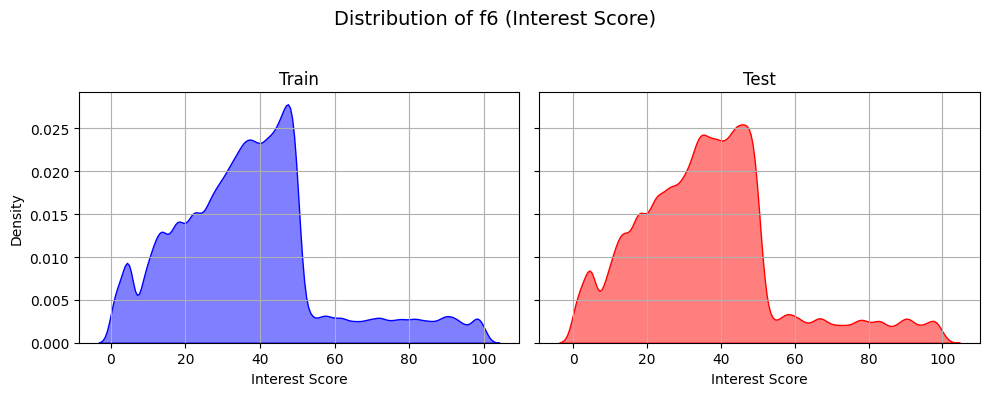

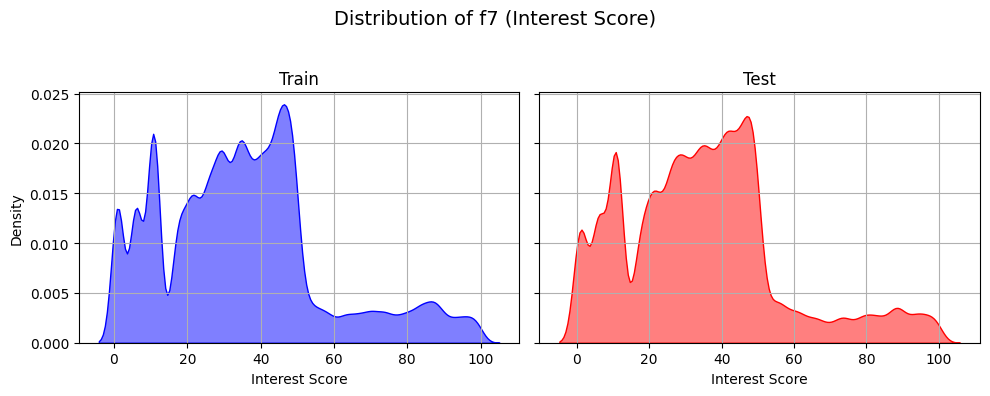

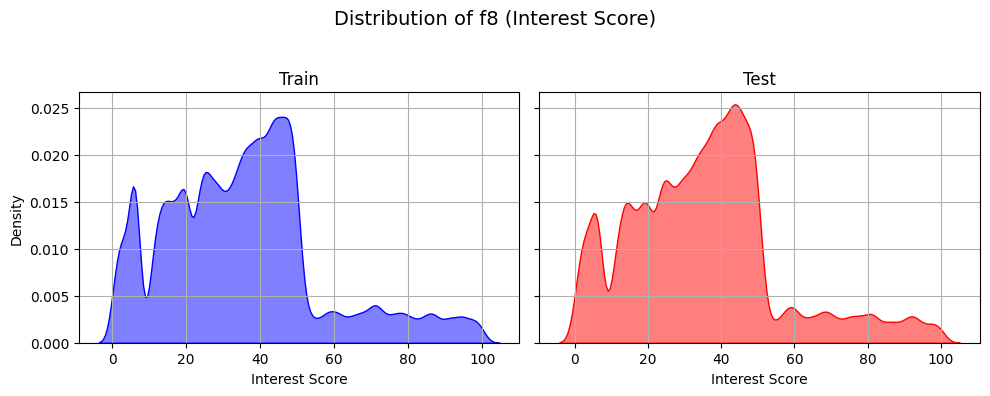

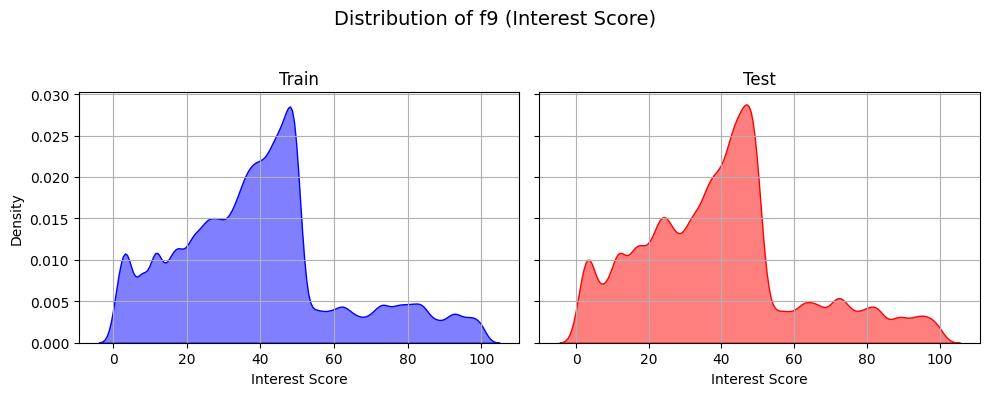

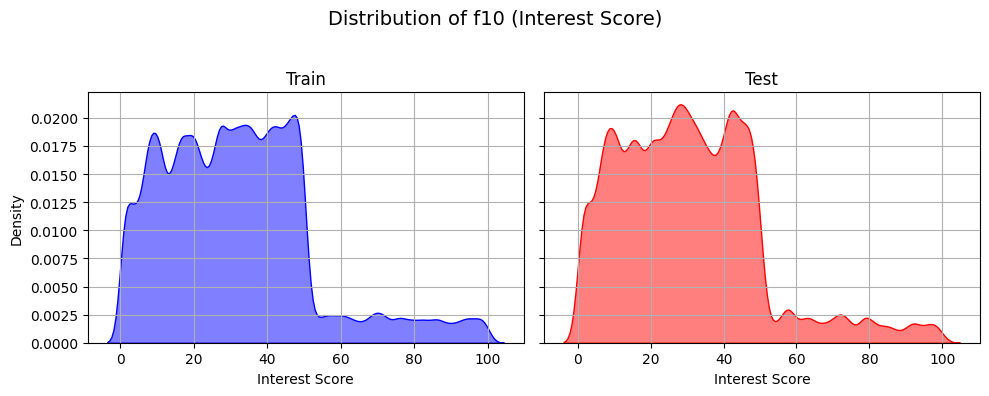

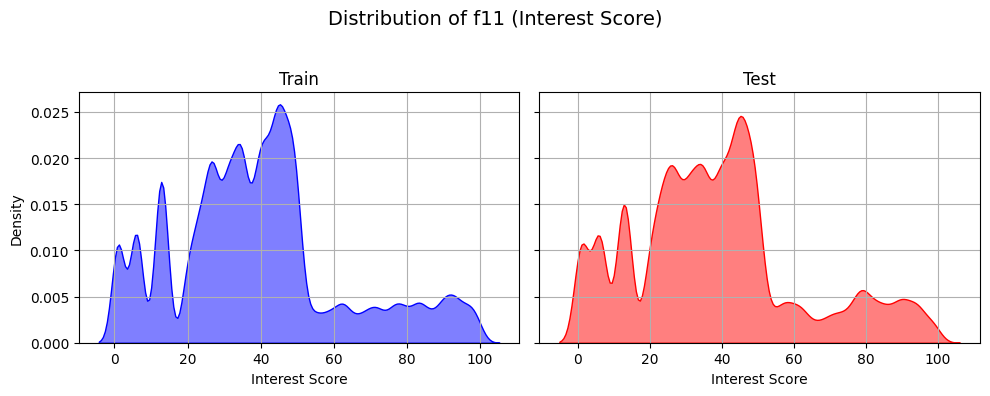

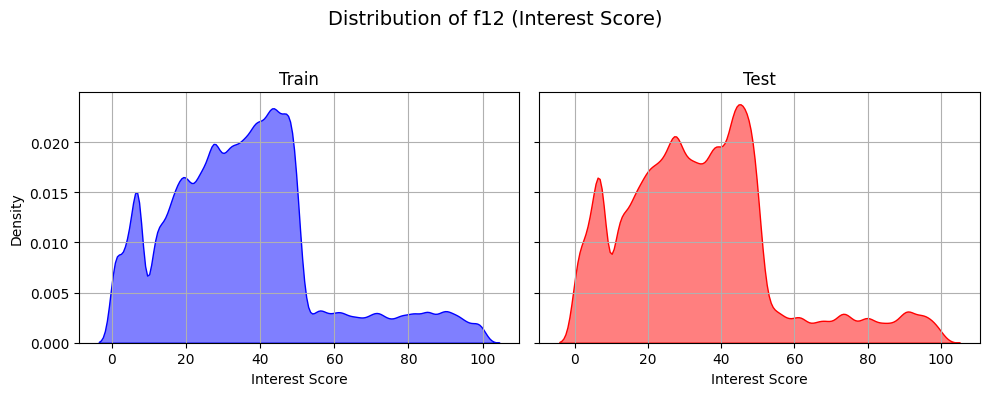

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

interest_features = [f'f{i}' for i in range(1, 13)]

for feature in interest_features:
    train_col = pd.to_numeric(train[feature], errors='coerce')
    test_col = pd.to_numeric(test[feature], errors='coerce')

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    fig.suptitle(f'Distribution of {feature} (Interest Score)', fontsize=14)

    # Train KDE
    sns.kdeplot(train_col.dropna(), fill=True, ax=axs[0], color='blue', alpha=0.5)
    axs[0].set_title("Train")
    axs[0].set_xlabel("Interest Score")
    axs[0].set_ylabel("Density")
    axs[0].grid(True)

    # Test KDE
    sns.kdeplot(test_col.dropna(), fill=True, ax=axs[1], color='red', alpha=0.5)
    axs[1].set_title("Test")
    axs[1].set_xlabel("Interest Score")
    axs[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


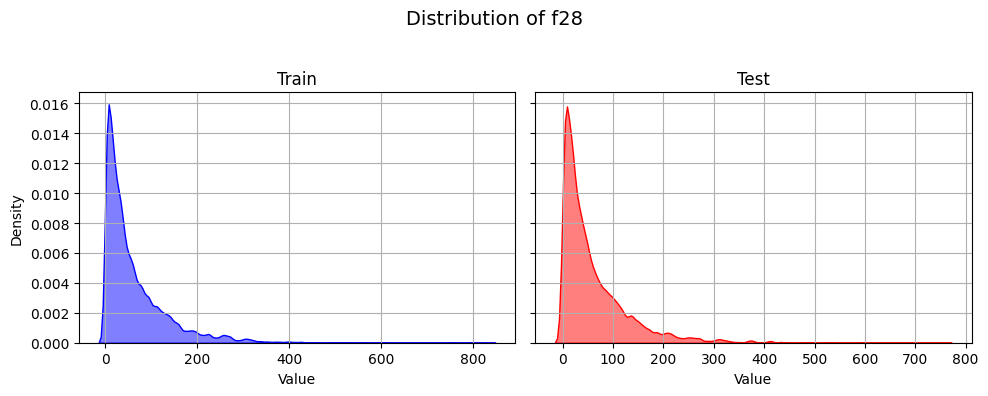

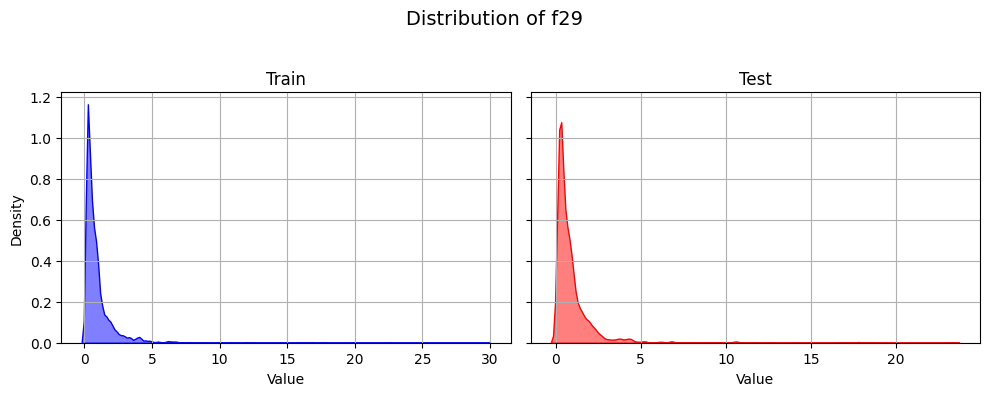

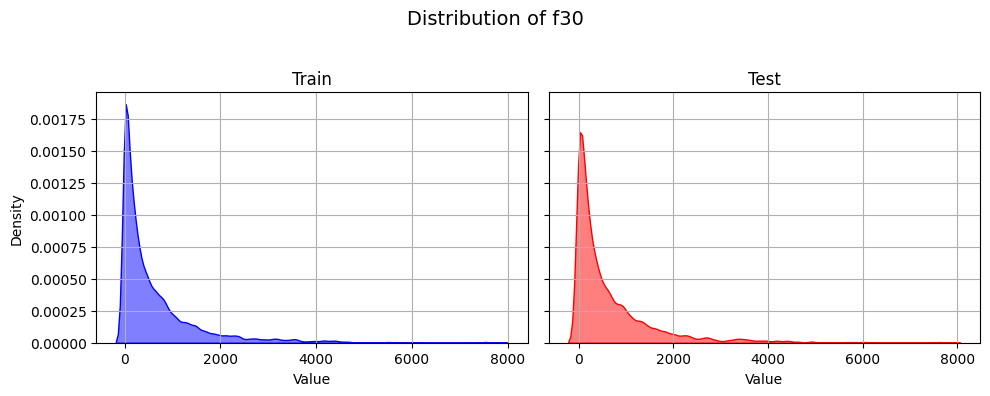

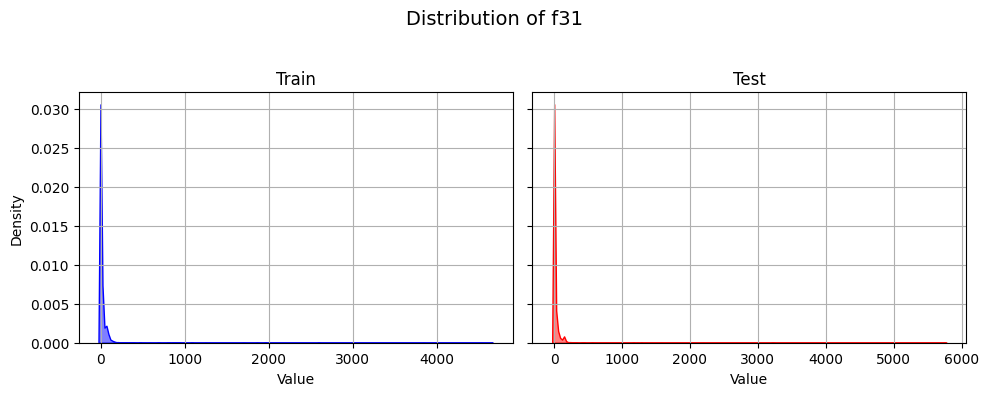

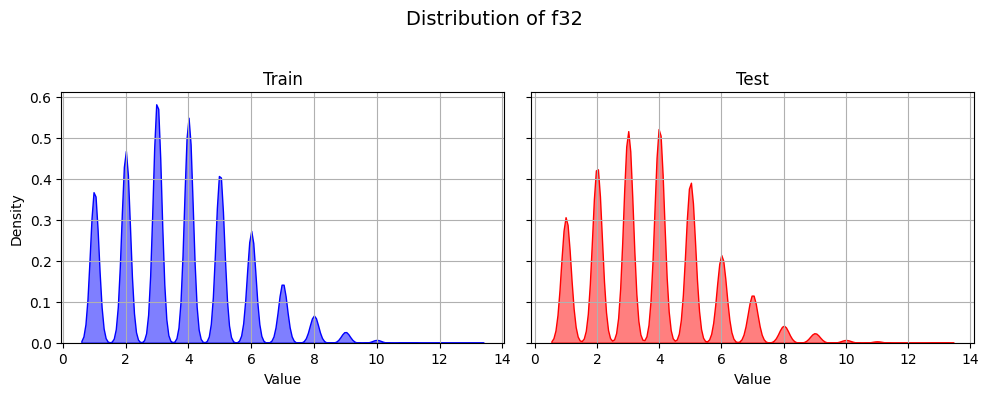

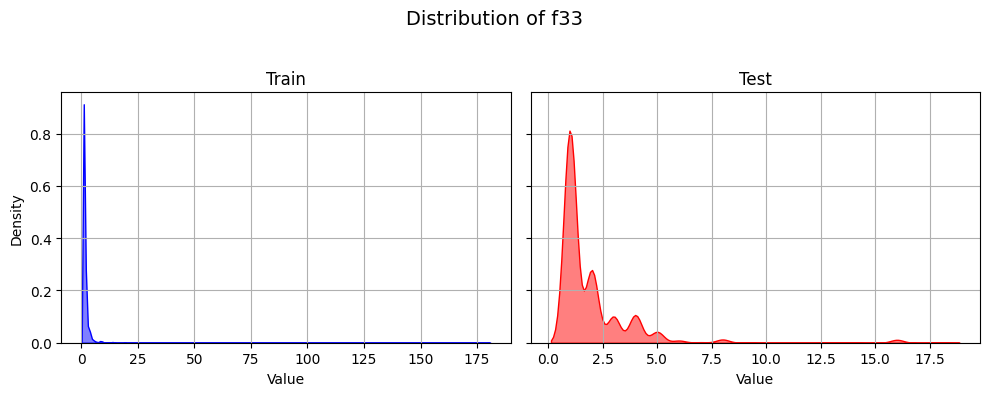

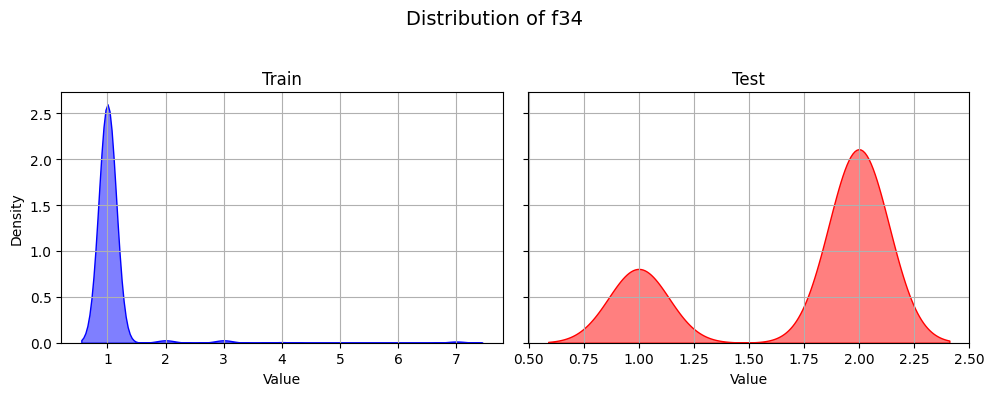

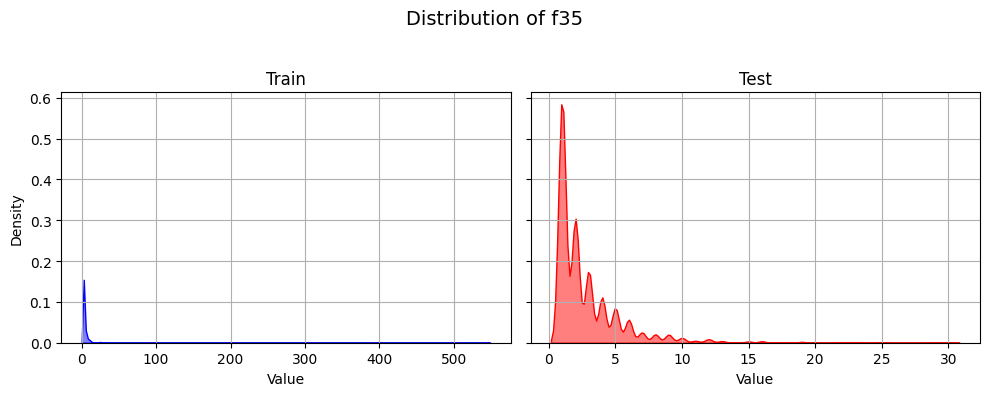

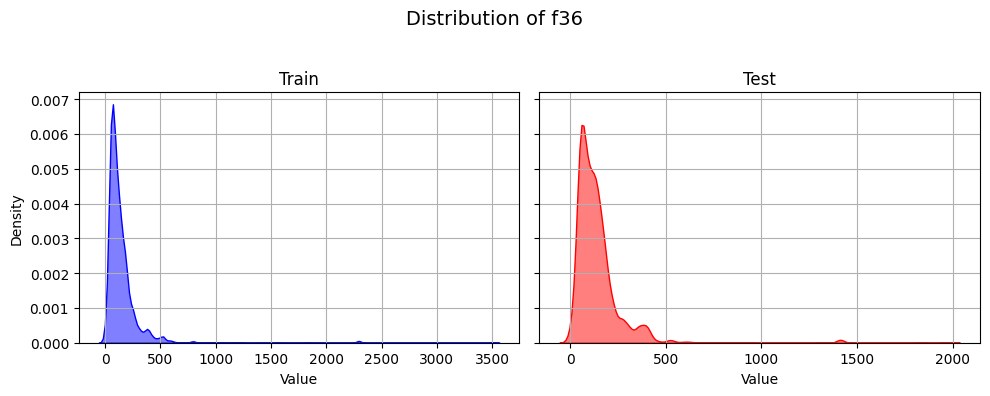

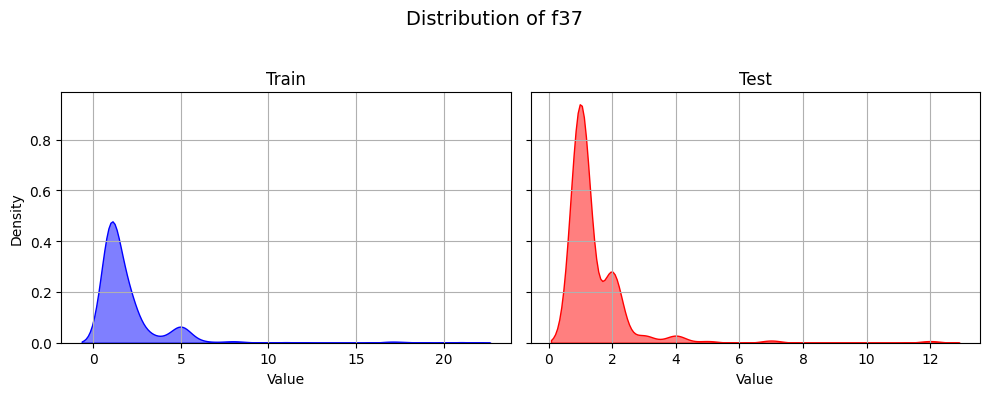

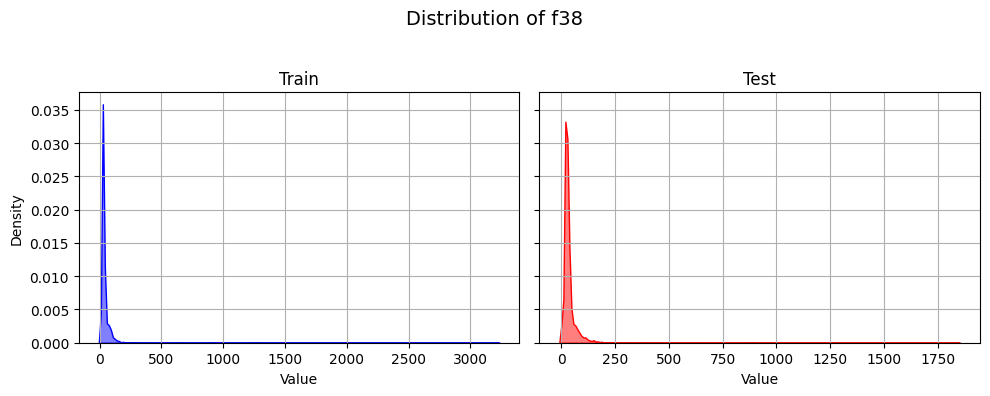

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# List of features to plot
features_28_to_38 = [f"f{i}" for i in range(28, 39)]

# Plotting
for feature in features_28_to_38:
    train_col = pd.to_numeric(train[feature], errors='coerce')
    test_col = pd.to_numeric(test[feature], errors='coerce')

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    fig.suptitle(f'Distribution of {feature}', fontsize=14)

    # Train KDE
    sns.kdeplot(train_col.dropna(), fill=True, ax=axs[0], color='blue', alpha=0.5)
    axs[0].set_title("Train")
    axs[0].set_xlabel("Value")
    axs[0].set_ylabel("Density")
    axs[0].grid(True)

    # Test KDE
    sns.kdeplot(test_col.dropna(), fill=True, ax=axs[1], color='red', alpha=0.5)
    axs[1].set_title("Test")
    axs[1].set_xlabel("Value")
    axs[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


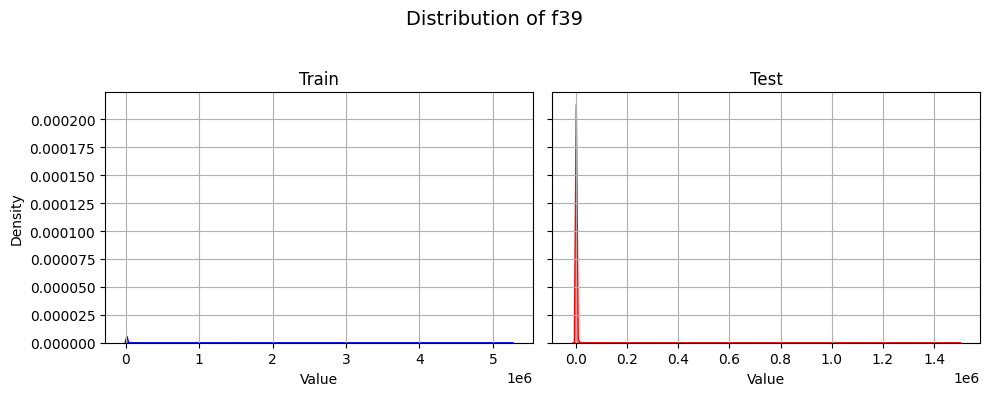

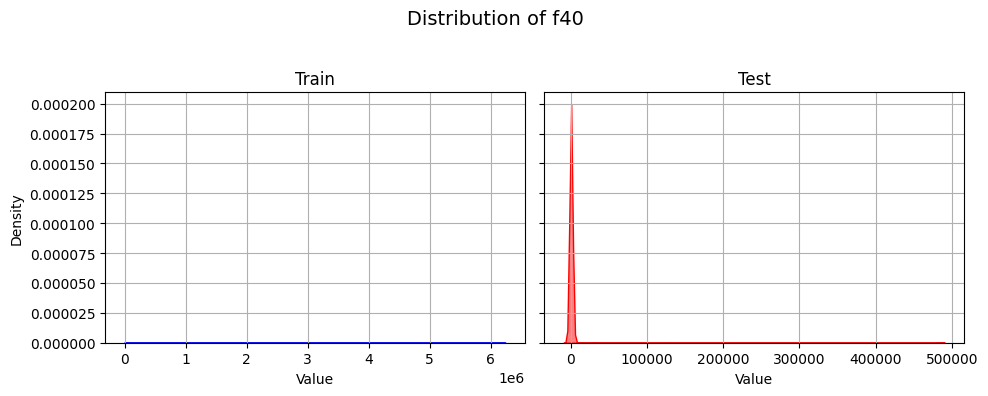

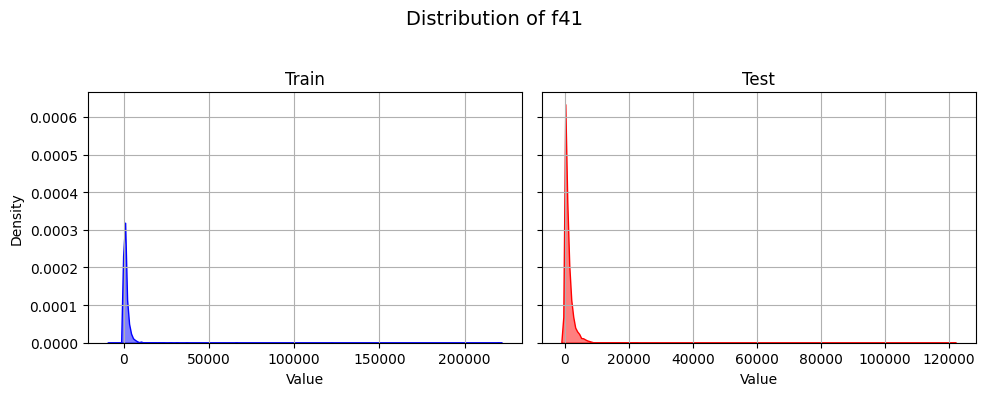

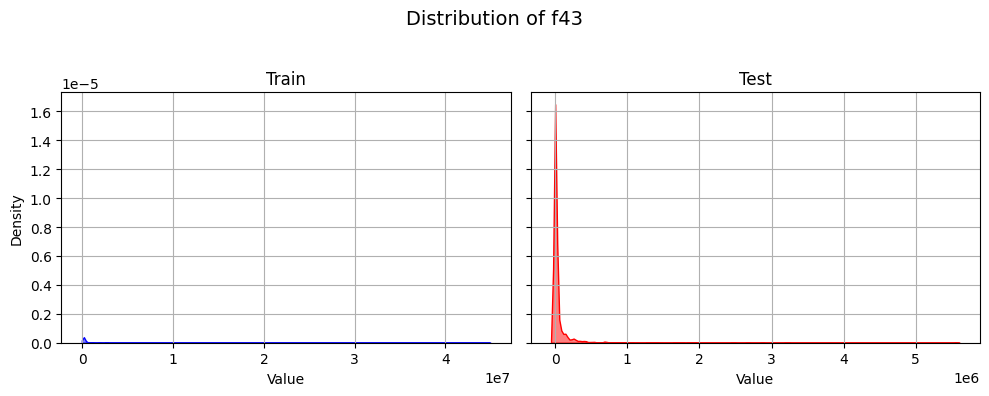

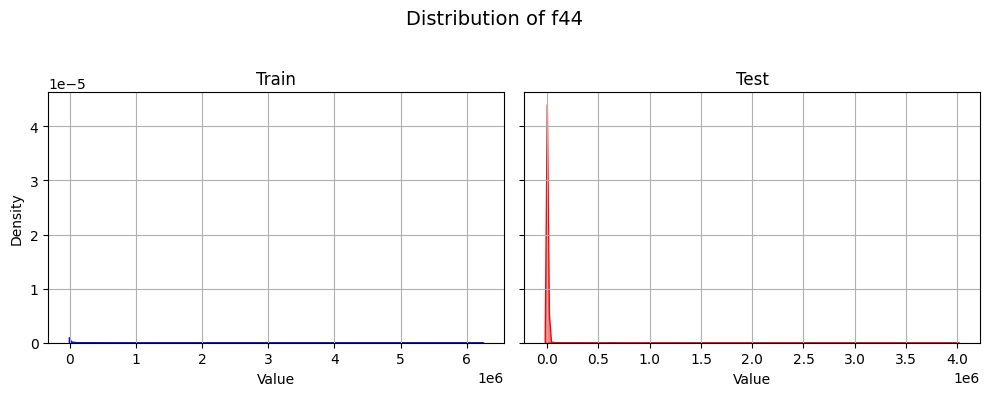

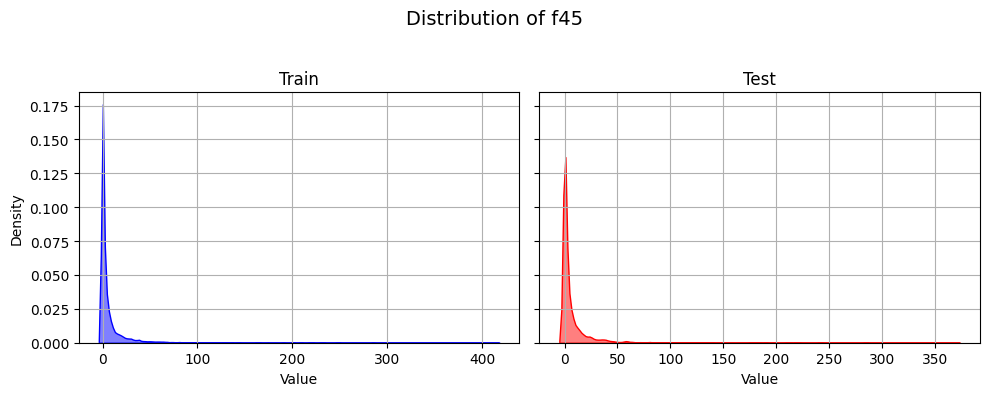

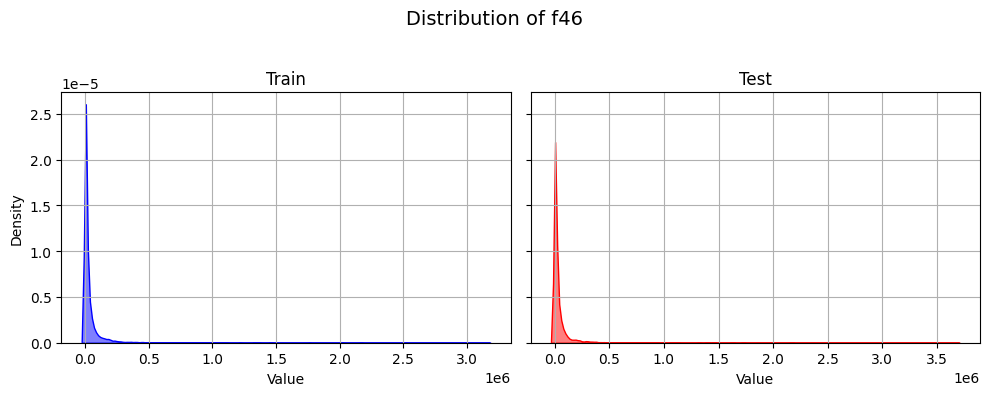

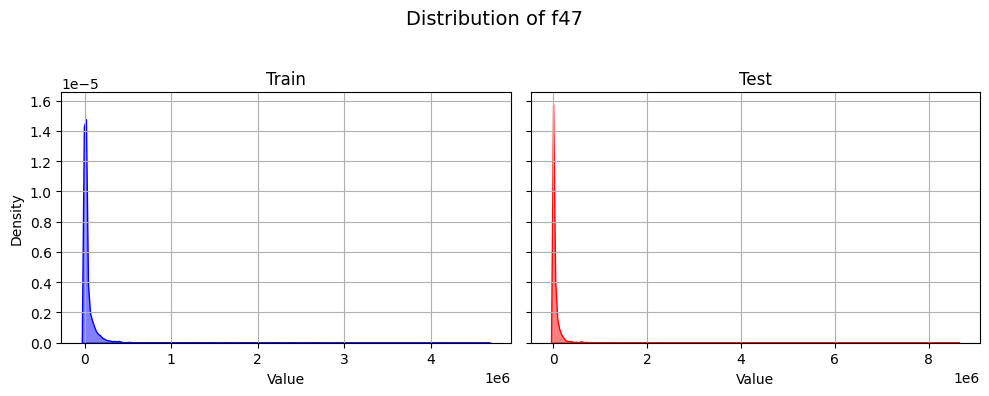

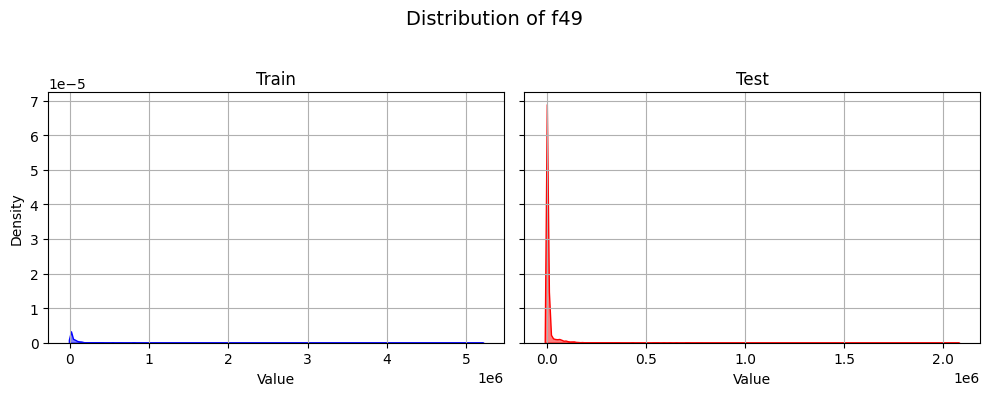

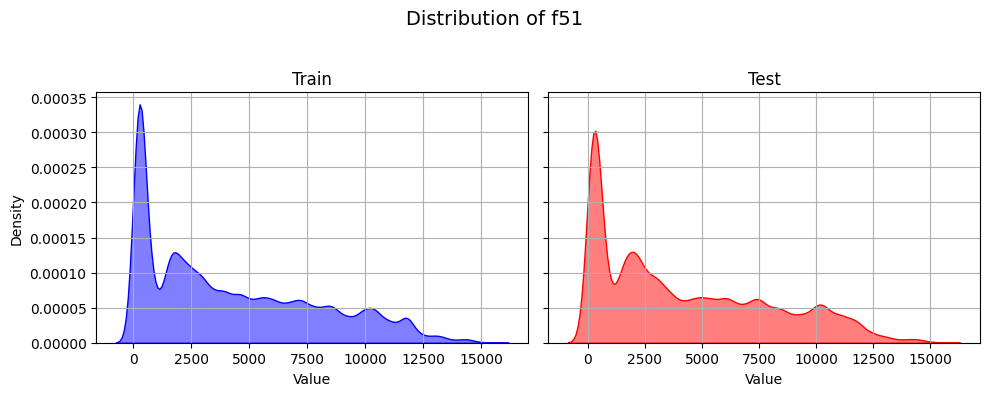

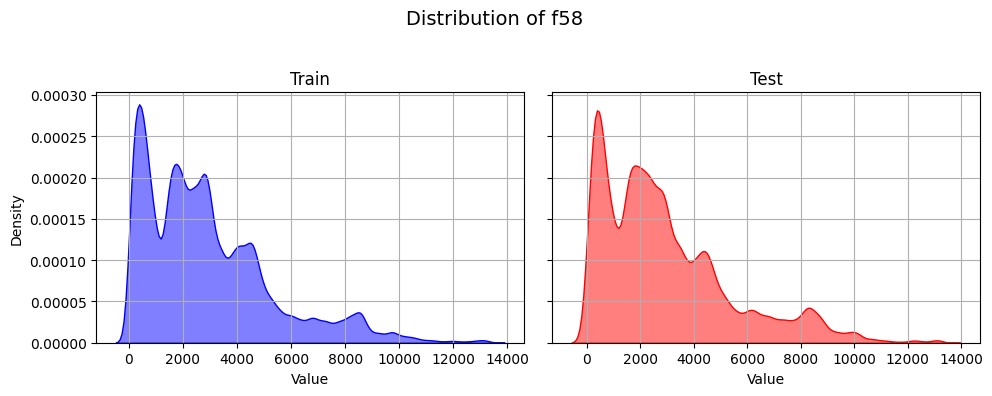

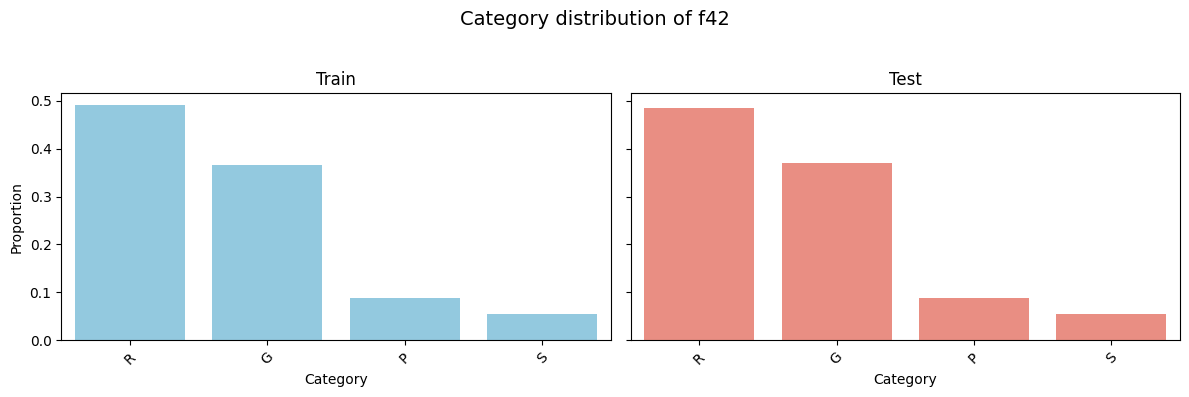

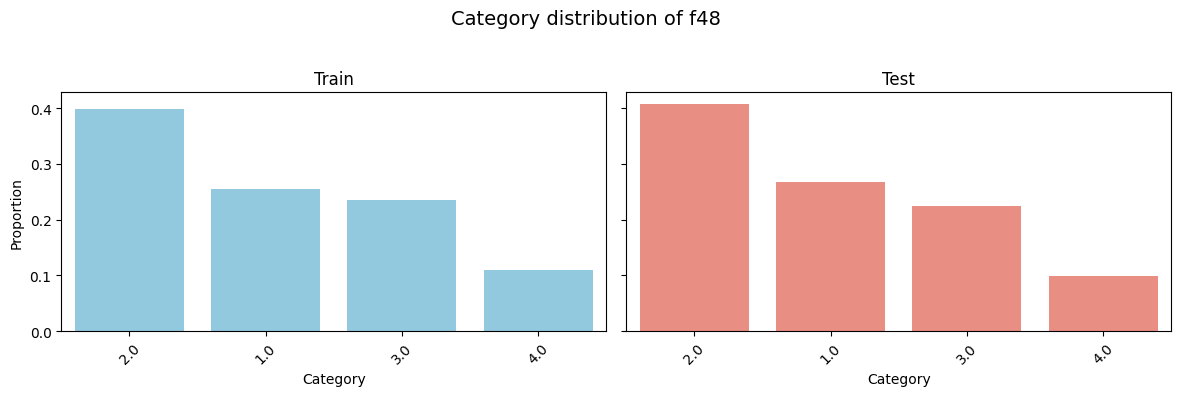

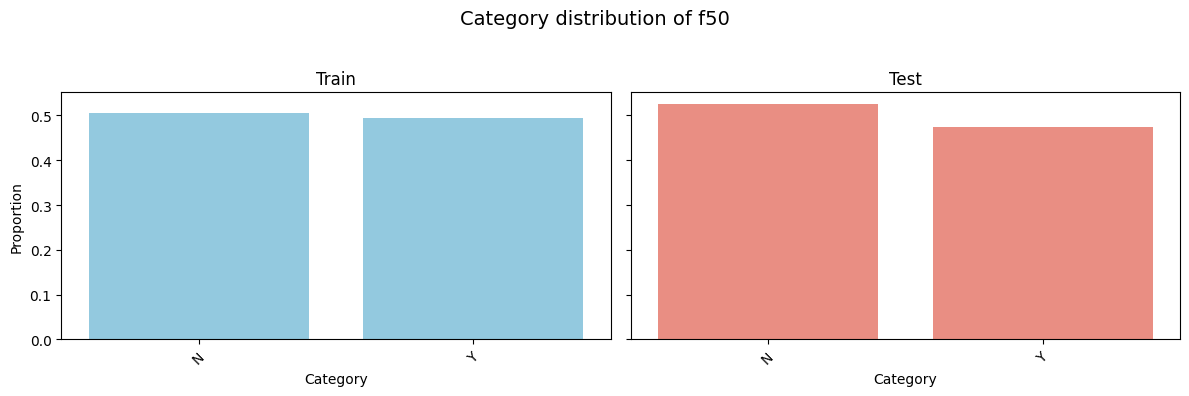

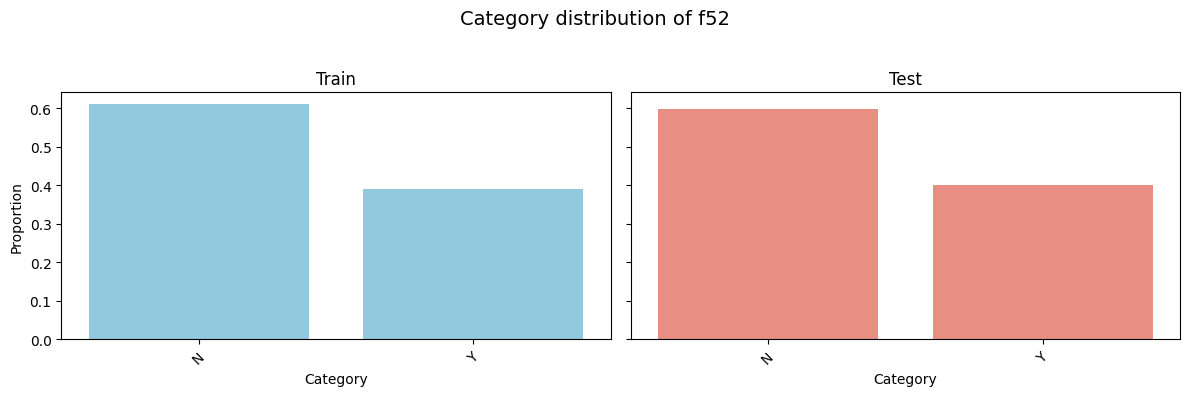

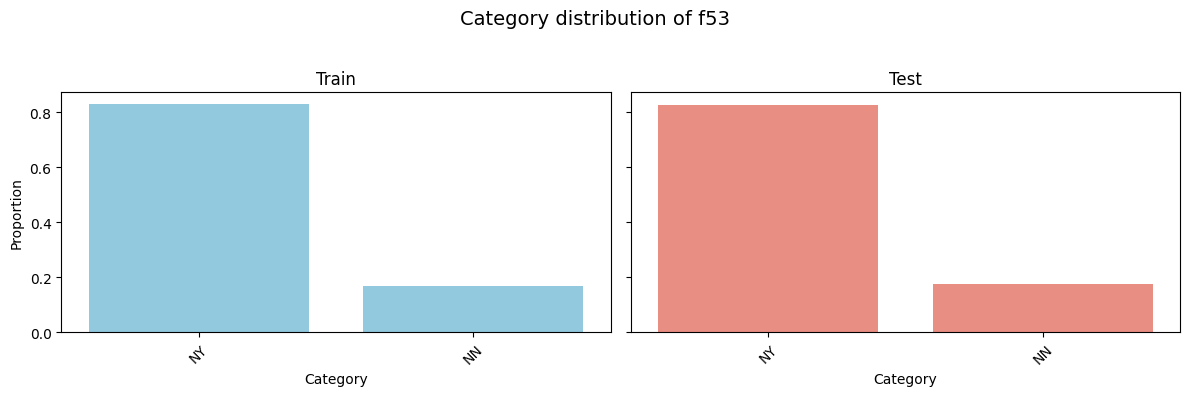

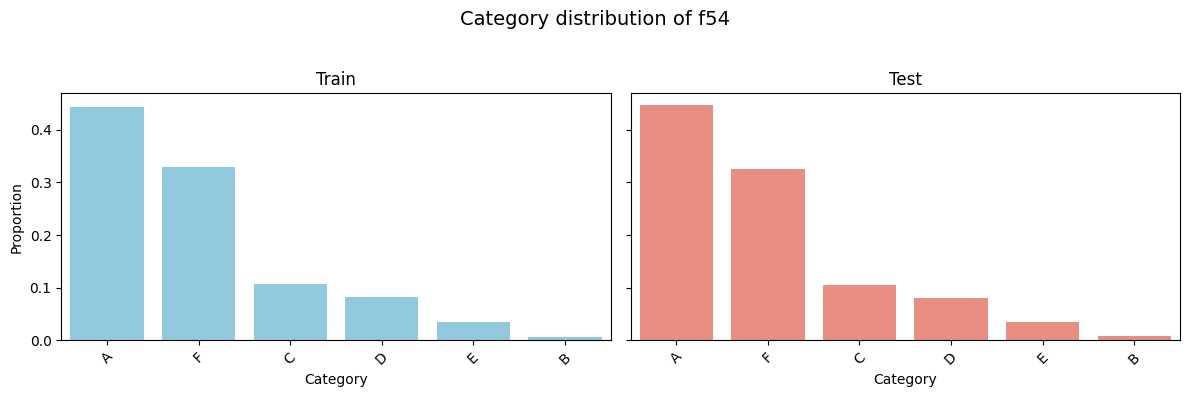

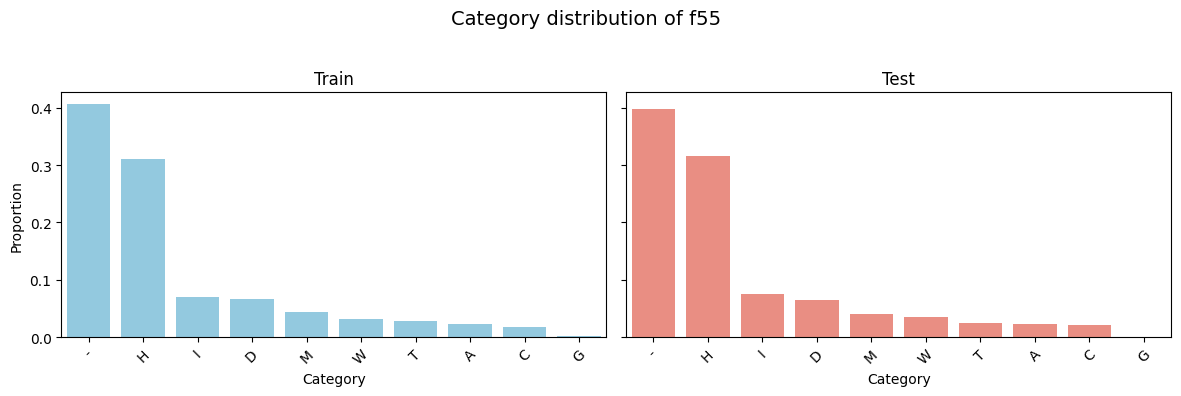

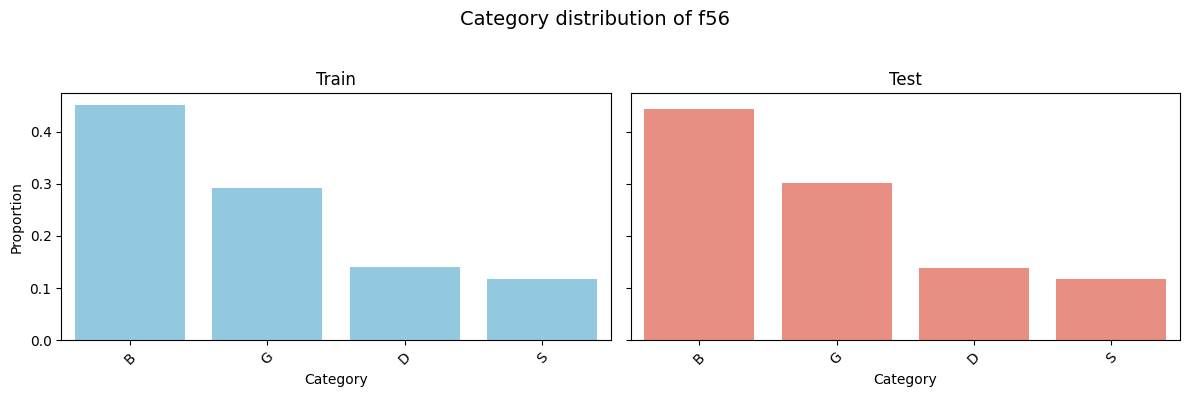

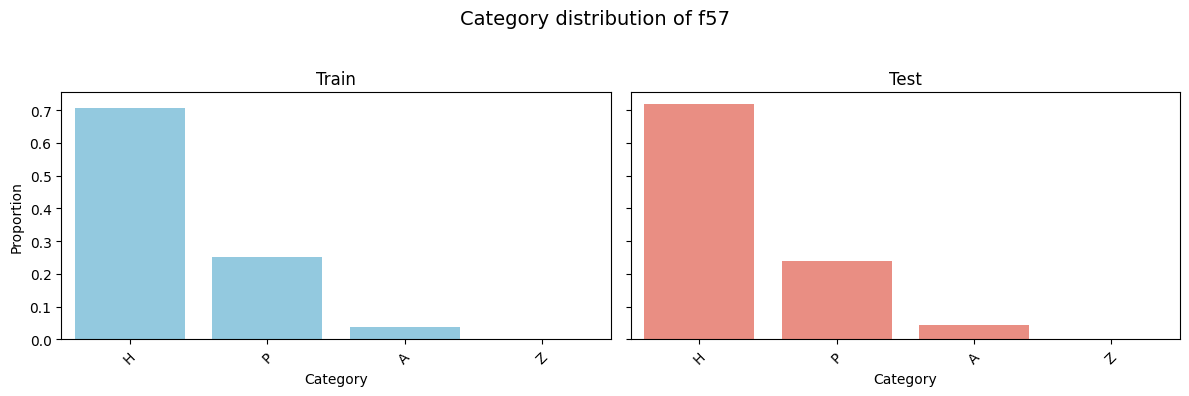

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define lists
numerical_features = ['f39', 'f40', 'f41', 'f43', 'f44', 'f45', 'f46', 'f47', 'f49', 'f51', 'f58']
categorical_features = ['f42', 'f48', 'f50', 'f52', 'f53', 'f54', 'f55', 'f56', 'f57']

# Plot numerical features
for feature in numerical_features:
    train_col = pd.to_numeric(train[feature], errors='coerce')
    test_col = pd.to_numeric(test[feature], errors='coerce')

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    fig.suptitle(f'Distribution of {feature}', fontsize=14)

    # Train plot
    sns.kdeplot(train_col.dropna(), fill=True, ax=axs[0], color='blue', alpha=0.5)
    axs[0].set_title("Train")
    axs[0].set_xlabel("Value")
    axs[0].set_ylabel("Density")
    axs[0].grid(True)

    # Test plot
    sns.kdeplot(test_col.dropna(), fill=True, ax=axs[1], color='red', alpha=0.5)
    axs[1].set_title("Test")
    axs[1].set_xlabel("Value")
    axs[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Plot categorical features
for feature in categorical_features:
    train_counts = train[feature].value_counts(normalize=True)
    test_counts = test[feature].value_counts(normalize=True)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    fig.suptitle(f'Category distribution of {feature}', fontsize=14)

    # Train bar plot
    sns.barplot(x=train_counts.index.astype(str), y=train_counts.values, ax=axs[0], color='skyblue')
    axs[0].set_title('Train')
    axs[0].set_xlabel("Category")
    axs[0].set_ylabel("Proportion")
    axs[0].tick_params(axis='x', rotation=45)

    # Test bar plot
    sns.barplot(x=test_counts.index.astype(str), y=test_counts.values, ax=axs[1], color='salmon')
    axs[1].set_title('Test')
    axs[1].set_xlabel("Category")
    axs[1].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


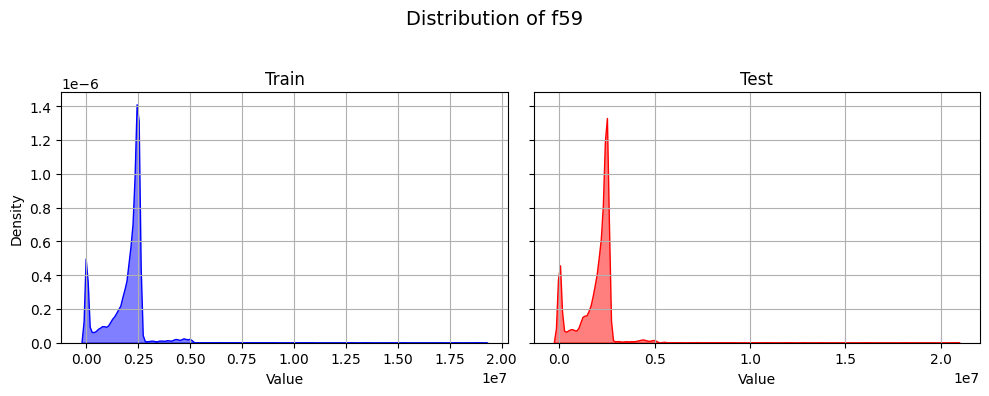

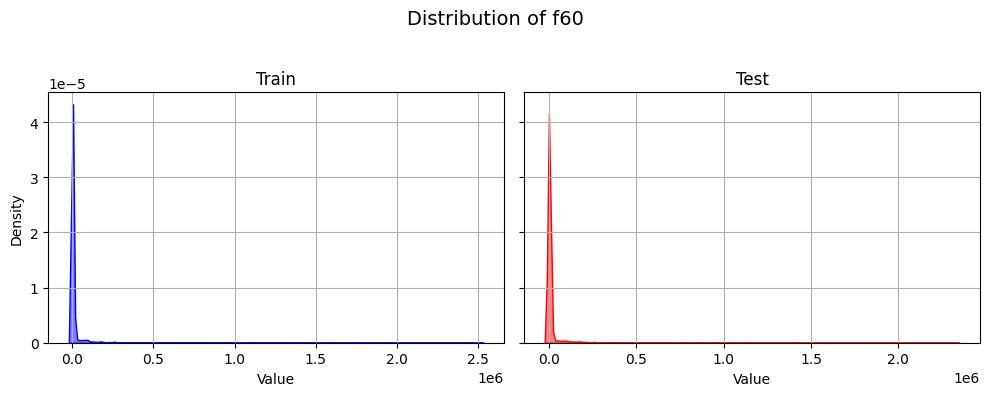

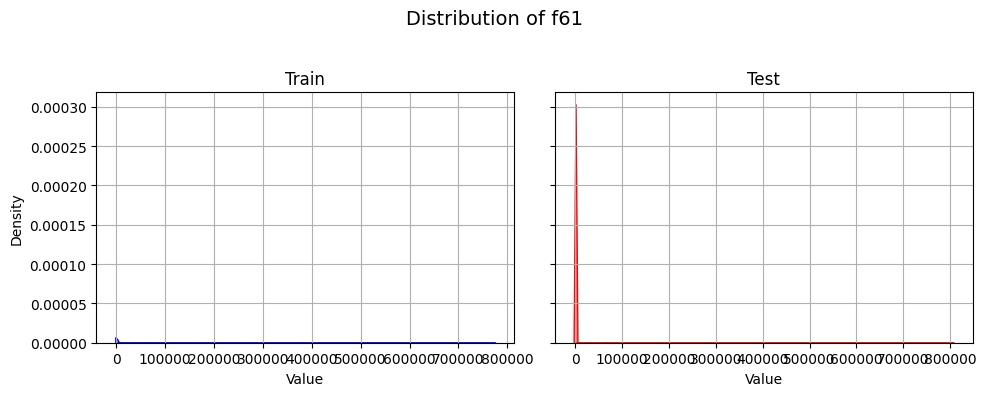

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\281831666.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(train_col.dropna(), fill=True, ax=axs[0], color='blue', alpha=0.5)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\281831666.py:27: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(test_col.dropna(), fill=True, ax=axs[1], color='red', alpha=0.5)


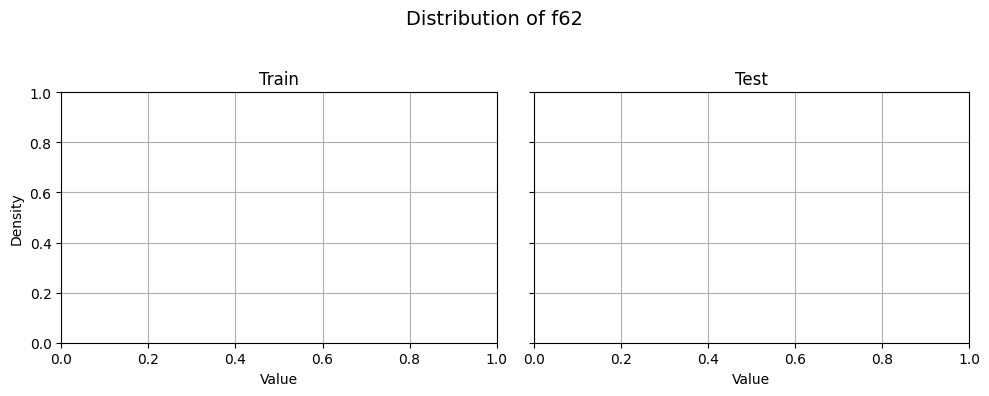

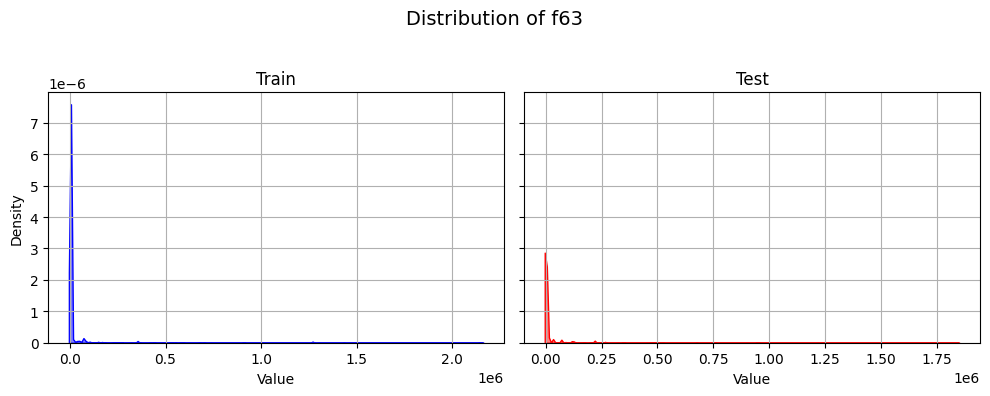

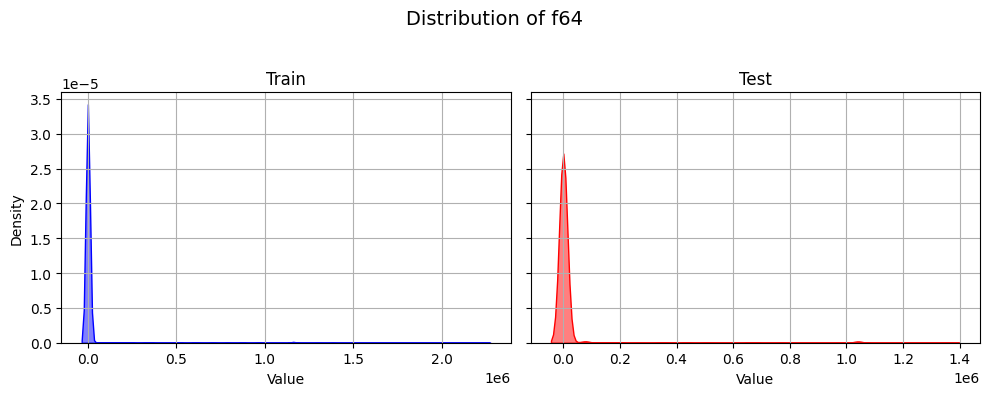

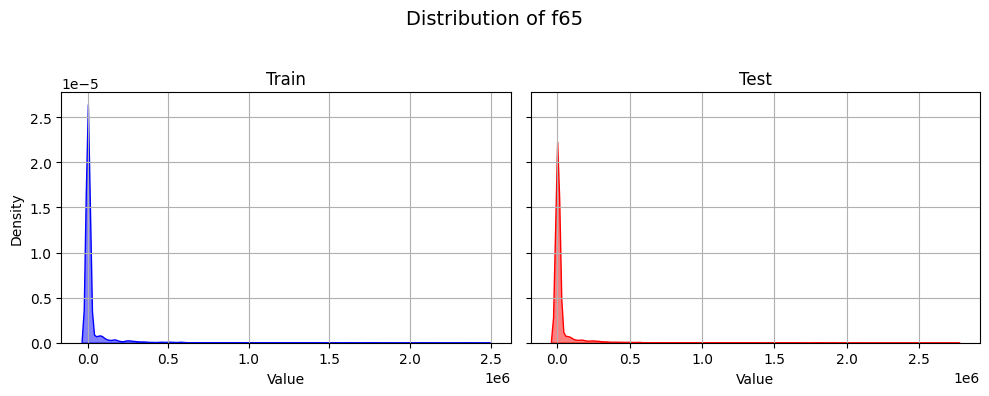

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\281831666.py:20: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(train_col.dropna(), fill=True, ax=axs[0], color='blue', alpha=0.5)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\281831666.py:27: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(test_col.dropna(), fill=True, ax=axs[1], color='red', alpha=0.5)


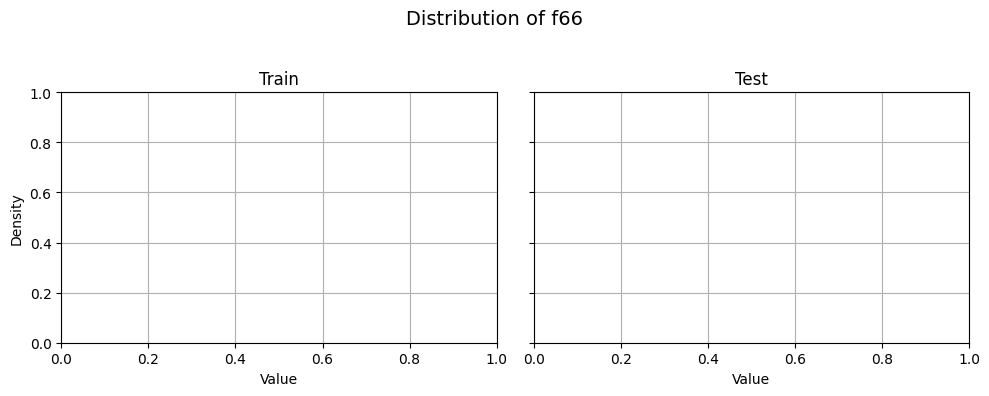

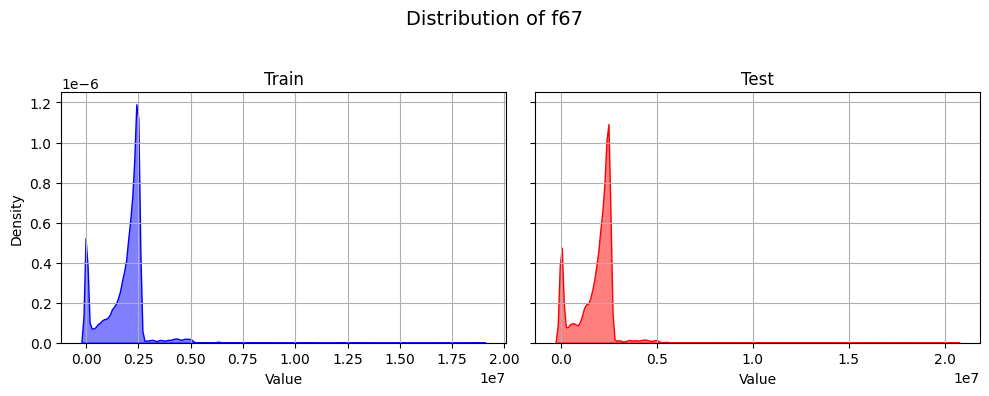

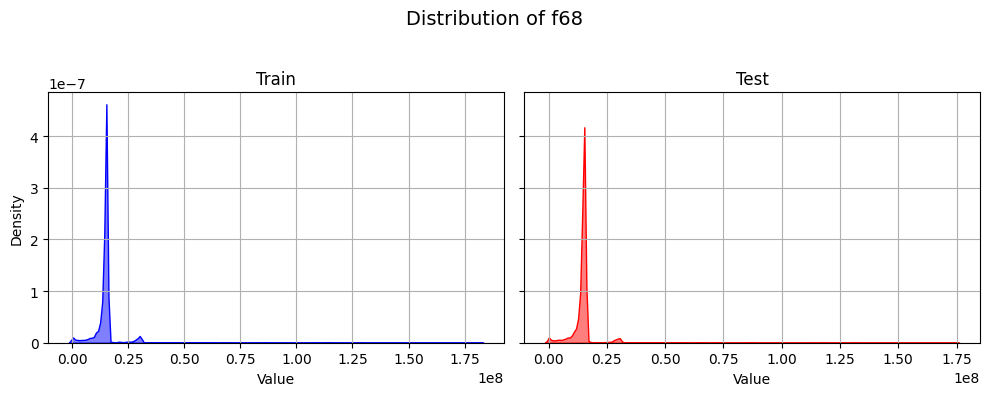

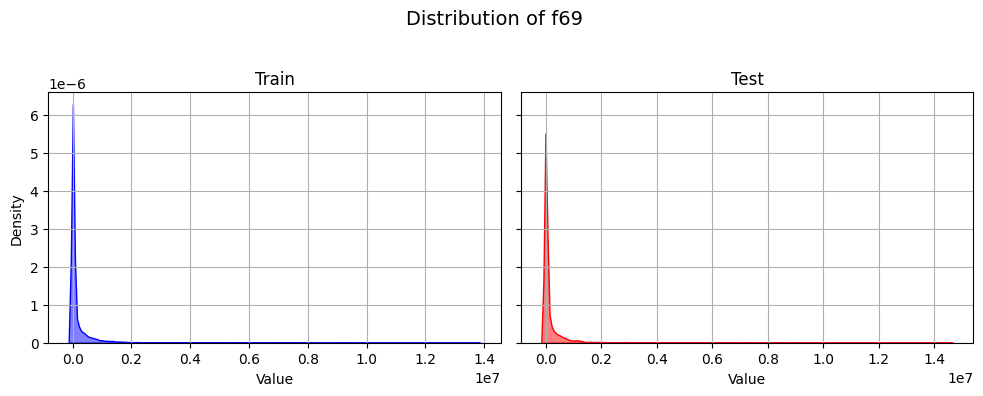

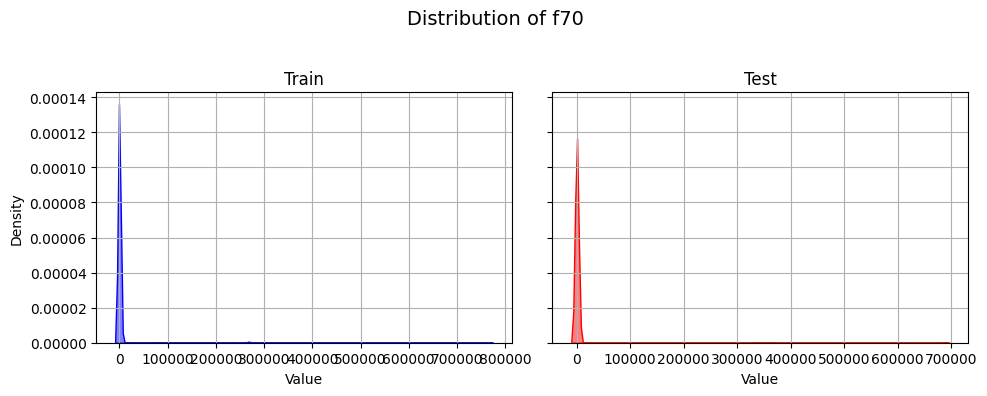

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2104\281831666.py:27: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(test_col.dropna(), fill=True, ax=axs[1], color='red', alpha=0.5)


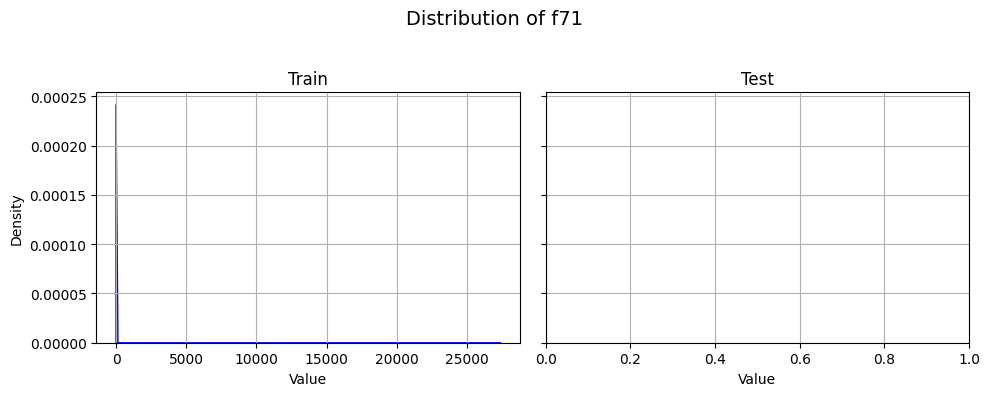

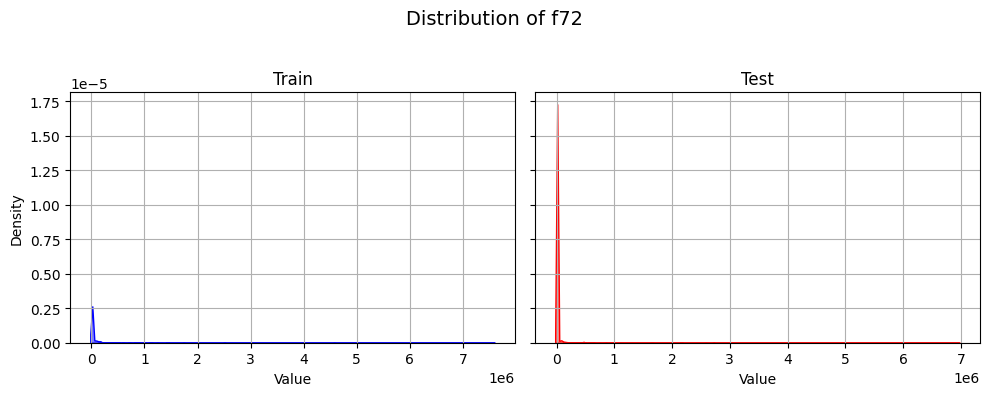

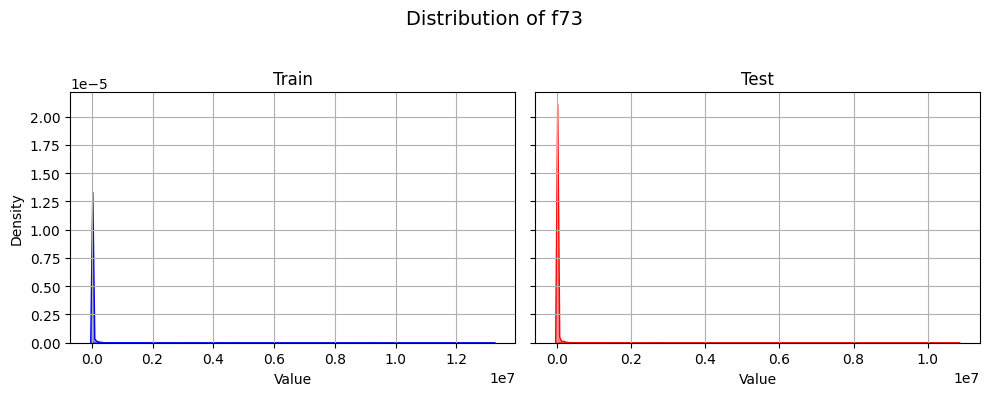

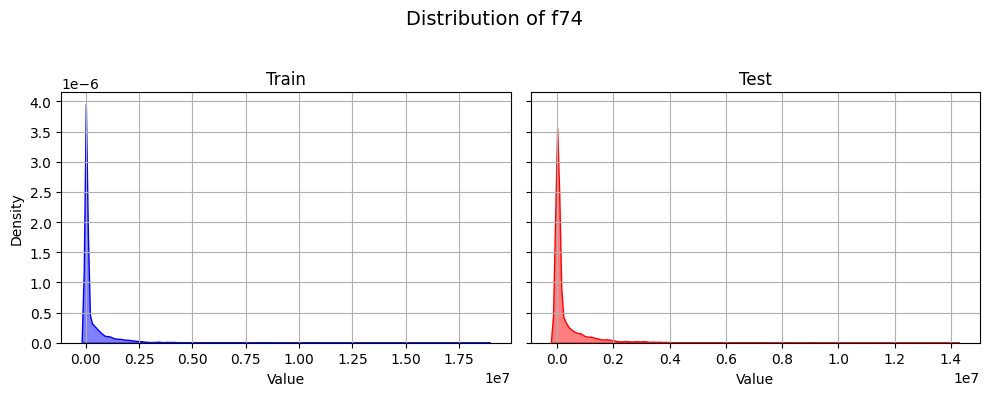

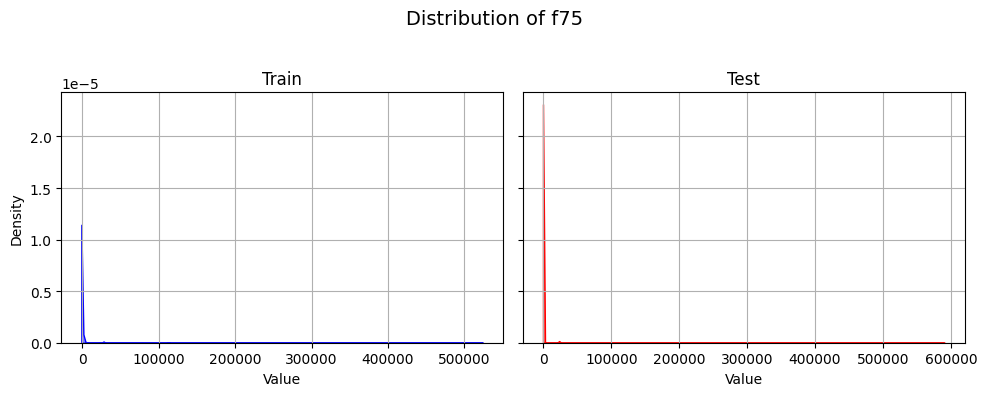

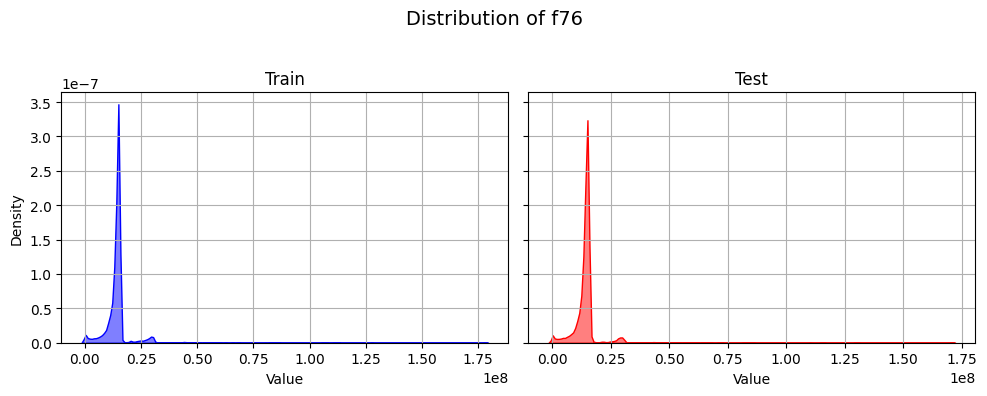

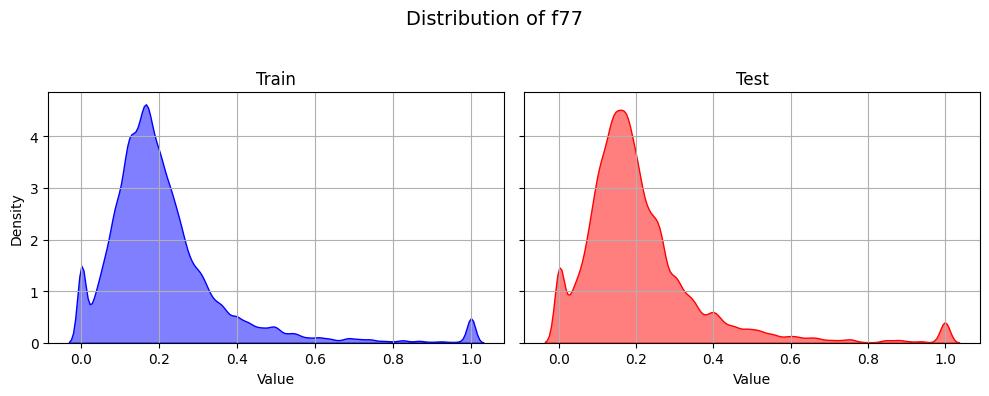

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Features: time spent & page ratios
time_features = [
    'f59', 'f60', 'f61', 'f62', 'f63', 'f64', 'f65', 'f66', 'f67',
    'f68', 'f69', 'f70', 'f71', 'f72', 'f73', 'f74', 'f75', 'f76', 'f77'
]

# Plot side-by-side KDE plots
for feature in time_features:
    train_col = pd.to_numeric(train[feature], errors='coerce')
    test_col = pd.to_numeric(test[feature], errors='coerce')

    fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    fig.suptitle(f'Distribution of {feature}', fontsize=14)

    # Train plot
    sns.kdeplot(train_col.dropna(), fill=True, ax=axs[0], color='blue', alpha=0.5)
    axs[0].set_title("Train")
    axs[0].set_xlabel("Value")
    axs[0].set_ylabel("Density")
    axs[0].grid(True)

    # Test plot
    sns.kdeplot(test_col.dropna(), fill=True, ax=axs[1], color='red', alpha=0.5)
    axs[1].set_title("Test")
    axs[1].set_xlabel("Value")
    axs[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


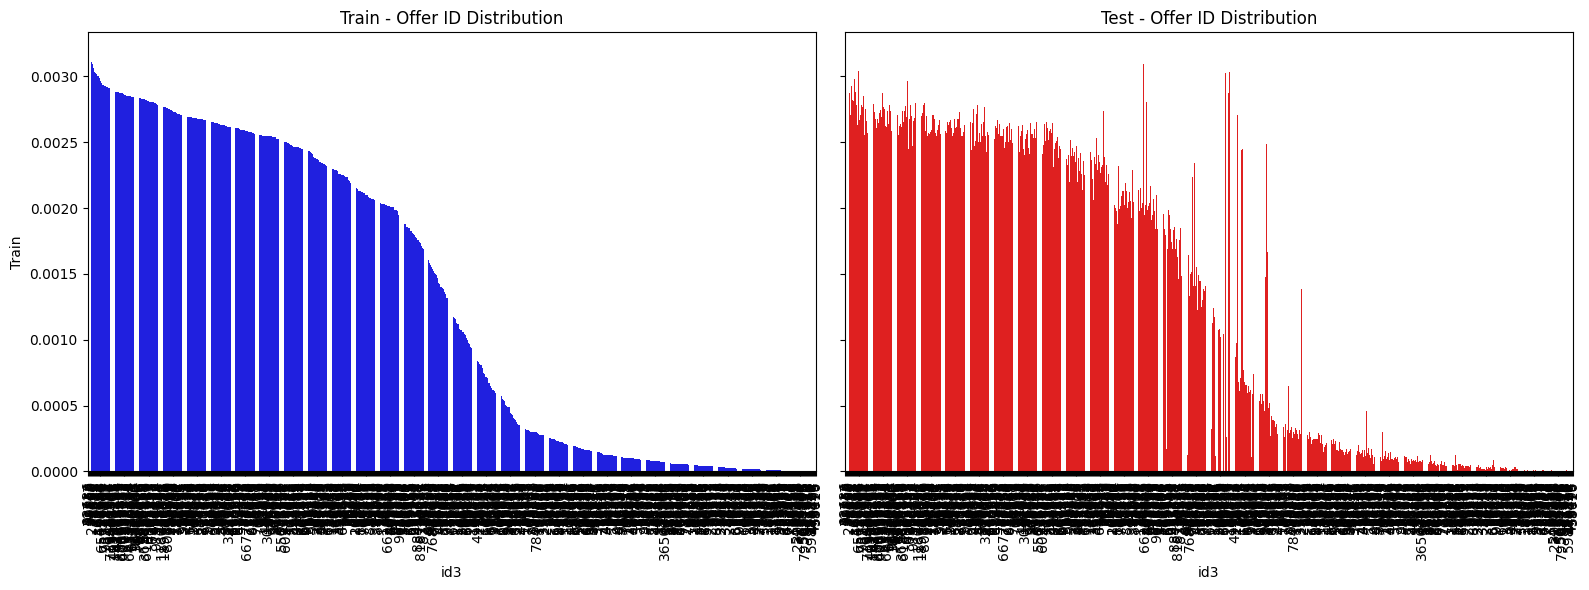

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure id3 is string
train['id3'] = train['id3'].astype(str)
test['id3'] = test['id3'].astype(str)

# Compute normalized value counts (proportions)
train_counts = train['id3'].value_counts(normalize=True).rename('Train')
test_counts = test['id3'].value_counts(normalize=True).rename('Test')

# Combine into one DataFrame
plot_df = pd.concat([train_counts, test_counts], axis=1).fillna(0).reset_index()
plot_df.columns = ['id3', 'Train', 'Test']  # Rename columns correctly

# Sort by Train or Test frequency if needed
plot_df = plot_df.sort_values('Train', ascending=False)

# Plot side-by-side
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.barplot(data=plot_df, x='id3', y='Train', ax=axs[0], color='blue')
axs[0].set_title('Train - Offer ID Distribution')
axs[0].tick_params(axis='x', rotation=90)

sns.barplot(data=plot_df, x='id3', y='Test', ax=axs[1], color='red')
axs[1].set_title('Test - Offer ID Distribution')
axs[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


In [8]:
offers_df = pd.read_parquet(r"D:\Amex Hackathon\offer_metadata.parquet")

In [9]:
offers_df.head()

,id3,id9,f375,f376,f377,id10,id11,f378,f374,id8,id12,id13
0,70687,FO5O,2,5.0,None,1,None,N,None,None,2018-01-01 00:00:00,2099-12-31 23:59:59
1,900002526,UGE,2,100.0,None,1,None,N,None,None,2014-10-20 00:00:00,2099-12-31 23:59:59
2,900002864,UTP,1,100.0,None,1,None,N,None,None,2016-07-19 00:00:00,2099-12-31 23:59:59
3,19508,o,2,NaN,None,1,None,N,None,None,2019-06-02 17:00:00,2028-12-31 16:59:59
4,35903,o,2,NaN,None,1,None,N,None,None,2019-06-02 17:00:00,2028-12-31 16:59:59


In [28]:
events_df = pd.read_parquet(r"D:\Amex Hackathon\add_event.parquet")

In [23]:
trans_df = pd.read_parquet(r"D:\Amex Hackathon\add_trans.parquet")

In [25]:
trans_df['f368'].value_counts()

f368
PR     2637197
PGC    1474203
PBR     946034
OGC     330832
PGR     327828
PPC     319781
OBR     207809
PBC      30396
OGR      28911
OBC      16893
SB       13396
OPR       5964
C          221
Name: count, dtype: int64

In [28]:
# Ensure both columns are datetime
train_df['id4'] = pd.to_datetime(train_df['id4'])
events_df['id4'] = pd.to_datetime(events_df['id4'])

# Now do the merge
merged_check = train_df[['id3', 'id4']].merge(
    events_df[['id3', 'id4']], on=['id3', 'id4'], how='left', indicator=True
)

# Add boolean column indicating whether the row exists in events_df
train_df['exists_in_events'] = merged_check['_merge'] == 'both'


In [29]:
train_df['exists_in_events'].value_counts()

exists_in_events
True     584879
False     31252
Name: count, dtype: int64

In [11]:
test_df = pd.read_parquet(r"D:\Amex Hackathon\test_data.parquet")

In [48]:
# Ensure both columns are datetime
test_df['id4'] = pd.to_datetime(train_df['id4'])
events_df['id4'] = pd.to_datetime(events_df['id4'])

# Now do the merge
merged_check = test_df[['id3', 'id4']].merge(
    events_df[['id3', 'id4']], on=['id3', 'id4'], how='left', indicator=True
)

# Add boolean column indicating whether the row exists in events_df
test_df['exists_in_events'] = merged_check['_merge'] == 'both'

In [5]:
import numpy as np

# Define columns
category_cols = [f"f{i}" for i in range(226, 233)]
subcategory_cols = [f"f{i}" for i in range(233, 310)]

# Fill NaNs with -1 before argmax
cat_array = train_df[category_cols].fillna(-1).values
subcat_array = train_df[subcategory_cols].fillna(-1).values

# Find index of max
active_cat_idx = cat_array.argmax(axis=1)
active_subcat_idx = subcat_array.argmax(axis=1)

# Convert index back to column names
train_df['category'] = np.array(category_cols)[active_cat_idx]
train_df['sub_category'] = np.array(subcategory_cols)[active_subcat_idx]

# Assign grouped ID
pairs = train_df[['category', 'sub_category']].astype(str)
pairs_str = pairs['category'] + '__' + pairs['sub_category']
train_df['grouped_id3'] = pd.factorize(pairs_str)[0] + 1


In [13]:
import numpy as np
import pandas as pd

# Define the columns again (same as in train_df)
category_cols = [f"f{i}" for i in range(226, 233)]
subcategory_cols = [f"f{i}" for i in range(233, 310)]

# Step 1: Replace NaNs with -1
cat_array_test = test_df[category_cols].fillna(-1).values
subcat_array_test = test_df[subcategory_cols].fillna(-1).values

# Step 2: Get the index of the active category and sub-category
active_cat_idx_test = cat_array_test.argmax(axis=1)
active_subcat_idx_test = subcat_array_test.argmax(axis=1)

# Step 3: Convert to actual column names
test_df['category'] = np.array(category_cols)[active_cat_idx_test]
test_df['sub_category'] = np.array(subcategory_cols)[active_subcat_idx_test]

# Step 4: Create grouped_id3 using the same logic (you can re-use or re-factor this logic as a function if needed)
pairs_test = test_df[['category', 'sub_category']].astype(str)
pairs_str_test = pairs_test['category'] + '__' + pairs_test['sub_category']
test_df['grouped_id3'] = pd.factorize(pairs_str_test)[0] + 1

In [15]:
test_df['grouped_id3'].nunique()

50

In [16]:
# Already created in train_df:
pairs_train = train_df[['category', 'sub_category']].astype(str)
pairs_str_train = pairs_train['category'] + '__' + pairs_train['sub_category']

# Build mapping from (category, sub_category) string → grouped_id3
unique_pairs = pairs_str_train.unique()
pair_to_id_map = {pair: i + 1 for i, pair in enumerate(unique_pairs)}

# Assign in train_df
train_df['grouped_id3'] = pairs_str_train.map(pair_to_id_map)


In [17]:
# Apply same process to test_df
pairs_test = test_df[['category', 'sub_category']].astype(str)
pairs_str_test = pairs_test['category'] + '__' + pairs_test['sub_category']

# Use the train mapping, unknown combinations get NaN or a default value
test_df['grouped_id3'] = pairs_str_test.map(pair_to_id_map).fillna(0).astype(int)


In [24]:
train_df['f349'].value_counts()

f349
4    301584
5    246700
6    221741
3       139
Name: count, dtype: int64

In [25]:
train_df.loc[train_df['f349'] == 6, 'id4'].sort_values()


Series([], Name: id4, dtype: object)

In [26]:
# Recompute f349 yourself from id4
train_df['computed_f349'] = pd.to_datetime(train_df['id4']).dt.dayofweek + 1  # Monday=1, Sunday=7
train_df[['id4', 'f349', 'computed_f349']].sample(10)


,id4,f349,computed_f349
428365,2023-11-02 05:52:55.890,5,4
626416,2023-11-02 10:11:08.721,5,4
395134,2023-11-03 10:33:13.883,6,5
768811,2023-11-02 11:30:18.821,5,4
725748,2023-11-02 10:05:48.482,5,4
478089,2023-11-02 10:36:35.181,5,4
214517,2023-11-02 22:51:41.686,5,4
255973,2023-11-02 11:39:47.840,5,4
295403,2023-11-02 07:31:41.000518,5,4
526288,2023-11-02 07:42:25.316,5,4


In [38]:
train_df["computed_f349"] = ((pd.to_datetime(train_df["id4"]).dt.dayofweek + 1) % 7) + 1


In [47]:
test_df["computed_f349"] = ((pd.to_datetime(test_df["id4"]).dt.dayofweek + 1) % 7) + 1


In [113]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(train_df[['f350']], train_df['y'], discrete_features=False)
print(f"📈 Mutual Information (f350 vs y): {mi[0]:.4f}")


📈 Mutual Information (f350 vs y): 0.0976


In [115]:
train_df["f349"] = pd.to_numeric(train_df["f349"], errors="coerce")
test_df["f349"] = pd.to_numeric(test_df["f349"], errors="coerce")

In [116]:
import numpy as np

train_df["day_sin"] = np.sin(2 * np.pi * train_df["f349"] / 7)
train_df["day_cos"] = np.cos(2 * np.pi * train_df["f349"] / 7)

test_df["day_sin"] = np.sin(2 * np.pi * test_df["f349"] / 7)
test_df["day_cos"] = np.cos(2 * np.pi * test_df["f349"] / 7)


In [117]:
from scipy.stats import ks_2samp

def check_ks_drift(train_col, test_col, feature_name):
    ks_stat, p_value = ks_2samp(train_col, test_col)
    print(f"📊 KS Statistic for {feature_name}: {ks_stat:.4f}")
    print(f"📉 p-value: {p_value:.4e}")
    if p_value < 0.05:
        print(f"🚨 Significant Drift Detected in '{feature_name}'\n")
    else:
        print(f"✅ No Significant Drift Detected in '{feature_name}'\n")

# Apply to both new features
check_ks_drift(train_df["day_sin"], test_df["day_sin"], "day_sin")
check_ks_drift(train_df["day_cos"], test_df["day_cos"], "day_cos")


📊 KS Statistic for day_sin: 0.9996
📉 p-value: 0.0000e+00
🚨 Significant Drift Detected in 'day_sin'

📊 KS Statistic for day_cos: 0.9998
📉 p-value: 0.0000e+00
🚨 Significant Drift Detected in 'day_cos'



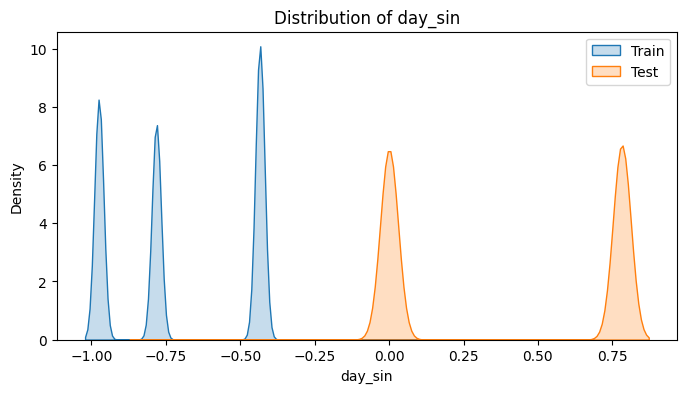

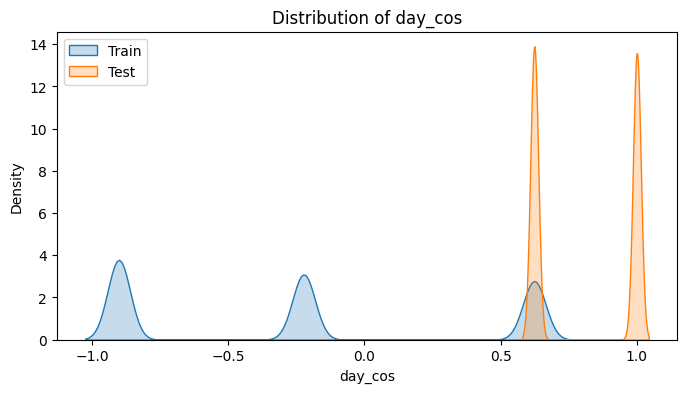

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distribution(train_col, test_col, feature_name):
    plt.figure(figsize=(8, 4))
    sns.kdeplot(train_col, label='Train', fill=True)
    sns.kdeplot(test_col, label='Test', fill=True)
    plt.title(f"Distribution of {feature_name}")
    plt.legend()
    plt.show()

plot_distribution(train_df["day_sin"], test_df["day_sin"], "day_sin")
plot_distribution(train_df["day_cos"], test_df["day_cos"], "day_cos")


In [121]:
offers_df = pd.read_parquet("D:\Amex Hackathon\offer_metadata.parquet")

In [124]:
offers_df['id8'].value_counts()

id8
58120000    574
56510500    208
54110000    134
70110000    126
59630000    114
           ... 
59419902      1
57190104      1
75490000      1
58120501      1
42130206      1
Name: count, Length: 300, dtype: int64

In [125]:
import pandas as pd

# Ensure 'id2' is a numeric type in both DataFrames.
# This is the most important step.
train_df['id2'] = pd.to_numeric(train_df['id2'], errors='coerce')
events_df['id2'] = pd.to_numeric(events_df['id2'], errors='coerce')

# Drop any rows where the ID might have become null after conversion
train_df.dropna(subset=['id2'], inplace=True)
events_df.dropna(subset=['id2'], inplace=True)

# Create sets of the unique user IDs from each DataFrame
train_users = set(train_df['id2'].unique())
events_users = set(events_df['id2'].unique())

# Find the intersection of the two sets
common_users = train_users.intersection(events_users)

# --- Print the results ---
print(f"Number of unique users in train_df: {len(train_users)}")
print(f"Number of unique users in events_df: {len(events_users)}")
print(f"Number of common users found: {len(common_users)}")

if len(common_users) == len(train_users):
    print("\n✅ Success! All users from your training set are present in the events log.")
else:
    print("\n⚠️ There is an issue. Not all training users were found in the events log.")

Number of unique users in train_df: 46550
Number of unique users in events_df: 428195
Number of common users found: 0

⚠️ There is an issue. Not all training users were found in the events log.


In [126]:
import pandas as pd

print("--- Creating Historical Features Within train_df ---")

# Step 1: Ensure the dataframe is sorted by user and time
# This is the most critical step for a correct historical calculation.
train_df.sort_values(by=['id2', 'id4'], inplace=True)

# Step 2: Calculate cumulative impressions and clicks for each user
# 'is_impression' is 1 for every row
train_df['is_impression'] = 1
# 'is_click' is the target variable 'y'
train_df['is_click'] = train_df['y']

# Use cumsum() to get a running total of impressions and clicks for each user
cumulative_impressions = train_df.groupby('id2')['is_impression'].cumsum()
cumulative_clicks = train_df.groupby('id2')['is_click'].cumsum()

# Step 3: Shift the results to prevent data leakage
# We use shift(1) to get the history *before* the current event.
train_df['user_hist_impressions'] = train_df.groupby('id2')['is_impression'].shift(1).fillna(0)
train_df['user_hist_clicks'] = train_df.groupby('id2')['is_click'].shift(1).fillna(0)

# Step 4: Calculate the user's historical CTR
# Add 1 to the denominator for smoothing to avoid division by zero
train_df['user_hist_ctr'] = train_df['user_hist_clicks'] / (train_df['user_hist_impressions'] + 1)

# Step 5: Clean up temporary columns
train_df.drop(columns=['is_impression', 'is_click'], inplace=True)

print("\n✅ User historical features created successfully within train_df.")
print(train_df[['id2', 'id4', 'y', 'user_hist_impressions', 'user_hist_clicks', 'user_hist_ctr']].head())

--- Creating Historical Features Within train_df ---

✅ User historical features created successfully within train_df.
            id2                     id4  y  user_hist_impressions  \
575716  1000043 2023-11-03 13:59:42.346  0                    0.0   
575715  1000043 2023-11-03 13:59:42.714  0                    1.0   
323212  1000078 2023-11-02 03:40:44.605  0                    0.0   
258665  1000099 2023-11-03 08:48:05.823  0                    0.0   
65052   1000101 2023-11-02 12:54:11.194  0                    0.0   

        user_hist_clicks  user_hist_ctr  
575716               0.0            0.0  
575715               0.0            0.0  
323212               0.0            0.0  
258665               0.0            0.0  
65052                0.0            0.0  


In [130]:
!pip install sentence_transformers

   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ------ --------------------------------- 1.8/10.8 MB 9.1 MB/s eta 0:00:01
   ------------- -------------------------- 3.7/10.8 MB 9.5 MB/s eta 0:00:01
   --------------------- ------------------ 5.8/10.8 MB 9.5 MB/s eta 0:00:01
   ----------------------------- ---------- 7.9/10.8 MB 9.5 MB/s eta 0:00:01
   ------------------------------------ --- 10.0/10.8 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 10.8/10.8 MB 9.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   --------------------------------- ------ 2.1/2.5 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 10.3 MB/s eta 0:00:00

   ------ --------------------------------- 1/6 [regex]
   ------ --------------------------------- 1/6 [regex]
   ------------- -------------------------- 2/6 [huggingface-hub]
   ------------- -------------------------- 2/6 [huggingface-hub

In [131]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
import torch

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Get unique cm_industry_description from offers_df
offers_df['f374'] = offers_df['f374'].fillna("unknown")
offers_df['f374_emb'] = model.encode(offers_df['f374'].tolist(), show_progress_bar=True).tolist()


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/131 [00:00<?, ?it/s]

In [133]:
# Ensure id3 is of the same type in both DataFrames
train_df['id3'] = train_df['id3'].astype(str)
offers_df['id3'] = offers_df['id3'].astype(str)

# Now merge
train_df = train_df.merge(offers_df[['id3', 'f374_emb']], on='id3', how='left')


In [ ]:
# Create offer embedding DataFrame
offer_embeddings_df = offers_df[['id3', 'f374_emb']].copy()

# Merge into train_df
train_df = train_df.merge(offer_embeddings_df, on='id3', how='left')


In [135]:
# Store clicked offer embeddings with timestamps
clicked_df = train_df[train_df['y'] == 1].copy()
clicked_df['past_emb'] = clicked_df['f374_emb']

# Remove unnecessary columns
clicked_df = clicked_df[['id2', 'id4', 'past_emb']]

In [138]:
from sklearn.metrics.pairwise import cosine_similarity

def get_user_past_clicks(user_id, current_time):
    past = clicked_df[(clicked_df['id2'] == user_id) & (clicked_df['id4'] < current_time)]
    past = past.sort_values('id4', ascending=False).head(4)
    return past['past_emb'].tolist()

def compute_avg_similarity(current_emb, past_embs):
    if not past_embs:
        return np.nan
    sims = cosine_similarity([current_emb], past_embs)[0]
    return float(np.mean(sims))

# Apply to each row
similarity_scores = []
for _, row in train_df.iterrows():
    user = row['id2']
    timestamp = row['id4']
    current_emb = row['f374_emb']
    
    if not isinstance(current_emb, (list, np.ndarray)):
        similarity_scores.append(np.nan)
        continue
    
    past_embs = get_user_past_clicks(user, timestamp)
    # Filter out any NaN past embeddings
    past_embs = [emb for emb in past_embs if isinstance(emb, (list, np.ndarray))]

    sim = compute_avg_similarity(current_emb, past_embs)
    similarity_scores.append(sim)


train_df['f374_sim_with_recent_clicks'] = similarity_scores

In [ ]:
train_df['f374_sim_with_recent_clicks']  # float between 0 and 1 or NaN if no history

In [119]:
import pandas as pd

# Ensure timestamps are in datetime format
events_df['id4'] = pd.to_datetime(events_df['id4'])  # Impression timestamp
events_df['id7'] = pd.to_datetime(events_df['id7'])  # Click timestamp

# Create a binary click flag
events_df['clicked'] = events_df['id7'].notna().astype(int)

# Extract day of the week: Monday=0, Sunday=6
events_df['day_of_week'] = events_df['id4'].dt.dayofweek

# Weekday = Mon–Fri (0–4), Weekend = Sat–Sun (5–6)
events_df['is_weekend'] = events_df['day_of_week'].apply(lambda x: 'weekend' if x >= 5 else 'weekday')

# Compute CTRs
ctr_df = events_df.groupby(['id3', 'is_weekend']).agg(
    impressions=('id4', 'count'),
    clicks=('clicked', 'sum')
).reset_index()

ctr_df['ctr'] = ctr_df['clicks'] / ctr_df['impressions']

# Pivot to get separate columns for weekdays and weekends
ctr_pivot = ctr_df.pivot(index='id3', columns='is_weekend', values='ctr').reset_index()
ctr_pivot.columns.name = None  # remove index name
ctr_pivot = ctr_pivot.rename(columns={
    'id3': 'offer_id',
    'weekday': 'historical_ctr_weekdays',
    'weekend': 'historical_ctr_weekends'
})

# Fill NaN with 0 if any offer_id had no impressions during weekends or weekdays
ctr_pivot.fillna(0, inplace=True)

# Preview
ctr_pivot.head()


,offer_id,historical_ctr_weekdays,historical_ctr_weekends
0,10139,0.156364,0.065574
1,101460,0.062176,0.059896
2,10242,0.006280,0.007429
3,104246,0.041958,0.000000
4,106207,0.015299,0.012048


In [51]:
# Ensure both columns are of the same type (int)
train_df['f349'] = train_df['f349'].astype(int)
train_df['computed_f349'] = train_df['computed_f349'].astype(int)

# Filter rows where they differ
mismatch_df = train_df[train_df['f349'] != train_df['computed_f349']]

# Display mismatched rows
print(f"Total mismatches: {len(mismatch_df)}")
display(mismatch_df)


Total mismatches: 268


,id1,id2,id3,id4,id5,y,f1,f2,f3,f4,...,f361,f362,f363,f364,f365,f366,category,sub_category,grouped_id3,computed_f349
30490,1111176_56483_16-23_2023-11-01 00:01:55.315,1111176,56483,2023-11-01 00:01:55.315,2023-11-01,0,None,None,None,None,...,377.0,39.0,0.1034482758620689,809.0,93.0,0.1149567367119901,f231,f252,4,4
30491,1111176_285330_16-23_2023-11-01 00:01:34.591,1111176,285330,2023-11-01 00:01:34.591,2023-11-01,0,None,None,None,None,...,22.0,3.0,0.1363636363636363,323.0,30.0,0.0928792569659442,f230,f233,25,4
30492,1111176_475056_16-23_2023-11-01 00:00:24.528,1111176,475056,2023-11-01 00:00:24.528,2023-11-01,0,None,None,None,None,...,377.0,39.0,0.1034482758620689,809.0,93.0,0.1149567367119901,f231,f252,4,4
30493,1111176_313795_16-23_2023-11-01 00:01:34.477,1111176,313795,2023-11-01 00:01:34.477,2023-11-01,0,None,None,None,None,...,199.0,16.0,0.0804020100502512,363.0,30.0,0.0826446280991735,f232,f276,3,4
30494,1111176_80076_16-23_2023-11-01 00:01:34.489,1111176,80076,2023-11-01 00:01:34.489,2023-11-01,0,None,None,None,None,...,66.0,4.0,0.0606060606060606,1629.0,204.0,0.1252302025782689,f231,f274,31,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504773,1023785_61621_16-23_2023-11-01 00:04:21.126,1023785,61621,2023-11-01 00:04:21.126,2023-11-01,0,None,None,None,None,...,83.0,0.0,0.0,320.0,0.0,0.0,f231,f285,1,4
504781,1023785_30424_16-23_2023-11-01 00:04:43.631,1023785,30424,2023-11-01 00:04:43.631,2023-11-01,0,None,None,None,None,...,None,None,None,548.0,3.0,0.0054744525547445,f228,f285,9,4
504794,1023785_920925_16-23_2023-11-01 00:04:11.948,1023785,920925,2023-11-01 00:04:11.948,2023-11-01,0,None,None,None,None,...,7.0,0.0,0.0,548.0,3.0,0.0054744525547445,f232,f285,17,4
504796,1023785_59888828_16-23_2023-11-01 00:04:21.234,1023785,59888828,2023-11-01 00:04:21.234,2023-11-01,0,None,None,None,None,...,83.0,0.0,0.0,320.0,0.0,0.0,f231,f285,1,4


In [52]:
mismatch_df['computed_f349'].value_counts()

computed_f349
4    139
6    104
5     25
Name: count, dtype: int64

In [82]:
train_df['f352'].value_counts()

f352
3.0                   53440
1.0350841819432672    36402
1.0689391057472464    33752
1.6487212707001282    25441
1.039210757944791     16404
                      ...  
1.0011940297089694        2
1.0066889383540194        1
1.0035026233955249        1
1.0011191940634308        1
1.0014587889464486        1
Name: count, Length: 200, dtype: int64

In [83]:
import pandas as pd
from scipy.stats import ks_2samp, chi2_contingency

def check_data_drift(train_df, test_df, feature_list):
    """
    Checks for data drift between training and testing sets for a list of features.
    
    Args:
    - train_df (pd.DataFrame): The training dataframe.
    - test_df (pd.DataFrame): The testing dataframe.
    - feature_list (list): A list of column names to check for drift.
    
    Returns:
    - pd.DataFrame: A summary of the drift analysis for each feature.
    """
    drift_report = []
    
    for feature in feature_list:
        # Isolate the series for the current feature
        train_series = train_df[feature].dropna()
        test_series = test_df[feature].dropna()
        
        # Check if the feature is numeric or categorical
        if pd.api.types.is_numeric_dtype(train_series):
            # --- NUMERICAL FEATURE ---
            # Perform the KS Test
            ks_stat, p_value = ks_2samp(train_series, test_series)
            
            drift_report.append({
                'Feature': feature,
                'DataType': 'Numerical',
                'Test': 'KS Test',
                'Statistic': f"{ks_stat:.4f}",
                'P-Value': p_value
            })
        
        else:
            # --- CATEGORICAL FEATURE ---
            # Create a contingency table
            contingency_table = pd.crosstab(
                pd.concat([train_series, test_series]),
                ['Train'] * len(train_series) + ['Test'] * len(test_series)
            )
            
            # Perform the Chi-Squared Test
            try:
                chi2_stat, p_value, _, _ = chi2_contingency(contingency_table)
                drift_report.append({
                    'Feature': feature,
                    'DataType': 'Categorical',
                    'Test': 'Chi-Squared',
                    'Statistic': f"{chi2_stat:.4f}",
                    'P-Value': p_value
                })
            except ValueError:
                # This can happen if a category exists in one set but not the other
                drift_report.append({
                    'Feature': feature,
                    'DataType': 'Categorical',
                    'Test': 'Chi-Squared',
                    'Statistic': 'Error',
                    'P-Value': 0.0 # Treat as drifted if there's a value error
                })

    # --- Generate the final report ---
    report_df = pd.DataFrame(drift_report)
    
    # Add a drift status based on the p-value
    report_df['Drift Status'] = report_df['P-Value'].apply(lambda p: 'Drift Detected' if p < 0.05 else 'Stable')
    
    return report_df.sort_values(by='P-Value', ascending=True)

# --- HOW TO USE ---
# 1. Define the list of features you want to check
features_to_check = ['f352', 'f353'] # Add any other feature names here

# 2. Run the drift check
drift_results = check_data_drift(train_df, test_df, features_to_check)

# 3. Display the results
print("--- Data Drift Report ---")
print(drift_results)

--- Data Drift Report ---
  Feature     DataType         Test    Statistic  P-Value    Drift Status
0    f352  Categorical  Chi-Squared  351020.9019      0.0  Drift Detected
1    f353  Categorical  Chi-Squared  215755.3872      0.0  Drift Detected


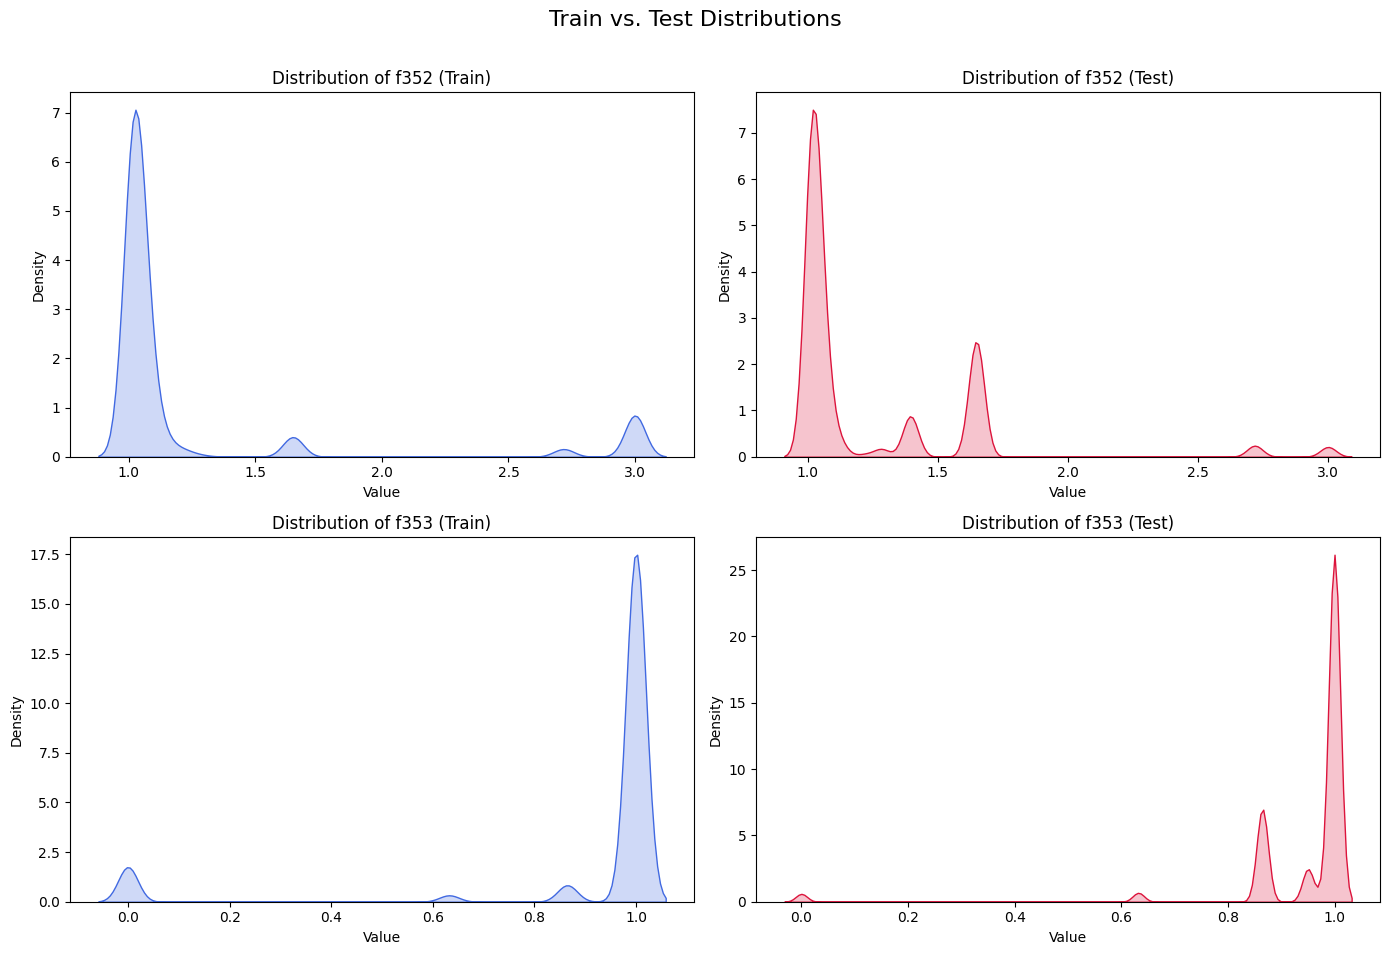

In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume train_df and test_df are your loaded DataFrames

# --- Plotting Code ---

# List of features you want to plot
features_to_plot = ['f352', 'f353']

# Set up the matplotlib figure
fig, axes = plt.subplots(nrows=len(features_to_plot), ncols=2, figsize=(14, 10))
fig.suptitle('Train vs. Test Distributions', fontsize=16)

for i, feature in enumerate(features_to_plot):
    # --- THIS IS THE FIX ---
    # Convert the feature to a numeric type, coercing errors to NaN
    train_numeric = pd.to_numeric(train_df[feature], errors='coerce')
    test_numeric = pd.to_numeric(test_df[feature], errors='coerce')
    # --- END OF FIX ---

    # Plot for the Training Set, dropping any NaNs from the conversion
    sns.kdeplot(data=train_numeric.dropna(), ax=axes[i, 0], fill=True, color='royalblue')
    axes[i, 0].set_title(f'Distribution of {feature} (Train)')
    axes[i, 0].set_xlabel('Value')
    axes[i, 0].set_ylabel('Density')
    
    # Plot for the Test Set, dropping any NaNs from the conversion
    sns.kdeplot(data=test_numeric.dropna(), ax=axes[i, 1], fill=True, color='crimson')
    axes[i, 1].set_title(f'Distribution of {feature} (Test)')
    axes[i, 1].set_xlabel('Value')
    axes[i, 1].set_ylabel('Density')

# Adjust layout to prevent titles from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [101]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

def ks_test(train_series, test_series):
    # Drop missing values and convert to numeric
    train_series = pd.to_numeric(train_series.dropna(), errors='coerce').dropna()
    test_series = pd.to_numeric(test_series.dropna(), errors='coerce').dropna()
    
    if len(train_series) == 0 or len(test_series) == 0:
        return np.nan, np.nan
    
    stat, p_value = ks_2samp(train_series, test_series)
    return stat, p_value

def calculate_psi(expected, actual, buckets=10):
    expected = pd.to_numeric(expected.dropna(), errors='coerce').dropna()
    actual = pd.to_numeric(actual.dropna(), errors='coerce').dropna()

    if len(expected) == 0 or len(actual) == 0:
        return np.nan

    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    expected_ratios = expected_counts / len(expected)
    actual_ratios = actual_counts / len(actual)

    # Avoid division by zero or log of zero
    psi_values = []
    for e, a in zip(expected_ratios, actual_ratios):
        if e == 0 or a == 0:
            psi_values.append(0)
        else:
            psi_values.append((e - a) * np.log(e / a))

    return np.sum(psi_values)

# -------------------------------
# Example usage
# -------------------------------
features = ['f351', 'f352', 'f353']  # your selected features

for feature in features:
    train = train_df[feature]
    test = test_df[feature]

    ks_stat, ks_p = ks_test(train, test)
    psi_val = calculate_psi(train, test)

    print(f"[{feature}]  KS: {ks_stat:.4f} (p={ks_p:.4f}) | PSI: {psi_val:.4f}")


[f351]  KS: 0.1563 (p=0.0000) | PSI: 0.4070
[f352]  KS: 0.1563 (p=0.0000) | PSI: 0.4070
[f353]  KS: 0.1563 (p=0.0000) | PSI: 0.4470


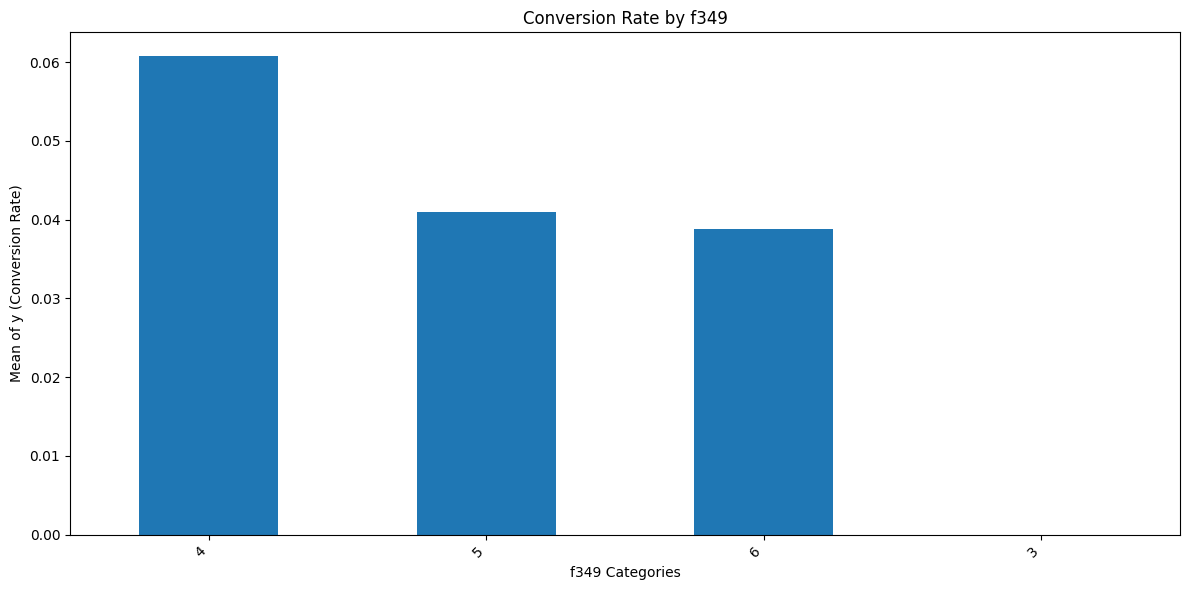

In [111]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'y' is numeric
train_df['y'] = pd.to_numeric(train_df['y'], errors='coerce')

# Optional: drop rows with NaN in y
train_df = train_df.dropna(subset=['y'])

# Group by categorical feature
conversion_by_f349 = train_df.groupby('f349')['y'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
conversion_by_f349.plot(kind='bar')
plt.title("Conversion Rate by f349")
plt.ylabel("Mean of y (Conversion Rate)")
plt.xlabel("f349 Categories")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [105]:
import pandas as pd
from scipy.stats import chi2_contingency

col = 'f349'  # your column

# Convert both to int for consistent indexing
train_counts = train_df[col].astype(int).value_counts().sort_index()
test_counts = test_df[col].astype(int).value_counts().sort_index()

# Align indices manually to avoid sorting issues
all_days = sorted(set(train_counts.index).union(test_counts.index))

train_counts = train_counts.reindex(all_days, fill_value=0)
test_counts = test_counts.reindex(all_days, fill_value=0)

# Build contingency table
contingency = pd.DataFrame({
    'train': train_counts,
    'test': test_counts
})

# Chi-Squared Test
chi2, p, dof, ex = chi2_contingency(contingency.T)

print("📊 Chi-Squared Test for Categorical Drift")
print(f"Chi2 = {chi2:.4f}, p-value = {p:.4f}")
if p < 0.05:
    print("🚨 Significant Drift Detected in 'context_day'")
else:
    print("✅ No Significant Drift in 'context_day'")


📊 Chi-Squared Test for Categorical Drift
Chi2 = 1139113.6190, p-value = 0.0000
🚨 Significant Drift Detected in 'context_day'


In [97]:
import pandas as pd
import numpy as np

print("--- Creating Time-Relative Delta Features for f352 & f353 ---")

# 1. Define the features to transform and the time window
features_to_transform = ['f352', 'f353']
TIME_WINDOW = '7D'  # A 7-day rolling window is a good starting point

# 2. Create a historical log using only training data to prevent leakage
historical_log = train_df[['id4', 'id2'] + features_to_transform].copy()
historical_log.sort_values('id4', inplace=True)

# 3. Calculate the rolling mean for each user
historical_log_indexed = historical_log.set_index('id4')
rolling_mean_stats = historical_log_indexed.groupby('id2')[features_to_transform].rolling(TIME_WINDOW).mean()

# Rename the new columns to be specific, e.g., 'f352_rolling_mean_7D'
rolling_mean_stats.rename(columns=lambda c: f"{c}_rolling_mean_{TIME_WINDOW}", inplace=True)
rolling_mean_stats.reset_index(inplace=True)

# 4. Define a reusable function to apply these features
def add_rolling_deltas(df, stats_lookup, features):
    df_copy = df.copy()

    # Sort both DataFrames
    stats_lookup = stats_lookup.sort_values(['id2', 'id4'])
    df_copy = df_copy.sort_values(['id2', 'id4'])  # ✅ REQUIRED

    # Merge rolling mean stats (shifted to avoid leakage)
    merged = pd.merge_asof(
        left=df_copy,
        right=stats_lookup,
        on='id4',
        by='id2',
        direction='backward'
    )

    # Compute deltas
    for feature in features:
        merged[f'{feature}_delta'] = merged[feature] - merged[f'{feature}_rolling_mean']

    return merged




# 5. Apply the function to both your train and test sets
train_df = add_rolling_deltas(train_df, rolling_mean_stats, features_to_transform)
test_df = add_rolling_deltas(test_df, rolling_mean_stats, features_to_transform)

print("\n✅ Rolling delta features for f352 & f353 created successfully.")
print("You should now use these new features (e.g., 'f352_delta_7D') and drop the originals.")
print(train_df[['id2', 'id4', 'f352', f'f352_delta_{TIME_WINDOW}']].head())

--- Creating Time-Relative Delta Features for f352 & f353 ---


ValueError: left keys must be sorted

In [71]:
df_subset = test_df[test_df['f349']=='7']

In [73]:
df_subset['id5']

46756     2023-11-04
57819     2023-11-04
145730    2023-11-04
77784     2023-11-04
175314    2023-11-04
             ...    
25978     2023-11-04
43129     2023-11-04
28409     2023-11-04
167703    2023-11-04
56842     2023-11-04
Name: id5, Length: 182474, dtype: object

In [79]:
import pandas as pd
from scipy.stats import ks_2samp

# Assume train_df and test_df are your loaded DataFrames

# --- 1. Isolate the feature and ensure a consistent NUMERIC type ---
# The KS test requires numeric data to perform comparisons and sorting.
train_sample = pd.to_numeric(train_df['f349'], errors='coerce').dropna()
test_sample = pd.to_numeric(test_df['f349'], errors='coerce').dropna()

# --- 2. Perform the two-sample KS test ---
ks_statistic, p_value = ks_2samp(train_sample, test_sample)

# --- 3. Display the results ---
print(f"--- KS Test for Feature 'f349' (Train vs. Test) ---")
print(f"KS Statistic: {ks_statistic:.4f}")
print(f"P-value: {p_value}")

print("\n--- Interpretation ---")
# Explain the KS statistic
print(f"The KS Statistic of {ks_statistic:.4f} represents the maximum difference between the two distributions.")
print("A score of 0 indicates identical distributions; 1 indicates completely different distributions.")

# Explain the p-value
if p_value < 0.05:
    print(f"Since the p-value is extremely small, we reject the null hypothesis.")
    print("This statistically confirms that your training and test sets have a different distribution for this feature.")
else:
    print("The p-value is not statistically significant, suggesting the distributions are similar.")

--- KS Test for Feature 'f349' (Train vs. Test) ---
KS Statistic: 0.5057
P-value: 0.0

--- Interpretation ---
The KS Statistic of 0.5057 represents the maximum difference between the two distributions.
A score of 0 indicates identical distributions; 1 indicates completely different distributions.
Since the p-value is extremely small, we reject the null hypothesis.
This statistically confirms that your training and test sets have a different distribution for this feature.


In [81]:
import pandas as pd

print("--- Creating Day-of-Week Historical CTR Features ---")

# --- Step 1: Prepare the Historical Log from the Training Period ---
# We use the end of the training data as the cutoff to prevent data leakage.
train_end_time = train_df['id4'].max()
historical_events = events_df[events_df['id4'] <= train_end_time].copy()

# --- Step 2: Extract Day of the Week ---
# We derive the day directly from the impression timestamp for accuracy.
# We use .dt.dayofweek which is Monday=0 to Sunday=6, so we add 1.
historical_events['day_of_week'] = pd.to_datetime(historical_events['id4']).dt.dayofweek + 1

# --- Step 3: Calculate Impressions and Clicks per Offer per Day ---
# Impressions
daily_impressions = historical_events.groupby(['id3', 'day_of_week']).size().reset_index(name='impressions')

# Clicks (events where 'id7' is not null)
daily_clicks = historical_events.dropna(subset=['id7']).groupby(['id3', 'day_of_week']).size().reset_index(name='clicks')

# --- Step 4: Combine and Calculate Historical CTR ---
# Merge impressions and clicks together
dow_history = pd.merge(daily_impressions, daily_clicks, on=['id3', 'day_of_week'], how='left')

# Fill NaNs for days that had impressions but no clicks
dow_history['clicks'] = dow_history['clicks'].fillna(0)

# Calculate the historical CTR with smoothing (+1) to avoid division by zero
dow_history['dow_hist_ctr'] = dow_history['clicks'] / (dow_history['impressions'] + 1)

# --- Step 5: Pivot the Table to a Wide Format ---
# This creates a separate column for each day's CTR, which is easy to merge.
offer_dow_ctr_lookup = dow_history.pivot_table(
    index='id3',
    columns='day_of_week',
    values='dow_hist_ctr'
).reset_index()

# Rename the new columns for clarity
rename_map = {
    1: 'ctr_day_1_mon', 2: 'ctr_day_2_tue', 3: 'ctr_day_3_wed',
    4: 'ctr_day_4_thu', 5: 'ctr_day_5_fri', 6: 'ctr_day_6_sat',
    7: 'ctr_day_7_sun'
}
offer_dow_ctr_lookup.rename(columns=rename_map, inplace=True)
new_dow_cols = list(rename_map.values())

# Fill any NaN values that resulted from the pivot (offers with no history on some days)
offer_dow_ctr_lookup.fillna(0, inplace=True)

# --- Step 6: Merge the New Features into Your DataFrames ---
# Ensure the merge key is the same data type in both tables
train_df['id3'] = train_df['id3'].astype(str)
val_df['id3'] = val_df['id3'].astype(str)
offer_dow_ctr_lookup['id3'] = offer_dow_ctr_lookup['id3'].astype(str)

# Merge into the training dataframe
train_df = pd.merge(train_df, offer_dow_ctr_lookup, on='id3', how='left')
# Fill NaNs for offers that might not exist in the historical log at all
train_df[new_dow_cols] = train_df[new_dow_cols].fillna(0)

# Merge into the validation dataframe using the same lookup table
val_df = pd.merge(val_df, offer_dow_ctr_lookup, on='id3', how='left')
val_df[new_dow_cols] = val_df[new_dow_cols].fillna(0)


print("\n✅ Day-of-week historical CTR features created and merged successfully.")
print("Sample of new features:")
print(train_df[['id3'] + new_dow_cols].head())

--- Creating Day-of-Week Historical CTR Features ---


NameError: name 'val_df' is not defined

In [53]:
# First, ensure your 'id4' column is a proper datetime object
train_df['id4'] = pd.to_datetime(train_df['id4'])

# Now, get the counts of each unique date in that column
date_counts = train_df['id4'].dt.date.value_counts()

print("Count of records for each unique date in your training data:")
print(date_counts)

Count of records for each unique date in your training data:
id4
2023-11-01    301698
2023-11-02    246621
2023-11-03    221845
Name: count, dtype: int64


In [34]:
test_df["computed_f349"] = pd.to_datetime(test_df["id4"]).dt.dayofweek + 1


In [35]:
mismatches = test_df[test_df["computed_f349"] != test_df["f349"]]
print(mismatches[["id4", "f349", "computed_f349"]].head(10))


                               id4 f349  computed_f349
46756   2023-11-04 18:56:26.000794    7              6
57819      2023-11-04 06:08:53.373    7              6
15390   2023-11-05 10:07:28.000725    1              7
145730     2023-11-04 12:25:28.244    7              6
146085     2023-11-05 06:45:26.657    1              7
77784      2023-11-04 05:46:54.823    7              6
175314     2023-11-04 21:39:43.485    7              6
22541      2023-11-05 16:57:56.684    1              7
122552     2023-11-04 06:00:04.106    7              6
95726      2023-11-04 15:08:26.802    7              6


In [21]:
# Step 1: Build a DataFrame of (category, sub_category, grouped_id3) for both train and test
train_map = train_df[['category', 'sub_category', 'grouped_id3']].drop_duplicates()
test_map = test_df[['category', 'sub_category', 'grouped_id3']].drop_duplicates()

# Step 2: Merge them on (category, sub_category)
merged_map = train_map.merge(test_map, on=['category', 'sub_category'], suffixes=('_train', '_test'), how='outer')

# Step 3: Find mismatches
mismatches = merged_map[merged_map['grouped_id3_train'] != merged_map['grouped_id3_test']]

# Show mismatches (should be empty if everything is correct)
print("Mismatched mappings:")
print(mismatches)


Mismatched mappings:
Empty DataFrame
Columns: [category, sub_category, grouped_id3_train, grouped_id3_test]
Index: []


In [20]:
test_df['grouped_id3'].nunique()

50

In [51]:
test_df['exists_in_events'].value_counts()

exists_in_events
False    368448
True        853
Name: count, dtype: int64

In [55]:
trans_df['id8'].nunique()

5597

In [3]:
import pandas as pd
train_df = pd.read_parquet(r"D:\Amex Hackathon\train_data.parquet")

In [71]:
cols = [col for col in train_df.columns if col.startswith('f') and 233 <= int(col[1:]) <= 309]
filtered_df = train_df.loc[train_df['f229'] == 0, cols]
filtered_df

,f233,f234,f235,f236,f237,f238,f239,f240,f241,f242,...,f300,f301,f302,f303,f304,f305,f306,f307,f308,f309


In [30]:
# Step 1: Create a set of all (id3, id4) pairs in train_df
train_pairs = set(zip(train_df['id3'], train_df['id4']))

# Step 2: Filter events_df to keep only matching (id3, id4) pairs
events_df_filtered = events_df[events_df[['id3', 'id4']].apply(tuple, axis=1).isin(train_pairs)].copy()


In [33]:
# Step 3: Get all unique customers (id2) from the filtered events
valid_customers = events_df_filtered['id2'].unique()

# Step 4: Filter trans_df to keep only these customers
trans_df_filtered = trans_df[trans_df['id2'].isin(valid_customers)].copy()



(21457473, 5)

In [42]:
trans_df_filtered['id2'].value_counts()

id2
2840303    3325
2641523    2491
2773097    2109
2394228    1440
2773123    1013
           ... 
2636952       1
2728586       1
2840088       1
2114462       1
2641351       1
Name: count, Length: 32218, dtype: int64

In [ ]:
# --- Create Rank Features ---
feature_columns = [col for col in train_df.columns if col.startswith('f')]
for feature in feature_columns:
    # Create a new column for the rank of the feature within each 'id2' group
    # 'ascending=False' means a higher value gets a rank of 1
    train_df[f'{feature}_rank'] = train_df.groupby('id2')[feature].rank(method='dense', ascending=False)

# --- Check for the Signal ---
# Now, for each new rank feature, see if clicks are always associated with rank 1
click_ranks = train_df[train_df['y'] == 1]

for feature in feature_columns:
    rank_col_name = f'{feature}_rank'
    # Get the value counts for the rank of clicked items
    rank_distribution = click_ranks[rank_col_name].value_counts(normalize=True)
    
    # If rank 1.0 accounts for nearly 100% of clicks, you've found it!
    if not rank_distribution.empty and rank_distribution.iloc[0] > 0.98:
        print(f"!!! POTENTIAL LEAK FOUND in {rank_col_name} !!!")
        print(rank_distribution.head())
        print("-" * 30)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10880\1702190985.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f'{feature}_rank'] = train_df.groupby('id2')[feature].rank(method='dense', ascending=False)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10880\1702190985.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f'{feature}_rank'] = train_df.groupby('id2')[feature].rank(method='dense', ascending=False)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10880\1702190985.py:6: PerformanceWarning: DataFrame is hig

In [7]:
!pip install fastparquet

   ---------------------------------------- 0.0/673.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/673.3 kB ? eta -:--:--
   --------------- ------------------------ 262.1/673.3 kB ? eta -:--:--
   ---------------------------------------- 673.3/673.3 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.2 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [fastparquet]
   -------------------- ------------------- 1/2 [fastparquet]
   ---------------------------------------- 2/2 [fastparquet]



In [5]:
import pandas as pd

In [2]:
import pandas as pd
train_df = pd.read_parquet(r"C:\Users\LENOVO\Amex Hackathon Jupyter\train_df.parquet")
val_df = pd.read_parquet(r"C:\Users\LENOVO\Amex Hackathon Jupyter\val_df.parquet")


In [3]:
!pip install deepctr-torch

In [4]:
import pandas as pd

# Assume 'train_df' and 'val_df' are your final dataframes loaded from parquet

def reverse_one_hot_encoding(df):
    """
    Converts one-hot encoded columns back to their original categorical format.
    """
    print(f"Processing a dataframe with shape: {df.shape}")
    
    # 1. Revert the main categorical features
    original_categorical_features = [
        'f42', 'f48', 'f50', 'f52', 'f53', 'f54', 
        'f55', 'f56', 'f57', 'f354'
    ]
    
    for original_col in original_categorical_features:
        prefix = f"{original_col}_"
        ohe_cols = [col for col in df.columns if col.startswith(prefix)]
        
        if ohe_cols:
            df[original_col] = df[ohe_cols].idxmax(axis=1).str.replace(prefix, '')
            df.drop(columns=ohe_cols, inplace=True)
            
    # 2. Revert the 'time_band' feature
    tb_cols = [col for col in df.columns if col.startswith('tb_')]
    
    if tb_cols:
        df['time_band'] = df[tb_cols].idxmax(axis=1).str.replace('tb_', '')
        df.drop(columns=tb_cols, inplace=True)
        
    print(f"New shape after reverting: {df.shape}\n")
    return df

# 👉 Step 1: Create copies of your original dataframes
print("--- Creating copies for DeepFM preprocessing ---")
train_df_deepfm = train_df.copy()
val_df_deepfm = val_df.copy()

# 👉 Step 2: Apply the function to the COPIES
print("\n--- Reverting one-hot encoding on the copied dataframes ---")
train_df_deepfm = reverse_one_hot_encoding(train_df_deepfm)
val_df_deepfm = reverse_one_hot_encoding(val_df_deepfm)

# 👉 Step 3: Verification
print("✅ Conversion complete.")
print("\nYour original `train_df` still has one-hot encoded columns:")
print([col for col in train_df.columns if 'f42_' in col or 'tb_' in col][:5]) # Show a few OHE columns

print("\nYour new `train_df_deepfm` has the reverted categorical columns:")
print(train_df_deepfm[['f42', 'time_band']].head())

--- Creating copies for DeepFM preprocessing ---

--- Reverting one-hot encoding on the copied dataframes ---
Processing a dataframe with shape: (616131, 364)
New shape after reverting: (616131, 337)

Processing a dataframe with shape: (154033, 364)
New shape after reverting: (154033, 337)

✅ Conversion complete.

Your original `train_df` still has one-hot encoded columns:
['f42_P', 'f42_R', 'f42_S', 'tb_0-3', 'tb_3-6']

Your new `train_df_deepfm` has the reverted categorical columns:
       f42 time_band
310692   R       3-6
440198   R     12-15
440077   R     12-15
284375   R     21-24
283996   R     21-24


In [5]:
# (Run this corrected "Step 1" block again)

# 1. Define Categorical (Sparse) Features
sparse_features = [
    'id2', 'id3', 'f42', 'f48', 'f50', 'f52', 'f53', 'f54', 
    'f55', 'f56', 'f57', 'f354', 'time_band'
]

# 2. Define Numerical (Dense) Features
all_cols = train_df_deepfm.columns.tolist()

# Define columns that are NOT features
# <-- FIX: Added 'id4' to this list
cols_to_exclude = sparse_features + ['y', 'id1', 'datetime', 'id5', 'id4'] 

# Dense features are all columns that are not in the exclude list
dense_features = [col for col in all_cols if col not in cols_to_exclude]

# 3. Define the Target Variable
target = ['y']

# --- Verification ---
print(f"✅ Identification Corrected.")
print(f"Identified {len(sparse_features)} sparse (categorical) features.")
print(f"Identified {len(dense_features)} dense (numerical) features.")

✅ Identification Corrected.
Identified 13 sparse (categorical) features.
Identified 319 dense (numerical) features.


In [6]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# It's good practice to make a new combined dataframe for this step
# using the copies you just created.
combined_df = pd.concat([train_df_deepfm, val_df_deepfm], ignore_index=True)

# a. Label Encode Sparse Features
# This converts categorical strings/objects into unique integer indices.
print("--- Applying Label Encoding to Sparse Features ---")
for feat in sparse_features:
    lbe = LabelEncoder()
    # Use the combined dataframe to ensure all categories are seen by the encoder
    combined_df[feat] = lbe.fit_transform(combined_df[feat])

# b. Scale Dense Features
# This scales all numerical features to a range of [0, 1].
print("--- Applying Min-Max Scaling to Dense Features ---")
mms = MinMaxScaler(feature_range=(0, 1))
combined_df[dense_features] = mms.fit_transform(combined_df[dense_features])

# c. Separate back into processed train and validation sets
train_processed = combined_df.iloc[:len(train_df)]
val_processed = combined_df.iloc[len(train_df):]

print("\n✅ Preprocessing complete.")
print("Your 'train_processed' and 'val_processed' dataframes are now ready for the next step.")

--- Applying Label Encoding to Sparse Features ---
--- Applying Min-Max Scaling to Dense Features ---

✅ Preprocessing complete.
Your 'train_processed' and 'val_processed' dataframes are now ready for the next step.


In [7]:
# --- Corrected Step 3: Create Feature Columns for deepctr-torch ---

from deepctr_torch.inputs import SparseFeat, DenseFeat

# Define an embedding dimension for your categorical features
embedding_dim = 16

# Create a list of SparseFeat objects for the model
sparse_feature_columns = [
    SparseFeat(
        feat,
        # --- FIX: Use the vocabulary size from the COMBINED dataframe ---
        # .max() + 1 is used because LabelEncoder creates indices from 0 to n-1.
        vocabulary_size=combined_df[feat].max() + 1,
        embedding_dim=embedding_dim
    ) for feat in sparse_features
]

# Create a list of DenseFeat objects for the model (this part is unchanged)
dense_feature_columns = [DenseFeat(feat, 1) for feat in dense_features]

# This is the full list of feature columns for the DNN part of the model
dnn_feature_columns = sparse_feature_columns + dense_feature_columns

# This is for the Factorization Machine part of the model
linear_feature_columns = sparse_feature_columns + dense_feature_columns

# This helper list will be used in the next step to create the model input
feature_names = sparse_features + dense_features

print("✅ Feature columns for DeepFM created with the correct vocabulary size.")

✅ Feature columns for DeepFM created with the correct vocabulary size.


In [8]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Create dictionaries of your feature data from the processed dataframes
train_model_input = {name: train_processed[name].values for name in feature_names}
val_model_input = {name: val_processed[name].values for name in feature_names}

# Convert the dictionaries into PyTorch Tensors
train_labels = torch.tensor(train_processed[target].values, dtype=torch.float32)
train_inputs = torch.tensor([train_model_input[name] for name in feature_names], dtype=torch.float32).T

val_labels = torch.tensor(val_processed[target].values, dtype=torch.float32)
val_inputs = torch.tensor([val_model_input[name] for name in feature_names], dtype=torch.float32).T

# Create TensorDatasets, which bundle inputs and labels together
train_tensor_data = TensorDataset(train_inputs, train_labels)
val_tensor_data = TensorDataset(val_inputs, val_labels)

# Create the DataLoaders
# You can adjust batch_size based on your system's memory
batch_size = 4096
train_loader = DataLoader(dataset=train_tensor_data, shuffle=True, batch_size=batch_size)
val_loader = DataLoader(dataset=val_tensor_data, shuffle=False, batch_size=batch_size)

print(f"✅ DataLoaders prepared with a batch size of {batch_size}.")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9476\1314104028.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  train_inputs = torch.tensor([train_model_input[name] for name in feature_names], dtype=torch.float32).T


✅ DataLoaders prepared with a batch size of 4096.


In [ ]:
import torch
import torch.nn as nn
from deepctr_torch.models import DeepFM
from sklearn.metrics import roc_auc_score
from tqdm.autonotebook import tqdm

# --- Step 5 (Revised): Define Model and Manual Training Loop ---

# Check if a GPU is available
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}\n")

# 1. Instantiate the ORIGINAL DeepFM model
#    We will handle the activation in the loss function.
model = DeepFM(
    linear_feature_columns=linear_feature_columns,
    dnn_feature_columns=dnn_feature_columns,
    task='binary',
    dnn_hidden_units=(256, 128),
    device=device
)

# 2. Define the Optimizer and a more stable Loss Function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# THIS IS THE KEY FIX: BCEWithLogitsLoss combines Sigmoid + BCELoss
# It is numerically stable and expects raw logits from the model.
loss_function = nn.BCEWithLogitsLoss()

# 3. Manual Training Loop
epochs = 5
print("--- Starting Manual Training Loop ---")

for epoch in range(epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    
    # Use tqdm for a progress bar
    train_iterator = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Training]")
    
    for x_batch, y_batch in train_iterator:
        # Move data to the selected device
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # Forward pass: get the raw logits from the model
        y_pred_logits = model(x_batch)

        # Calculate loss using the logits
        loss = loss_function(y_pred_logits, y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        train_iterator.set_postfix(loss=loss.item())

    # --- Validation Phase ---
    model.eval()  # Set the model to evaluation mode
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  # No need to calculate gradients for validation
        val_iterator = tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} [Validation]")
        for x_batch, y_batch in val_iterator:
            x_batch = x_batch.to(device)
            y_pred_logits = model(x_batch)
            
            # Apply sigmoid here to get probabilities for AUC calculation
            y_pred_probs = torch.sigmoid(y_pred_logits)
            
            all_preds.extend(y_pred_probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
    val_auc = roc_auc_score(all_labels, all_preds)
    print(f"Epoch {epoch + 1}/{epochs} - Train Loss: {total_loss / len(train_loader):.4f} - Val AUC: {val_auc:.4f}\n")


# --- Step 6: Final Evaluation ---
print("\n--- Evaluating Final Model Performance ---")
# The final predictions were calculated in the last epoch of the loop
final_auc = roc_auc_score(all_labels, all_preds)
print(f"✅ Final Validation AUC: {final_auc:.4f}")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9476\2465560841.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Using device: cpu

--- Starting Manual Training Loop ---


Epoch 1/5 [Training]:   0%|          | 0/151 [00:00<?, ?it/s]

In [11]:
trans_df = pd.read_parquet(r"D:\Amex Hackathon\add_trans.parquet", engine="fastparquet")

In [13]:
df = pd.read_parquet(r"D:\Amex Hackathon\train_data.parquet", engine="fastparquet")

In [18]:
common_ids = set(events_df['id2']).intersection(set(trans_df['id2']))
print(f"Number of common unique id2 values: {len(common_ids)}")


Number of common unique id2 values: 115109


In [22]:
merged_df = pd.merge(trans_df, events_df, on='id2', how='inner')

MemoryError: Unable to allocate 21.3 GiB for an array with shape (7, 407815238) and data type object

In [20]:
events_df['id2'].value_counts()

id2
2224213    13133
2195465    10538
2474256    10155
2704900     9937
2225508     9284
           ...  
2123273        1
2094010        1
2505685        1
2032606        1
2191359        1
Name: count, Length: 428195, dtype: int64

In [ ]:
import pandas as pd
import numpy as np

# --- Prerequisites ---
# This script assumes you have your 'train_df' and 'events_df' loaded.

print("--- Creating Definitive Customer ID Mapping via ALL Impression Events (Full-Proof) ---")

try:
    df['datetime']=pd.to_datetime(df['id4'], errors='coerce', infer_datetime_format=True)

    # --- Step 1: Isolate ALL Impression Events from Your Training Data ---
    # We now use the full training set, not just clicks.
    train_impressions = df[['id2', 'id3', 'datetime']].copy()
    train_impressions.rename(columns={'id2': 'train_customer_id'}, inplace=True)
    print(f"Found {len(train_impressions)} impression events in the training data.")

    # --- Step 2: Isolate ALL Impression Events from the Events Data ---
    # We use id4 (impression timestamp) as the event time.
    events_impressions = events_df[events_df['id4'].notna()][['id2', 'id3', 'id4']].copy()
    events_impressions.rename(columns={'id2': 'events_customer_id', 'id4': 'datetime'}, inplace=True)
    print(f"Found {len(events_impressions)} impression events in the events_df.")

    # --- Step 3: Join the Two Impression Datasets ---
    # The key to this join is the combination of the offer ID and the exact timestamp.
    print("\nJoining the two impression datasets on (offer_id + timestamp)...")
    
    # Ensure the key columns have the same data type before merging.
    train_impressions['id3'] = train_impressions['id3'].astype(str)
    events_impressions['id3'] = events_impressions['id3'].astype(str)
    train_impressions['datetime'] = pd.to_datetime(train_impressions['datetime'])
    events_impressions['datetime'] = pd.to_datetime(events_impressions['datetime'])

    # Perform an inner merge. This will only keep rows where a perfect match is found.
    matched_impressions = pd.merge(
        train_impressions,
        events_impressions,
        on=['id3', 'datetime'],
        how='inner'
    )

    # --- Step 4: Create a Definitive, Unique Mapping (Handles Duplicates) ---
    # Due to non-unique timestamps, a single train_id might map to multiple events_ids.
    # We resolve this by taking the most common (mode) mapping for each train_id.
    print("Resolving potential duplicates to create a unique mapping...")
    if not matched_impressions.empty:
        customer_id_map = matched_impressions.groupby('train_customer_id')['events_customer_id'].agg(
            lambda x: x.mode().iloc[0]
        ).reset_index()
    else:
        customer_id_map = pd.DataFrame(columns=['train_customer_id', 'events_customer_id'])


    # --- Step 5: Report the Results ---
    if not customer_id_map.empty:
        print("\n--- !!! BREAKTHROUGH CONFIRMED !!! ---")
        print(f"Successfully created a definitive mapping for {len(customer_id_map)} unique customer IDs.")
        print("This 'customer_id_map' is the golden key to unlock transactional data.")
        print("\nSample of the final Customer ID Map:")
    else:
        print("\n--- Hypothesis Disproven ---")
        print("No matching impression events were found based on offer ID and exact timestamp.")
        print("This confirms there is no direct way to link the masked customer IDs.")

except KeyError as e:
    print(f"\nERROR: A required column was not found. Please check the column names. Missing column: {e}")

In [31]:
offers_df = pd.read_parquet(r"D:\Amex Hackathon\offer_metadata.parquet")

In [32]:
offers_df['f378'].value_counts()

f378
N                                              2404
gao$scbuyeectsamo$ioompoasb1st                   17
gao$scbuyeectsamo$ioompoatb1st                   15
ga$scbuyeebctsamo$ioomepfuamioob1lo3sc(o$st      12
gao$scbuyeectsamo$ioompoamb1st                   11
                                               ... 
ga$scbuyeectmaspo$omiajbnooajb1lo2sc(o$st         1
ga$scbuyeectmaspo$omiatgb1lo2sc(o$st              1
gao$scbuyeectmaspo$omiabg&bb1st                   1
ga$scbuyeectmaspo$omia1ooa1b2lo4sc(o$st           1
gao$scbuyeectsamo$ioompiato1r(ooasb6st            1
Name: count, Length: 1252, dtype: int64

In [28]:
import pandas as pd
train_df = pd.read_parquet(r"C:\Users\LENOVO\Downloads\train_df.parquet")

In [140]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

# ----------------------
# Step 1: Date Parsing and Day Column
# ----------------------
DATE_FORMAT = '%Y-%m-%d'
train_df = train_df.copy()
train_df['id5_date'] = pd.to_datetime(train_df['id5'], format=DATE_FORMAT, errors='coerce')
min_date = train_df['id5_date'].min()
train_df['day'] = (train_df['id5_date'] - min_date).dt.days

# ----------------------
# Step 2: Categorical Encoding
# ----------------------
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    label_encoders[col] = le  # Save encoders if needed later

# ----------------------
# Step 3: Column Setup
# ----------------------
TARGET_COL = 'y'
DAY_COL = 'day'
CUSTOMER_ID_COL = 'id2'

COLS_TO_EXCLUDE = [
    TARGET_COL,
    DAY_COL,
    CUSTOMER_ID_COL,
    'id1', 'id3', 'id4', 'id5','f350', 'id5_date','recent_ctr','day', 'last_seen_time','last_seen_diff_seconds'
]

features = [col for col in train_df.columns if col not in COLS_TO_EXCLUDE]

# ----------------------
# Step 4: Feature Matrix
# ----------------------
X = train_df[features + [CUSTOMER_ID_COL]]
y = train_df[TARGET_COL]

# ----------------------
# Step 5: Time-Based Split
# ----------------------
unique_days = sorted(train_df[DAY_COL].dropna().unique())
train_days = unique_days[:2]
val_day = unique_days[2]

print(f"Splitting data: training on days {train_days}, validating on day {val_day}.")

train_mask = train_df[DAY_COL].isin(train_days)
val_mask = train_df[DAY_COL] == val_day

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

# ----------------------
# Step 6: Group by Customer ID
# ----------------------
train_groups = X_train.groupby(CUSTOMER_ID_COL).size().to_numpy()
val_groups = X_val.groupby(CUSTOMER_ID_COL).size().to_numpy()

# Drop group column before training
X_train = X_train.drop(columns=[CUSTOMER_ID_COL])
X_val = X_val.drop(columns=[CUSTOMER_ID_COL])

# ----------------------
# Step 7: Train XGBRanker
# ----------------------
print("\nTraining XGBoost model...")

xgb_model = xgb.XGBRanker(
    objective='rank:pairwise',
    eval_metric='map@7',
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    random_state=42,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    verbose=10
)

# ----------------------
# Step 8: Evaluation
# ----------------------
print("\n--- Model Evaluation ---")
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Best MAP@7 score during training: {xgb_model.best_score:.4f}")


Splitting data: training on days [0, 1], validating on day 2.

Training XGBoost model...
[0]	validation_0-map@7:0.94431
[10]	validation_0-map@7:0.94965
[20]	validation_0-map@7:0.95034
[30]	validation_0-map@7:0.95090
[40]	validation_0-map@7:0.95137
[50]	validation_0-map@7:0.95151
[60]	validation_0-map@7:0.95198
[70]	validation_0-map@7:0.95237
[80]	validation_0-map@7:0.95252
[90]	validation_0-map@7:0.95290
[100]	validation_0-map@7:0.95314
[110]	validation_0-map@7:0.95341
[120]	validation_0-map@7:0.95338
[130]	validation_0-map@7:0.95342
[140]	validation_0-map@7:0.95371
[150]	validation_0-map@7:0.95384
[160]	validation_0-map@7:0.95385
[170]	validation_0-map@7:0.95400
[180]	validation_0-map@7:0.95407
[190]	validation_0-map@7:0.95415
[200]	validation_0-map@7:0.95424
[210]	validation_0-map@7:0.95444
[220]	validation_0-map@7:0.95444
[230]	validation_0-map@7:0.95455
[240]	validation_0-map@7:0.95452
[250]	validation_0-map@7:0.95463
[260]	validation_0-map@7:0.95459
[270]	validation_0-map@7:0.9547

AttributeError: 'SentenceTransformer' object has no attribute 'best_iteration'

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

# Assume 'train_df' is already loaded

# ----------------------
# Step 1: Date Parsing and Day Column
# ----------------------
DATE_FORMAT = '%Y-%m-%d'
train_df = train_df.copy()
train_df['id5_date'] = pd.to_datetime(train_df['id5'], format=DATE_FORMAT, errors='coerce')
min_date = train_df['id5_date'].min()
train_df['day'] = (train_df['id5_date'] - min_date).dt.days

# ----------------------
# Step 2: Categorical Encoding
# ----------------------
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    label_encoders[col] = le

# ----------------------
# Step 2.5: Impute Missing Values (CRITICAL FIX)
# ----------------------
# This prevents inconsistencies between dataframe lengths during prediction.
print("Filling NaN values...")
train_df.fillna(-1, inplace=True)
print("NaN values filled.")

# ----------------------
# Step 3: Column Setup
# ----------------------
TARGET_COL = 'y'
DAY_COL = 'day'
CUSTOMER_ID_COL = 'id2'

COLS_TO_EXCLUDE = [
    TARGET_COL,
    DAY_COL,
    CUSTOMER_ID_COL,
    'id1', 'id3', 'id4', 'id5','f350', 'id5_date','recent_ctr','day', 'last_seen_time','last_seen_diff_seconds'
]

features = [col for col in train_df.columns if col not in COLS_TO_EXCLUDE]

# ----------------------
# Step 4: Feature Matrix
# ----------------------
X = train_df[features + [CUSTOMER_ID_COL]]
y = train_df[TARGET_COL]

# ----------------------
# Step 5: Time-Based Split
# ----------------------
unique_days = sorted(train_df[DAY_COL].dropna().unique())
train_days = unique_days[:2]
val_day = unique_days[2]

print(f"Splitting data: training on days {train_days}, validating on day {val_day}.")

train_mask = train_df[DAY_COL].isin(train_days)
val_mask = train_df[DAY_COL] == val_day

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

# ----------------------
# Step 6: Group by Customer ID
# ----------------------
train_groups = X_train.groupby(CUSTOMER_ID_COL).size().to_numpy()
val_groups = X_val.groupby(CUSTOMER_ID_COL).size().to_numpy()

# Drop group column before training
X_train = X_train.drop(columns=[CUSTOMER_ID_COL])
X_val = X_val.drop(columns=[CUSTOMER_ID_COL])

# ----------------------
# Step 7: Train XGBRanker
# ----------------------
print("\nTraining XGBoost model...")

xgb_model = xgb.XGBRanker(
    objective='rank:pairwise',
    eval_metric='map@7',
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    random_state=42,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    verbose=10
)

# ----------------------
# Step 8: Internal Model Evaluation
# ----------------------
print("\n--- Model Evaluation ---")
print(f"Best iteration: {xgb_model.best_iteration}")
print(f"Best MAP@7 score during training: {xgb_model.best_score:.6f}")

# ----------------------
# Step 9: Custom MAP@7 Evaluation
# ----------------------
def calculate_map_at_k(y_true, y_pred_scores, groups, k=7):
    """
    Calculates the Mean Average Precision at k (MAP@k).
    This version is robust against data inconsistencies.
    """
    all_ap_scores = []
    current_pos = 0

    for group_size in groups:
        if group_size == 0:
            continue

        start = current_pos
        end = current_pos + group_size
        group_y_true = y_true[start:end]
        group_y_pred = y_pred_scores[start:end]

        combined = sorted(zip(group_y_pred, group_y_true), key=lambda x: x[0], reverse=True)
        
        if not combined:
            current_pos += group_size
            continue

        sorted_group_y_true = [label for _, label in combined]
        
        ap_score = 0.0
        relevant_items_count = 0
        
        for i in range(min(k, len(sorted_group_y_true))):
            if sorted_group_y_true[i] == 1:
                relevant_items_count += 1
                precision_at_i = relevant_items_count / (i + 1)
                ap_score += precision_at_i
        
        total_relevant_in_group = sum(group_y_true)
        if total_relevant_in_group > 0:
            ap_score /= min(total_relevant_in_group, k)
            all_ap_scores.append(ap_score)
        
        current_pos += group_size
        
    map_at_k = np.mean(all_ap_scores) if all_ap_scores else 0.0
    return map_at_k

# --- Use the function to evaluate your model ---
print("\n--- Custom Evaluation ---")
val_predictions = xgb_model.predict(X_val)

# This check will now pass because of the fillna() step
assert len(y_val) == len(val_predictions), f"Length mismatch! y_val has {len(y_val)} but predictions has {len(val_predictions)}"

custom_map7 = calculate_map_at_k(y_val.to_numpy(), val_predictions, val_groups, k=7)

print(f"Custom calculated MAP@7:        {custom_map7:.6f}")

Filling NaN values...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_36004\2714474106.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  train_df.fillna(-1, inplace=True)


NaN values filled.
Splitting data: training on days [0, 1], validating on day 2.

Training XGBoost model...
[0]	validation_0-map@7:0.94431
[10]	validation_0-map@7:0.94965
[20]	validation_0-map@7:0.95034
[30]	validation_0-map@7:0.95090
[40]	validation_0-map@7:0.95137
[50]	validation_0-map@7:0.95151
[60]	validation_0-map@7:0.95198
[70]	validation_0-map@7:0.95237
[80]	validation_0-map@7:0.95252
[90]	validation_0-map@7:0.95290
[100]	validation_0-map@7:0.95314
[110]	validation_0-map@7:0.95341
[120]	validation_0-map@7:0.95338
[130]	validation_0-map@7:0.95342
[140]	validation_0-map@7:0.95371
[150]	validation_0-map@7:0.95384
[160]	validation_0-map@7:0.95385
[170]	validation_0-map@7:0.95400
[180]	validation_0-map@7:0.95407
[190]	validation_0-map@7:0.95415
[200]	validation_0-map@7:0.95424
[210]	validation_0-map@7:0.95444
[220]	validation_0-map@7:0.95444
[230]	validation_0-map@7:0.95455
[240]	validation_0-map@7:0.95452
[250]	validation_0-map@7:0.95463
[260]	validation_0-map@7:0.95459
[270]	valida

In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

# Assume 'train_df' is already loaded

# ----------------------
# Step 1: Date Parsing and Day Column
# ----------------------
DATE_FORMAT = '%Y-%m-%d'
train_df = train_df.copy()
train_df['id5_date'] = pd.to_datetime(train_df['id5'], format=DATE_FORMAT, errors='coerce')
min_date = train_df['id5_date'].min()
train_df['day'] = (train_df['id5_date'] - min_date).dt.days

# ----------------------
# Step 2: Categorical Encoding
# ----------------------
# We need this list of names for LightGBM's categorical_feature parameter
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    label_encoders[col] = le

# ----------------------
# Step 2.5: Impute Missing Values
# ----------------------
print("Filling NaN values...")
train_df.fillna(-1, inplace=True)
print("NaN values filled.")

# ----------------------
# Step 3: Column Setup
# ----------------------
TARGET_COL = 'y'
DAY_COL = 'day'
CUSTOMER_ID_COL = 'id2'

COLS_TO_EXCLUDE = [
    TARGET_COL,
    DAY_COL,
    CUSTOMER_ID_COL,
    'id1', 'id3', 'id4', 'id5','f350', 'id5_date','recent_ctr','day', 'last_seen_time','last_seen_diff_seconds'
]

features = [col for col in train_df.columns if col not in COLS_TO_EXCLUDE]

# ----------------------
# Step 4: Feature Matrix
# ----------------------
X = train_df[features + [CUSTOMER_ID_COL]]
y = train_df[TARGET_COL]

# ----------------------
# Step 5: Time-Based Split
# ----------------------
unique_days = sorted(train_df[DAY_COL].dropna().unique())
train_days = unique_days[:2]
val_day = unique_days[2]

print(f"Splitting data: training on days {train_days}, validating on day {val_day}.")

train_mask = train_df[DAY_COL].isin(train_days)
val_mask = train_df[DAY_COL] == val_day

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

# ----------------------
# Step 6: Group by Customer ID
# ----------------------
train_groups = X_train.groupby(CUSTOMER_ID_COL).size().to_numpy()
val_groups = X_val.groupby(CUSTOMER_ID_COL).size().to_numpy()

# Drop group column before training
X_train = X_train.drop(columns=[CUSTOMER_ID_COL])
X_val = X_val.drop(columns=[CUSTOMER_ID_COL])

# ----------------------
# Step 7: Train LightGBM Ranker
# ----------------------
print("\nTraining LightGBM model...")

lgb_model = lgb.LGBMRanker(
    objective="lambdarank",
    metric="map",
    eval_at=[7],  # This sets the metric to MAP@7
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    random_state=42,
)

# Callbacks for early stopping and logging
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=10)
]

# Get the list of categorical feature names for LightGBM
categorical_features_for_lgb = [col for col in categorical_cols if col in X_train.columns]

lgb_model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    eval_metric="map",
    categorical_feature=categorical_features_for_lgb,
    callbacks=callbacks
)

# ----------------------
# Step 8: Internal Model Evaluation
# ----------------------
print("\n--- Model Evaluation ---")
print(f"Best iteration: {lgb_model.best_iteration_}")
print(f"Best MAP@7 score during training: {lgb_model.best_score_['valid_0']['map@7']:.6f}")

# ----------------------
# Step 9: Custom MAP@7 Evaluation
# ----------------------
def calculate_map_at_k(y_true, y_pred_scores, groups, k=7):
    all_ap_scores = []
    current_pos = 0
    for group_size in groups:
        if group_size == 0:
            continue
        start, end = current_pos, current_pos + group_size
        group_y_true, group_y_pred = y_true[start:end], y_pred_scores[start:end]
        combined = sorted(zip(group_y_pred, group_y_true), key=lambda x: x[0], reverse=True)
        if not combined:
            current_pos += group_size
            continue
        sorted_group_y_true = [label for _, label in combined]
        ap_score, relevant_items_count = 0.0, 0
        for i in range(min(k, len(sorted_group_y_true))):
            if sorted_group_y_true[i] == 1:
                relevant_items_count += 1
                ap_score += relevant_items_count / (i + 1)
        total_relevant_in_group = sum(group_y_true)
        if total_relevant_in_group > 0:
            ap_score /= min(total_relevant_in_group, k)
            all_ap_scores.append(ap_score)
        current_pos += group_size
    return np.mean(all_ap_scores) if all_ap_scores else 0.0

# --- Use the function to evaluate your model ---
print("\n--- Custom Evaluation ---")
val_predictions = lgb_model.predict(X_val)

assert len(y_val) == len(val_predictions), f"Length mismatch! y_val has {len(y_val)} but predictions has {len(val_predictions)}"

custom_map7 = calculate_map_at_k(y_val.to_numpy(), val_predictions, val_groups, k=7)

print(f"Custom calculated MAP@7:        {custom_map7:.6f}")

Filling NaN values...
NaN values filled.
Splitting data: training on days [0, 1], validating on day 2.

Training LightGBM model...


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Total groups: 34124, total data: 548319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.335216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36399
[LightGBM] [Info] Number of data points in the train set: 548319, number of used features: 249
[LightGBM] [Info] Total groups: 15968, total data: 221845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Custom calculated MAP@7:        0.591348


In [34]:
offers_df['id9'].value_counts()

id9
A           73
M           68
B           67
S           66
D           52
            ..
ARC          1
DGR&B-SL     1
JTH          1
TGDR&B       1
BeGDCM       1
Name: count, Length: 1614, dtype: int64

In [185]:
# Prerequisite: This code assumes both `xgb_model` and `lgb_model` from the previous
# steps have been trained and are available in your environment.
# It also assumes `X_val`, `y_val`, and `val_groups` are available.

# ----------------------
# Step 10: Model Ensembling and Evaluation
# ----------------------
print("\n--- Model Ensembling ---")

# 1. Get predictions from both trained models on the validation set
print("Generating predictions from individual models...")
xgb_predictions = xgb_model.predict(X_val)
lgb_predictions = lgb_model.predict(X_val)

# 2. Combine the predictions by averaging their scores
# This is a simple and powerful ensembling technique for ranking.
ensemble_predictions = (xgb_predictions + lgb_predictions) / 2.0
print("Ensemble predictions created by averaging scores.")

# 3. Evaluate the ensemble's performance using the same custom MAP@7 function
# The `calculate_map_at_k` function is defined in the previous steps.
ensemble_map7 = calculate_map_at_k(y_val.to_numpy(), ensemble_predictions, val_groups, k=7)

# 4. Fetch the individual model scores for a clear comparison
xgb_score = xgb_model.best_score
lgb_score = lgb_model.best_score_['valid_0']['map@7']

# ----------------------
# Step 11: Final Performance Comparison
# ----------------------
print("\n--- Final Performance Comparison ---")
print(f"XGBoost MAP@7:      {xgb_score:.6f}")
print(f"LightGBM MAP@7:     {lgb_score:.6f}")
print("------------------------------------")
print(f"Ensemble MAP@7:     {ensemble_map7:.6f} 🚀")


--- Model Ensembling ---
Generating predictions from individual models...


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Ensemble predictions created by averaging scores.

--- Final Performance Comparison ---
XGBoost MAP@7:      0.957369
LightGBM MAP@7:     0.959206
------------------------------------
Ensemble MAP@7:     0.587713 🚀


In [186]:
# Prerequisite: This code assumes both `xgb_model` and `lgb_model` are trained.
# It also assumes the original `train_df` and the `val_mask` are available.

# ----------------------
# Step 12: Rank-Based Ensembling
# ----------------------
print("\n--- Rank-Based Ensembling ---")

# 1. Create a clean validation dataframe with IDs, target, and predictions
print("Step 1: Preparing data and getting predictions...")
# Reconstruct a simple validation dataframe with necessary IDs
val_df_ranked = train_df.loc[val_mask][['id2', 'id3', 'y']].copy()

# Predict scores from both models
xgb_preds = xgb_model.predict(X_val)
lgb_preds = lgb_model.predict(X_val)

# Add scores to the dataframe
val_df_ranked['xgb_score'] = xgb_preds
val_df_ranked['lgb_score'] = lgb_preds

# 2. Convert each model's scores into ranks for each user
print("Step 2: Calculating ranks for each model...")
# For each user (id2), rank their items based on score (higher score = rank 1)
val_df_ranked['xgb_rank'] = val_df_ranked.groupby('id2')['xgb_score'].rank(method='first', ascending=False)
val_df_ranked['lgb_rank'] = val_df_ranked.groupby('id2')['lgb_score'].rank(method='first', ascending=False)

# 3. Combine the ranks using a weighted average
print("Step 3: Combining ranks into a final ensemble score...")
# Note: A lower rank is better. These weights can be tuned.
w_xgb = 0.35
w_lgb = 0.65
val_df_ranked['ensemble_score'] = (w_xgb * val_df_ranked['xgb_rank']) + (w_lgb * val_df_ranked['lgb_rank'])

# 4. Sort by the new ensemble score to get the final ranking
# Ascending is True because a lower ensemble_score is better.
val_df_ranked = val_df_ranked.sort_values(['id2', 'ensemble_score'], ascending=[True, True])

# 5. Define the MAP@k evaluation function for this format
def calculate_map_from_df(df, k=7):
    """Calculates MAP@k from a pre-sorted dataframe."""
    # Create lists of actual and predicted items for each user
    actuals = df[df['y'] == 1].groupby('id2')['id3'].apply(list)
    predicted = df.groupby('id2')['id3'].apply(list)
    
    map_sum = 0.0
    
    # Iterate through each user who has at least one relevant item
    for user_id, actual_items in actuals.items():
        pred_items = predicted.get(user_id, [])[:k]
        
        score = 0.0
        num_hits = 0.0
        
        for i, p in enumerate(pred_items):
            if p in actual_items:
                num_hits += 1.0
                score += num_hits / (i + 1.0)
                
        map_sum += score / min(len(actual_items), k)
        
    return map_sum / len(actuals) if len(actuals) > 0 else 0.0

# 6. Calculate and display the final MAP@7 score
map7_rank_ensemble = calculate_map_from_df(val_df_ranked, k=7)

print("\n--- Final Performance ---")
print(f"Rank Averaging Ensemble MAP@7: {map7_rank_ensemble:.6f} ✨")


--- Rank-Based Ensembling ---
Step 1: Preparing data and getting predictions...


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Step 2: Calculating ranks for each model...
Step 3: Combining ranks into a final ensemble score...

--- Final Performance ---
Rank Averaging Ensemble MAP@7: 0.585915 ✨


In [4]:
# ----------------------
# Step 13: Stacking Ensemble
# ----------------------
print("\n--- Stacking Ensemble ---")

# 1. Generate predictions from base models for both train and validation sets
print("Step 1: Generating base model predictions as new features...")
# Predictions on the validation set (we already have these)
xgb_preds_val = xgb_model.predict(X_val)
lgb_preds_val = lgb_model.predict(X_val)

# Predictions on the training set (needed to train the meta-model)
# Note: In a production system, these should be "out-of-fold" predictions to prevent leakage.
# For this script, using predictions on the full training set is a practical approach.
xgb_preds_train = xgb_model.predict(X_train)
lgb_preds_train = lgb_model.predict(X_train)

# 2. Create new stacked datasets by adding these predictions as features
print("Step 2: Creating augmented datasets for the meta-model...")
# Create copies to avoid modifying original dataframes
X_train_stacked = X_train.copy()
X_val_stacked = X_val.copy()

# Add the predictions as new features
X_train_stacked['xgb_score_feature'] = xgb_preds_train
X_train_stacked['lgb_score_feature'] = lgb_preds_train

X_val_stacked['xgb_score_feature'] = xgb_preds_val
X_val_stacked['lgb_score_feature'] = lgb_preds_val

print("Step 2.5: Optimizing memory by downcasting data types...")

# Downcast float columns
float_cols = X_train_stacked.select_dtypes(include=['float64']).columns
for col in float_cols:
    X_train_stacked[col] = X_train_stacked[col].astype(np.float32)
    X_val_stacked[col] = X_val_stacked[col].astype(np.float32)

# Downcast integer columns
int_cols = X_train_stacked.select_dtypes(include=['int64']).columns
for col in int_cols:
    X_train_stacked[col] = X_train_stacked[col].astype(np.int32)
    X_val_stacked[col] = X_val_stacked[col].astype(np.int32)

print(f"Memory usage reduced. X_train_stacked is now using {X_train_stacked.memory_usage().sum() / 1e9:.2f} GB")

# --- END OF FIX ---

# 3. Train a second-level model (meta-model) on the stacked data
print("Step 3: Training the meta-model...")
# We use another LGBMRanker as the meta-model. It's often good to keep it relatively simple.
meta_model = lgb.LGBMRanker(
    objective="lambdarank",
    metric="map",
    eval_at=[7],
    n_estimators=500, # Can be fewer than base models
    learning_rate=0.02,
    max_depth=3,      # A shallower depth can help prevent overfitting
    random_state=2025 # Use a different random state
)

# Callbacks for the meta-model
meta_callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
]

# Get categorical feature names, same as before
categorical_features_for_lgb = [col for col in categorical_cols if col in X_train.columns]

meta_model.fit(
    X_train_stacked, y_train,
    group=train_groups,
    eval_set=[(X_val_stacked, y_val)],
    eval_group=[val_groups],
    eval_metric="map",
    categorical_feature=categorical_features_for_lgb,
    callbacks=meta_callbacks
)

# 4. Evaluate the stacking ensemble
print("Step 4: Evaluating the final stacked model...")
stacked_predictions = meta_model.predict(X_val_stacked)
stacked_map7 = calculate_map_at_k(y_val.to_numpy(), stacked_predictions, val_groups, k=7)

print("\n--- Final Stacking Performance ---")
print(f"Stacking Ensemble MAP@7: {stacked_map7:.6f} 🏆")


--- Stacking Ensemble ---
Step 1: Generating base model predictions as new features...


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Step 2: Creating augmented datasets for the meta-model...
Step 2.5: Optimizing memory by downcasting data types...
Memory usage reduced. X_train_stacked is now using 0.69 GB
Step 3: Training the meta-model...


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Total groups: 34124, total data: 548319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.294140 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36826
[LightGBM] [Info] Number of data points in the train set: 548319, number of used features: 252
[LightGBM] [Info] Total groups: 15968, total data: 221845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")



--- Final Stacking Performance ---
Stacking Ensemble MAP@7: 0.590327 🏆


In [27]:
train_df['f378'].value_counts()

KeyError: 'f378'

In [26]:
import tensorflow.keras.backend as K

# ----------------------
# BPR Loss Function
# ----------------------
def bpr_loss(y_true, y_pred):
    y_pred = K.reshape(y_pred, (-1, 2))
    pos_scores = y_pred[:, 0]
    neg_scores = y_pred[:, 1]
    loss = -K.mean(K.log(K.sigmoid(pos_scores - neg_scores)))
    return loss

# ----------------------
# Updated Neural Ranker (Pairwise BPR)
# ----------------------
def build_neural_ranker_bpr(input_dim):
    # Shared base network
    def base_network():
        inputs = Input(shape=(input_dim,))
        x = Dense(256, activation='relu')(inputs)
        x = BatchNormalization()(x)
        x = Dropout(0.3)(x)
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.3)(x)
        x = Dense(64, activation='relu')(x)
        x = Dense(1)(x)
        return Model(inputs, x)

    base = base_network()
    input_pos = Input(shape=(input_dim,))
    input_neg = Input(shape=(input_dim,))
    score_pos = base(input_pos)
    score_neg = base(input_neg)

    output = K.concatenate([score_pos, score_neg], axis=1)
    model = Model(inputs=[input_pos, input_neg], outputs=output)
    model.compile(optimizer=Adam(0.001), loss=bpr_loss)
    return model

# ----------------------
# Prepare Pairwise Data
# ----------------------
def generate_pairs(X, y, customer_ids):
    X_pos, X_neg = [], []
    for cid in np.unique(customer_ids):
        mask = customer_ids == cid
        X_grp, y_grp = X[mask], y[mask]
        pos_indices = np.where(y_grp == 1)[0]
        neg_indices = np.where(y_grp == 0)[0]
        for pos_idx in pos_indices:
            for neg_idx in neg_indices:
                X_pos.append(X_grp.iloc[pos_idx])
                X_neg.append(X_grp.iloc[neg_idx])
    return np.array(X_pos), np.array(X_neg)

# ----------------------
# Training BPR Model
# ----------------------
train_customer_ids = train_df.loc[train_mask, CUSTOMER_ID_COL].values
val_customer_ids = train_df.loc[val_mask, CUSTOMER_ID_COL].values

X_pos_train, X_neg_train = generate_pairs(X_train, y_train, train_customer_ids)
X_pos_val, X_neg_val = generate_pairs(X_val, y_val, val_customer_ids)

nn_bpr = build_neural_ranker_bpr(X_train.shape[1])
nn_bpr.fit([X_pos_train, X_neg_train], np.zeros(len(X_pos_train)),
           epochs=10, batch_size=512,
           validation_data=([X_pos_val, X_neg_val], np.zeros(len(X_pos_val))),
           callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
           verbose=2)

# ----------------------
# Final MAP@7 Evaluation
# ----------------------
predict_model = nn_bpr.get_layer(index=2)  # base model
val_preds = predict_model.predict(X_val, batch_size=1024).flatten()

val_df_nn = X_val.copy()
val_df_nn['y'] = y_val
val_df_nn['pred'] = val_preds
val_df_nn[CUSTOMER_ID_COL] = val_customer_ids
val_df_nn_sorted = val_df_nn.sort_values([CUSTOMER_ID_COL, 'pred'], ascending=[True, False])

nn_groups = val_df_nn_sorted.groupby(CUSTOMER_ID_COL).size().to_numpy()
custom_map7_nn = calculate_map_at_k(val_df_nn_sorted['y'].to_numpy(), val_df_nn_sorted['pred'].to_numpy(), nn_groups, k=7)

print(f"Neural BPR model MAP@7:     {custom_map7_nn:.6f}")


MemoryError: Unable to allocate 3.12 GiB for an array with shape (1345452, 311) and data type float64

In [6]:
from scipy.optimize import minimize

# Prerequisite: This code assumes `xgb_predictions` and `lgb_predictions` from the previous
# steps are available. It also uses the `calculate_map_at_k` function.

xgb_predictions = xgb_model.predict(X_val)
lgb_predictions = lgb_model.predict(X_val)


# ----------------------
# Step 14: Optimized Weighted Ensemble
# ----------------------
print("\n--- Optimized Weighted Ensemble ---")

# 1. Define the objective function to maximize MAP@7
# The optimizer will find the weights that minimize the negative of our score.
def score_maximizer(weights, xgb_preds, lgb_preds, y_true, groups):
    """
    Calculates the negative MAP@7 score for a given set of weights.
    """
    # Ensure weights sum to 1 for the second model
    w1 = weights[0]
    w2 = 1 - w1
    
    # Calculate the weighted average of predictions
    weighted_preds = (w1 * xgb_preds) + (w2 * lgb_preds)
    
    # Calculate the score
    map_score = calculate_map_at_k(y_true, weighted_preds, groups, k=7)
    
    # Return the negative of the score
    return -map_score

# 2. Set up the optimization
# Initial guess for the weights (start with an even split)
initial_weights = [0.5]
# Bounds for the weights (each weight must be between 0 and 1)
bounds = [(0, 1)]

print("Optimizing ensemble weights...")

# 3. Run the optimizer
# We pass the function's other arguments (predictions, labels, etc.) via `args`
optimization_result = minimize(
    score_maximizer,
    initial_weights,
    args=(xgb_predictions, lgb_predictions, y_val.to_numpy(), val_groups),
    method='SLSQP', # A suitable method for constrained optimization
    bounds=bounds,
)

# 4. Extract the optimal weights and calculate the best possible score
optimal_w_xgb = optimization_result.x[0]
optimal_w_lgb = 1 - optimal_w_xgb
best_possible_score = -optimization_result.fun # The score is the negative of the final function value

# ----------------------
# Step 15: Final Performance
# ----------------------
print("\n--- Optimization Complete ---")
print(f"Optimal XGBoost Weight: {optimal_w_xgb:.4f}")
print(f"Optimal LightGBM Weight: {optimal_w_lgb:.4f}")
print("------------------------------------")
print(f"Optimized Weighted Ensemble MAP@7: {best_possible_score:.6f} 🧠")

C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")



--- Optimized Weighted Ensemble ---
Optimizing ensemble weights...

--- Optimization Complete ---
Optimal XGBoost Weight: 0.5000
Optimal LightGBM Weight: 0.5000
------------------------------------
Optimized Weighted Ensemble MAP@7: 0.587713 🧠


In [19]:
import sys
!{sys.executable} -m pip install --force-reinstall --no-cache-dir optbinning

   ---------------------------------------- 0.0/142.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/142.4 MB ? eta -:--:--
   ---------------------------------------- 0.8/142.4 MB 3.0 MB/s eta 0:00:47
   ---------------------------------------- 1.6/142.4 MB 3.6 MB/s eta 0:00:39
    --------------------------------------- 2.6/142.4 MB 4.0 MB/s eta 0:00:36
    --------------------------------------- 3.1/142.4 MB 3.6 MB/s eta 0:00:39
   - -------------------------------------- 3.7/142.4 MB 3.4 MB/s eta 0:00:42
   - -------------------------------------- 4.5/142.4 MB 3.5 MB/s eta 0:00:40
   - -------------------------------------- 5.8/142.4 MB 3.8 MB/s eta 0:00:36
   - -------------------------------------- 6.8/142.4 MB 4.0 MB/s eta 0:00:35
   -- ------------------------------------- 7.3/142.4 MB 4.0 MB/s eta 0:00:35
   -- ------------------------------------- 7.9/142.4 MB 3.8 MB/s eta 0:00:36
   -- ------------------------------------- 8.7/142.4 MB 3.7 MB/s eta 0:00:37


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 2.2.6 which is incompatible.
tensorflow-intel 2.12.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 5.26.1 which is incompatible.


In [22]:
import importlib
importlib.invalidate_caches()

In [23]:
from optbinning import OptimalBinner

# You can now proceed with your code
from sklearn.linear_model import LogisticRegression
print("Successfully imported OptimalBinner without a kernel restart!")

ImportError: cannot import name 'OptimalBinner' from 'optbinning' (C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\optbinning\__init__.py)

In [18]:
# You might need to install this first: pip install optbinning
from optbinning import OptimalBinner
from sklearn.linear_model import LogisticRegression

# ----------------------
# Step 16: WoE Transformation
# ----------------------
print("\n--- WoE Logistic Regression Model ---")

# For WoE, we typically use all features that have predictive power.
# We'll use the same feature set for simplicity.
woe_features = X_train.columns.tolist()

# 1. Optimal Binning and WoE Calculation
# The binner finds the best way to group continuous and categorical features
# and then calculates the WoE for each group.
print("Step 1: Calculating optimal bins and WoE on training data...")
# We specify 'ranking' as the task type to get monotonic WoE trends.
binner = OptimalBinner(task="ranking", variable_names=woe_features, max_n_prebins=100, min_prebin_size=0.01)

# Fit on the training data to learn the transformations
binner.fit(X_train, y_train)

# 2. Transform the datasets using the learned WoE values
print("Step 2: Transforming datasets with WoE values...")
X_train_woe = binner.transform(X_train, metric="woe")
X_val_woe = binner.transform(X_val, metric="woe")

# 3. Train the Logistic Regression Model
print("Step 3: Training Logistic Regression model on WoE features...")
lr_model = LogisticRegression(solver='lbfgs', C=1.0, random_state=42, max_iter=1000)
lr_model.fit(X_train_woe, y_train)

# 4. Evaluate the Logistic Regression Model
print("Step 4: Evaluating the WoE+LR model...")
# We need the probability of the positive class (y=1) to use as a ranking score
lr_preds = lr_model.predict_proba(X_val_woe)[:, 1]

# Use our existing function to calculate MAP@7 on the LR probabilities
lr_map7 = calculate_map_at_k(y_val.to_numpy(), lr_preds, val_groups, k=7)

print(f"WoE + Logistic Regression MAP@7: {lr_map7:.6f}")

ImportError: cannot import name 'OptimalBinner' from 'optbinning' (C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\optbinning\__init__.py)

In [145]:
import pandas as pd
import numpy as np
import lightgbm as lgb # Import LightGBM
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

print("\nTraining LightGBM model...")

# Define the LGBMRanker model
# Note the parameter mapping: objective, eval_metric, etc.
lgb_model = lgb.LGBMRanker(
    objective="lambdarank",     # Standard ranking objective for LightGBM
    metric="map",               # Use 'map' and specify the 'k' in eval_at
    eval_at=[7],                # This sets the metric to MAP@7
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=4,
    random_state=42,
)

# Define callbacks for early stopping and verbose logging
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=10) # Prints evaluation results every 10 rounds
]

# Fit the model
lgb_model.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    eval_metric="map", # The metric is re-stated here for the eval set
    categorical_feature=categorical_cols, # Tell LightGBM which columns are categorical
    callbacks=callbacks
)


# ----------------------
# Step 8: Evaluation
# ----------------------
print("\n--- Model Evaluation ---")
print(f"Best iteration: {lgb_model.best_iteration_}")
# The best score is stored in a dictionary
print(f"Best MAP@7 score during training: {lgb_model.best_score_['valid_0']['map@7']:.4f}")


Training LightGBM model...


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Total groups: 34124, total data: 548319
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.321734 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36399
[LightGBM] [Info] Number of data points in the train set: 548319, number of used features: 249
[LightGBM] [Info] Total groups: 15968, total data: 221845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

In [181]:
# ----------------------
# Step 9: Custom MAP@7 Evaluation (Corrected)
# ----------------------
def calculate_map_at_k(y_true, y_pred_scores, groups, k=7):
    """
    Calculates the Mean Average Precision at k (MAP@k).
    This version is robust against data inconsistencies.
    """
    all_ap_scores = []
    current_pos = 0

    for group_size in groups:
        # For safety, skip if a group is marked as empty.
        if group_size == 0:
            continue

        # Slice the data for the current group
        start = current_pos
        end = current_pos + group_size
        group_y_true = y_true[start:end]
        group_y_pred = y_pred_scores[start:end]

        # Combine scores and true labels
        # The zip will stop at the shorter of the two lists if there's a length mismatch.
        combined = sorted(zip(group_y_pred, group_y_true), key=lambda x: x[0], reverse=True)
        
        # Guard against the case where zip produced an empty list for a non-zero group_size
        if not combined:
            current_pos += group_size
            continue

        sorted_group_y_true = [label for _, label in combined]
        
        ap_score = 0.0
        relevant_items_count = 0
        
        # Calculate Average Precision (AP) for the top k items
        for i in range(min(k, len(sorted_group_y_true))): # Loop over the ACTUAL list length
            if sorted_group_y_true[i] == 1:
                relevant_items_count += 1
                precision_at_i = relevant_items_count / (i + 1)
                ap_score += precision_at_i
        
        total_relevant_in_group = sum(group_y_true)
        if total_relevant_in_group > 0:
            ap_score /= min(total_relevant_in_group, k)
            all_ap_scores.append(ap_score)
        
        current_pos += group_size
        
    map_at_k = np.mean(all_ap_scores) if all_ap_scores else 0.0
    return map_at_k

# --- Use the corrected function to evaluate your model ---

# 1. Get predictions on the validation set
print("\n--- Custom Evaluation ---")
val_predictions = xgb_model.predict(X_val)

# ADD THIS CHECK:
assert len(y_val) == len(val_predictions), f"Length mismatch! y_val has {len(y_val)} but predictions has {len(val_predictions)}"


# 2. Calculate MAP@7 using the custom function
custom_map7 = calculate_map_at_k(y_val.to_numpy(), val_predictions, val_groups, k=7)

print(f"XGBoost's internal best MAP@7: {xgb_model.best_score:.6f}")
print(f"Custom calculated MAP@7:        {custom_map7:.6f}")


--- Custom Evaluation ---


AssertionError: Length mismatch! y_val has 221845 but predictions has 56106

In [182]:
train_df.shape

(770164, 322)

In [180]:
# Add this debugging check before Step 9
print(f"Length of y_val: {len(y_val)}")
print(f"Length of predictions: {len(val_predictions)}")
assert len(y_val) == len(val_predictions), "Mismatch between labels and predictions!"

Length of y_val: 221845
Length of predictions: 56106


AssertionError: Mismatch between labels and predictions!

In [158]:
import numpy as np
import pandas as pd

# Define MAP@k function
def mapk(actual, predicted, k=7):
    """
    actual: list of lists with true items
    predicted: list of lists with predicted items
    """
    def apk(a, p, k):
        if len(p) > k:
            p = p[:k]
        score = 0.0
        hits = 0.0
        for i, pred in enumerate(p):
            if pred in a and pred not in p[:i]:
                hits += 1.0
                score += hits / (i + 1.0)
        return score / min(len(a), k)
    
    return np.mean([apk(a, p, k) for a, p in zip(actual, predicted)])

# Predict with both models
xgb_preds = xgb_model.predict(X_val)  # Already probabilities for binary class
lgb_preds = lgb_model.predict(X_val)

# Average predictions (simple ensembling)
avg_preds = (xgb_preds + lgb_preds) / 2

# Build dataframe for ranking
val_results = pd.DataFrame({
    'id2': val_df['id2'].values,      # user ID
    'id3': val_df['id3'].values,      # offer ID
    'y': val_df['y'].values,          # actual label
    'score': avg_preds                # model prediction
})

# Sort by user and score
val_results = val_results.sort_values(['id2', 'score'], ascending=[True, False])

# Group true labels and predicted offers per user
true_items = val_results[val_results['y'] == 1].groupby('id2')['id3'].apply(list)
pred_items = val_results.groupby('id2')['id3'].apply(list)

# Align the users
all_users = list(set(true_items.index).intersection(set(pred_items.index)))
true_items = true_items.loc[all_users].tolist()
pred_items = pred_items.loc[all_users].tolist()

# Calculate MAP@7
final_map7 = mapk(true_items, pred_items, k=7)
print(f"✅ MAP@7 on validation set: {final_map7:.4f}")


NameError: name 'id2_val' is not defined

In [161]:
import numpy as np
import pandas as pd

# Define MAP@k
def mapk(actual, predicted, k=7):
    def apk(a, p, k):
        if len(p) > k:
            p = p[:k]
        score, hits = 0.0, 0.0
        for i, pred in enumerate(p):
            if pred in a and pred not in p[:i]:
                hits += 1.0
                score += hits / (i + 1.0)
        return score / min(len(a), k)
    
    return np.mean([apk(a, p, k) for a, p in zip(actual, predicted)])


def evaluate_map7(model_name, model, X_val, val_df):
    # Predict probabilities (ensure it's 1D)
    try:
        preds = model.predict_proba(X_val)[:, 1]
    except:
        preds = model.predict(X_val)  # fallback if model doesn't support predict_proba

    # Create results DataFrame
    results = pd.DataFrame({
        'id2': val_df['id2'].values,
        'id3': val_df['id3'].values,
        'y': val_df['y'].values,
        'score': preds
    })

    # Sort offers by score per user
    results = results.sort_values(['id2', 'score'], ascending=[True, False])

    # Actual and predicted items grouped by user
    true_items = results[results['y'] == 1].groupby('id2')['id3'].apply(list)
    pred_items = results.groupby('id2')['id3'].apply(list)

    # Align users
    all_users = list(set(true_items.index).intersection(set(pred_items.index)))
    true_items = true_items.loc[all_users].tolist()
    pred_items = pred_items.loc[all_users].tolist()

    # Calculate MAP@7
    score = mapk(true_items, pred_items, k=7)
    print(f"✅ {model_name} MAP@7 on validation set: {score:.4f}")
    return score

# Run individually
xgb_map = evaluate_map7("XGBoost", xgb_model, X_val, val_df)
lgb_map = evaluate_map7("LightGBM", lgb_model, X_val, val_df)


✅ XGBoost MAP@7 on validation set: 0.2395


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


✅ LightGBM MAP@7 on validation set: 0.2398


In [162]:
import numpy as np
import pandas as pd

# Step 1: Predict on validation data using both models
xgb_preds = xgb_model.predict(X_val)
lgb_preds = lgb_model.predict(X_val)

# Step 2: Average predictions (simple ensembling)
avg_preds = (xgb_preds + lgb_preds) / 2

# Step 3: Build dataframe with ensemble predictions
val_results_ensemble = pd.DataFrame({
    'id2': val_df['id2'].values,      # user ID
    'id3': val_df['id3'].values,      # offer ID
    'y': val_df['y'].values,          # actual label
    'score': avg_preds                # ensemble score
})

# Step 4: Sort by user and score
val_results_ensemble = val_results_ensemble.sort_values(['id2', 'score'], ascending=[True, False])

# Step 5: Group true and predicted offers per user
true_items = val_results_ensemble[val_results_ensemble['y'] == 1].groupby('id2')['id3'].apply(list)
pred_items = val_results_ensemble.groupby('id2')['id3'].apply(list)

# Step 6: Align users
common_users = list(set(true_items.index).intersection(set(pred_items.index)))
true_items = true_items.loc[common_users].tolist()
pred_items = pred_items.loc[common_users].tolist()

# Step 7: MAP@k implementation
def mapk(actual, predicted, k=7):
    def apk(a, p, k):
        if len(p) > k:
            p = p[:k]
        score = 0.0
        hits = 0.0
        for i, pred in enumerate(p):
            if pred in a and pred not in p[:i]:
                hits += 1.0
                score += hits / (i + 1.0)
        return score / min(len(a), k)
    
    return np.mean([apk(a, p, k) for a, p in zip(actual, predicted)])

# Step 8: Compute final MAP@7 for ensemble
final_map7_ensemble = mapk(true_items, pred_items, k=7)
print(f"✅ Ensemble MAP@7 on validation set: {final_map7_ensemble:.4f}")


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


✅ Ensemble MAP@7 on validation set: 0.2404


In [163]:
import numpy as np
import pandas as pd

# Define MAP@k function
def mapk(actual, predicted, k=7):
    def apk(a, p, k):
        if len(p) > k:
            p = p[:k]
        score = 0.0
        hits = 0.0
        for i, pred in enumerate(p):
            if pred in a and pred not in p[:i]:
                hits += 1.0
                score += hits / (i + 1.0)
        return score / min(len(a), k)
    
    return np.mean([apk(a, p, k) for a, p in zip(actual, predicted)])

# Prepare validation frame once (shared across all weights)
val_results = pd.DataFrame({
    'id2': val_df['id2'].values,
    'id3': val_df['id3'].values,
    'y': val_df['y'].values
})

# Try different weight combinations
best_map = 0
best_weight = None

for w in np.arange(0, 1.05, 0.05):
    avg_preds = w * xgb_preds + (1 - w) * lgb_preds
    val_results['score'] = avg_preds
    
    # Sort and group
    sorted_df = val_results.sort_values(['id2', 'score'], ascending=[True, False])
    true_items = sorted_df[sorted_df['y'] == 1].groupby('id2')['id3'].apply(list)
    pred_items = sorted_df.groupby('id2')['id3'].apply(list)

    common_users = list(set(true_items.index).intersection(set(pred_items.index)))
    true = true_items.loc[common_users].tolist()
    pred = pred_items.loc[common_users].tolist()

    current_map = mapk(true, pred, k=7)
    
    print(f"Weight {w:.2f} XGB | {1-w:.2f} LGB --> MAP@7 = {current_map:.4f}")
    
    if current_map > best_map:
        best_map = current_map
        best_weight = w

print(f"\n✅ Best Ensemble: {best_weight:.2f} XGB + {1-best_weight:.2f} LGB → MAP@7 = {best_map:.4f}")


Weight 0.00 XGB | 1.00 LGB --> MAP@7 = 0.2398
Weight 0.05 XGB | 0.95 LGB --> MAP@7 = 0.2394
Weight 0.10 XGB | 0.90 LGB --> MAP@7 = 0.2397
Weight 0.15 XGB | 0.85 LGB --> MAP@7 = 0.2395
Weight 0.20 XGB | 0.80 LGB --> MAP@7 = 0.2401
Weight 0.25 XGB | 0.75 LGB --> MAP@7 = 0.2406
Weight 0.30 XGB | 0.70 LGB --> MAP@7 = 0.2409
Weight 0.35 XGB | 0.65 LGB --> MAP@7 = 0.2409
Weight 0.40 XGB | 0.60 LGB --> MAP@7 = 0.2409
Weight 0.45 XGB | 0.55 LGB --> MAP@7 = 0.2405
Weight 0.50 XGB | 0.50 LGB --> MAP@7 = 0.2404
Weight 0.55 XGB | 0.45 LGB --> MAP@7 = 0.2403
Weight 0.60 XGB | 0.40 LGB --> MAP@7 = 0.2401
Weight 0.65 XGB | 0.35 LGB --> MAP@7 = 0.2400
Weight 0.70 XGB | 0.30 LGB --> MAP@7 = 0.2403
Weight 0.75 XGB | 0.25 LGB --> MAP@7 = 0.2404
Weight 0.80 XGB | 0.20 LGB --> MAP@7 = 0.2400
Weight 0.85 XGB | 0.15 LGB --> MAP@7 = 0.2400
Weight 0.90 XGB | 0.10 LGB --> MAP@7 = 0.2393
Weight 0.95 XGB | 0.05 LGB --> MAP@7 = 0.2391
Weight 1.00 XGB | 0.00 LGB --> MAP@7 = 0.2395

✅ Best Ensemble: 0.35 XGB + 0.65 

In [167]:
import numpy as np
import pandas as pd

# Step 1: Predict scores directly (no predict_proba)
xgb_preds = xgb_model.predict(X_val)
lgb_preds = lgb_model.predict(X_val)

# Step 2: Create DataFrames
val_df_xgb = pd.DataFrame({
    'id2': val_df['id2'].values,
    'id3': val_df['id3'].values,
    'y': val_df['y'].values,
    'xgb_score': xgb_preds
})

val_df_lgb = pd.DataFrame({
    'id2': val_df['id2'].values,
    'id3': val_df['id3'].values,
    'y': val_df['y'].values,
    'lgb_score': lgb_preds
})

# Step 3: Rank scores within each user
val_df_xgb['xgb_rank'] = val_df_xgb.groupby('id2')['xgb_score'].rank(method='first', ascending=False)
val_df_lgb['lgb_rank'] = val_df_lgb.groupby('id2')['lgb_score'].rank(method='first', ascending=False)

# Step 4: Combine ranks using weighted average
val_df = val_df_xgb[['id2', 'id3', 'y']].copy()
val_df['ensemble_score'] = 0.35 * val_df_xgb['xgb_rank'] + 0.65 * val_df_lgb['lgb_rank']

# Step 5: Sort by ensemble score (lower rank = better)
val_df = val_df.sort_values(['id2', 'ensemble_score'], ascending=[True, True])
val_df['ensemble_rank'] = val_df.groupby('id2').cumcount() + 1
val_df = val_df[val_df['ensemble_rank'] <= 7]

# Step 6: MAP@7
def mapk(df, k=7):
    actual = df[df['y'] == 1].groupby('id2')['id3'].apply(list)
    predicted = df.groupby('id2')['id3'].apply(list)
    map7 = 0
    for user in actual.index:
        act = set(actual[user])
        pred = predicted.get(user, [])[:k]
        score = 0
        for i, p in enumerate(pred):
            if p in act:
                score += 1 / (i + 1)
        map7 += score / min(len(act), k)
    return map7 / len(actual)

# Final MAP@7
print("✅ Rank Averaging Ensemble MAP@7:", round(mapk(val_df), 4))


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


✅ Rank Averaging Ensemble MAP@7: 0.4148


In [143]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.1 MB/s eta 0:00:00


In [176]:
# 1. Your custom MAP@7 function
def map7_aligned(df, k=7):
    scores = []
    for _, g in df.groupby('id2', sort=False):
        pos = g['y'].sum()
        if pos == 0:
            continue

        y_true = g['y'].to_numpy(np.int8)
        y_pred = g['pred'].to_numpy(np.float64)

        order = np.argsort(-y_pred, kind='mergesort')  # stable tie-break
        y_true = y_true[order]

        top_k = min(k, len(y_true))
        prec = np.cumsum(y_true) / (np.arange(1, len(y_true) + 1))
        num = (prec * y_true)[:k].sum()
        den = min(k, pos)
        scores.append(num / den)

    return np.mean(scores) if scores else 0.0


# 2. Generate predictions on the validation set
y_pred_val = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration_)

# 3. Construct a DataFrame with id2, y, and pred for MAP@7 evaluation
# Make sure you're using the same mask you used to get X_val / y_val
X_val_eval = X.loc[val_mask, ['id2']].copy()
X_val_eval['y'] = y_val
X_val_eval['pred'] = y_pred_val

# 4. Compute MAP@7
val_map7 = map7_aligned(X_val_eval[['id2', 'y', 'pred']], k=7)

# 5. Print the result
print(f"\nCustom MAP@7 on validation set: {val_map7:.4f}")


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


NameError: name 'df' is not defined

In [148]:
import numpy as np
import pandas as pd

# Step 1: Predict using both models
xgb_preds = xgb_model.predict(X_val)
lgb_preds = lgb_model.predict(X_val)

# Step 2: Align predictions with validation data
val_df = train_df[val_mask][['id2', 'id3', 'y']].copy().reset_index(drop=True)
val_df['xgb_score'] = xgb_preds
val_df['lgb_score'] = lgb_preds

# Step 3: Rank predictions within each user
val_df['xgb_rank'] = val_df.groupby('id2')['xgb_score'].rank(ascending=False, method='average')
val_df['lgb_rank'] = val_df.groupby('id2')['lgb_score'].rank(ascending=False, method='average')

# Step 4: Average the ranks to ensemble
val_df['ensemble_rank'] = (val_df['xgb_rank'] + val_df['lgb_rank']) / 2

# Step 5: Sort by ensemble rank
val_df = val_df.sort_values(['id2', 'ensemble_rank'])

# Step 6: Group true labels and predictions per user
val_ground_truth = val_df[val_df['y'] == 1].groupby('id2')['id3'].apply(list).to_dict()
top_preds = val_df.groupby('id2')['id3'].apply(list).to_dict()

# Step 7: Define MAP@7 metric
def mapk(actual, predicted, k=7):
    def apk(a, p, k):
        if len(p) > k:
            p = p[:k]
        score = 0.0
        num_hits = 0.0
        for i, pred in enumerate(p):
            if pred in a and pred not in p[:i]:
                num_hits += 1.0
                score += num_hits / (i + 1.0)
        return score / min(len(a), k) if a else 0.0

    return np.mean([apk(actual.get(u, []), predicted.get(u, []), k) for u in predicted])

# Step 8: Compute MAP@7
ensemble_score = mapk(val_ground_truth, top_preds, k=7)
print(f"✅ Corrected Ensemble MAP@7 Score: {ensemble_score:.4f}")


C:\Users\LENOVO\anaconda3\envs\tf_env\lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


✅ Corrected Ensemble MAP@7 Score: 0.0579
